# Práctica final de Machine Learning

El objetivo de esta práctica es resolver un problema realista de Machine Learning aplicado a ciberseguridad siguiendo una metodología correcta, incremental y bien justificada.

El target principal y obligatorio será `Action Taken`.

El problema se plantea como una tarea de clasificación supervisada.

El enfoque de trabajo será incremental, robusto y sin errores conceptuales. En esta práctica importa más demostrar un proceso correcto y una interpretación técnica coherente que forzar métricas altas.

<br>

---

<br>

## 1. Imports

Librería:

In [1]:
import pandas as pd

Datos:

In [2]:
df = pd.read_csv('data/cybersecurity_attacks.csv')

In [3]:
df

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-05-26 14:08:42,26.36.109.26,121.100.75.240,31005,6764,UDP,1428,Control,HTTP,Quibusdam ullam consequatur consequuntur accus...,...,Logged,Medium,Adira Madan,Mozilla/5.0 (iPad; CPU iPad OS 14_2_1 like Mac...,Segment A,"Nashik, Manipur",NaN,Log Data,Alert Data,Firewall
39996,2023-03-27 00:38:27,17.21.163.81,196.108.134.78,2553,28091,UDP,1184,Control,HTTP,Quaerat neque esse. Animi expedita natus commo...,...,Logged,High,Rati Dara,Mozilla/5.0 (Windows; U; Windows 98; Win 9x 4....,Segment C,"Vadodara, Mizoram",60.51.30.46,Log Data,NaN,Firewall
39997,2022-03-31 01:45:49,162.35.217.57,98.107.0.15,22505,25152,UDP,1043,Data,DNS,Enim at aspernatur illum. Saepe numquam eligen...,...,Blocked,Low,Samiha Joshi,Mozilla/5.0 (Windows; U; Windows NT 4.0) Apple...,Segment C,"Mahbubnagar, Himachal Pradesh",NaN,Log Data,Alert Data,Server
39998,2023-09-22 18:32:38,208.72.233.205,173.79.112.252,20013,2703,UDP,483,Data,FTP,Officiis dolorem sed harum provident earum dis...,...,Ignored,Low,Rasha Chauhan,Mozilla/5.0 (X11; Linux i686) AppleWebKit/536....,Segment B,"Rourkela, Arunachal Pradesh",137.76.130.8,Log Data,NaN,Server


---

# 2. Carga y validación inicial de datos
<br>


## 2.1 Validación inicial del target 'Action Taken' 


La variable objetivo principal de la práctica será `Action Taken`. Tras revisar su distribución, se observa que existen tres clases (`Blocked`, `Ignored` y `Logged`) y que el reparto entre ellas es bastante equilibrado.

Este resultado es positivo para el desarrollo posterior del problema de clasificación, ya que no se aprecia un desbalance severo entre clases en esta fase inicial.

In [4]:
df["Action Taken"].value_counts(dropna=False)

Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64

<br>

## 2.2 Revisión de valores nulos por columna

La revisión de valores nulos muestra que la mayor parte de las columnas del dataset no presenta datos ausentes, lo que es una señal positiva en esta validación inicial. En particular, variables relevantes como `Action Taken`, `Attack Type`, `Severity Level` o `Timestamp` aparecen completas.

No obstante, se identifican varias columnas con un volumen elevado de valores nulos, especialmente `Alerts/Warnings`, `IDS/IPS Alerts`, `Malware Indicators`, `Firewall Logs` y `Proxy Information`. Este comportamiento no implica por sí mismo que el dataset sea incorrecto, pero sí indica que estas variables requerirán una revisión específica en fases posteriores para decidir si conviene transformarlas, mantenerlas o descartarlas.

In [5]:
df.isnull().sum().sort_values(ascending=False)

Alerts/Warnings           20067
IDS/IPS Alerts            20050
Malware Indicators        20000
Firewall Logs             19961
Proxy Information         19851
Attack Type                   0
Geo-location Data             0
Network Segment               0
Device Information            0
User Information              0
Severity Level                0
Action Taken                  0
Attack Signature              0
Timestamp                     0
Source IP Address             0
Anomaly Scores                0
Payload Data                  0
Traffic Type                  0
Packet Type                   0
Packet Length                 0
Protocol                      0
Destination Port              0
Source Port                   0
Destination IP Address        0
Log Source                    0
dtype: int64

<br>

## 2.3 Revisión de valores únicos por columna

La revisión de valores únicos permite entender mejor la naturaleza de cada variable del dataset. Se observa que algunas columnas presentan una cardinalidad muy alta, como `Payload Data`, `Source IP Address`, `Destination IP Address` o `Timestamp`, lo que indica que contienen información muy específica por registro y que no deberían tratarse directamente como variables categóricas simples.

También aparecen columnas con una cardinalidad intermedia, como `User Information`, `Device Information`, `Source Port` o `Destination Port`, que requerirán análisis posterior para decidir si aportan valor real al modelo o si necesitan transformación. Por otro lado, varias variables muestran muy pocos valores únicos, como `Protocol`, `Traffic Type`, `Attack Type`, `Action Taken` o `Severity Level`, lo que confirma que encajan bien, en principio, como variables categóricas.

Finalmente, existen columnas con un único valor no nulo, como `Malware Indicators`, `Firewall Logs`, `IDS/IPS Alerts` y `Alerts/Warnings`. Este comportamiento sugiere que, tal como están actualmente, su capacidad informativa puede ser limitada y que deberán revisarse más adelante junto con el análisis de valores nulos.

In [6]:
df.nunique().sort_values(ascending=False)

Payload Data              40000
Source IP Address         40000
Destination IP Address    40000
Timestamp                 39997
User Information          32389
Device Information        32104
Destination Port          29895
Source Port               29761
Proxy Information         20148
Anomaly Scores             9826
Geo-location Data          8723
Packet Length              1437
Protocol                      3
Traffic Type                  3
Attack Type                   3
Network Segment               3
Action Taken                  3
Severity Level                3
Log Source                    2
Attack Signature              2
Packet Type                   2
Malware Indicators            1
Firewall Logs                 1
IDS/IPS Alerts                1
Alerts/Warnings               1
dtype: int64

<br>

## 2.4 Revisión de tipos de datos por columna

La revisión de tipos de datos muestra que el dataset combina variables numéricas y variables de tipo texto (`object`). Las columnas `Source Port`, `Destination Port` y `Packet Length` se han cargado como enteros, mientras que `Anomaly Scores` aparece como variable numérica decimal, lo que en principio es coherente con su naturaleza.

Por otro lado, la mayoría de las variables categóricas se han leído como `object`, algo esperable en esta fase inicial. También se observa que `Timestamp` ha sido cargada como `object`, lo que indica que, aunque representa información temporal, todavía no ha sido convertida a un formato de fecha y hora. Esta observación será importante más adelante, ya que no conviene tratar una variable temporal como texto plano si se quiere extraer información útil de ella.

En conjunto, el resultado es razonable para una carga inicial del CSV: no muestra errores evidentes de lectura, pero sí deja identificadas algunas columnas que requerirán tratamiento específico en fases posteriores, especialmente las temporales y las categóricas de alta cardinalidad.

In [7]:
df.dtypes

Timestamp                  object
Source IP Address          object
Destination IP Address     object
Source Port                 int64
Destination Port            int64
Protocol                   object
Packet Length               int64
Packet Type                object
Traffic Type               object
Payload Data               object
Malware Indicators         object
Anomaly Scores            float64
Alerts/Warnings            object
Attack Type                object
Attack Signature           object
Action Taken               object
Severity Level             object
User Information           object
Device Information         object
Network Segment            object
Geo-location Data          object
Proxy Information          object
Firewall Logs              object
IDS/IPS Alerts             object
Log Source                 object
dtype: object

<br>

## 2.5 Revisión de registros duplicados exactos

La comprobación de duplicados exactos indica que el dataset no contiene filas completamente repetidas. Este resultado es positivo, ya que sugiere que no existen registros idénticos que puedan sesgar el análisis o introducir redundancia artificial en fases posteriores.

En esta fase inicial, la ausencia de duplicados exactos refuerza la idea de que el dataset presenta una estructura razonablemente consistente. No obstante, esto no descarta la posible existencia de registros muy similares o redundancias parciales, algo que solo podría evaluarse más adelante si resultara relevante para el análisis.

In [8]:
df.duplicated().sum()

0

<br>

## 2.6 Conclusión

En esta fase se ha completado la carga y validación inicial del dataset, confirmando que la estructura general de los datos es adecuada para continuar con la práctica. El conjunto contiene 40.000 registros y 25 columnas, y el target principal definido para el proyecto, `Action Taken`, está correctamente presente, sin valores nulos y con una distribución equilibrada entre sus clases.

La revisión inicial también ha permitido identificar varios aspectos relevantes para las siguientes fases. Por un lado, la mayor parte de las columnas no presenta valores ausentes, lo que refuerza la consistencia general del dataset. Por otro, se han detectado algunas variables con un volumen elevado de nulos, así como columnas con cardinalidad muy alta y otras con capacidad informativa aparentemente limitada. Además, la inspección de tipos de datos muestra una combinación de variables numéricas, categóricas y temporales, quedando señalado que algunas de ellas requerirán tratamiento específico más adelante.

En conjunto, esta fase deja preparada una base sólida para continuar con el análisis exploratorio y la posterior toma de decisiones sobre selección, transformación y preparación de variables, sin haber adelantado todavía procesos de limpieza o modelado que no corresponden a este bloque.
<br>

---
<br>

# 3. Comprensión estructural del dataset
<br>



## 3.1 Vista estructural inicial del dataset

La inspección inicial del dataset confirma que el conjunto de datos contiene **40.000 registros y 25 columnas**, lo que permite trabajar con una base suficientemente amplia para el problema de clasificación planteado. Esta revisión inicial sirve para validar el tamaño real del dataset y obtener una primera visión global de su estructura.

Además, se observa que las variables combinan distintos tipos de información, como datos temporales, direcciones IP, puertos, métricas numéricas, variables categóricas y campos textuales. Esto indica que en los siguientes pasos será necesario clasificar las columnas según su naturaleza y valorar su posible utilidad para la predicción de `Action Taken`.

In [9]:
# 3.1 Vista estructural inicial
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

df.head()

Dimensiones: (40000, 25)

Columnas:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


<br>

## 3.2 Identificación funcional de columnas

La revisión de las columnas permite confirmar que el dataset combina variables de distinta naturaleza dentro de un mismo problema de clasificación en ciberseguridad. Se observan campos temporales, variables propias del tráfico de red, métricas numéricas, etiquetas categóricas y varios campos descriptivos o textuales relacionados con el contexto del incidente.

Esta identificación funcional es importante porque no todas las columnas deberán tratarse del mismo modo en fases posteriores. A partir de esta estructura, será posible diferenciar qué variables pueden ser útiles para predecir `Action Taken`, cuáles requerirán transformación específica y cuáles deberán revisarse con más cuidado antes de incorporarlas al preprocesamiento.

In [10]:
# 3.2 Identificación funcional de columnas

for col in df.columns:
    print(col)

Timestamp
Source IP Address
Destination IP Address
Source Port
Destination Port
Protocol
Packet Length
Packet Type
Traffic Type
Payload Data
Malware Indicators
Anomaly Scores
Alerts/Warnings
Attack Type
Attack Signature
Action Taken
Severity Level
User Information
Device Information
Network Segment
Geo-location Data
Proxy Information
Firewall Logs
IDS/IPS Alerts
Log Source


<br>

## 3.3 Localización de las variables objetivo

La revisión de las columnas confirma que el dataset contiene tres variables que pueden interpretarse como objetivos potenciales del problema: `Action Taken`, `Severity Level` y `Attack Type`. Esta identificación es importante porque permite distinguir desde esta fase qué columnas representan resultados o clasificaciones del incidente, y no simples variables descriptivas del tráfico o del contexto.

Dentro de la práctica, el target principal obligatorio será **`Action Taken`**, por lo que las demás variables objetivo quedan identificadas como columnas relacionadas que deberán tratarse con cuidado en fases posteriores. Esta distinción evita confundir variables de entrada con variables de salida y ayuda a mantener un planteamiento metodológico correcto desde el inicio del flujo de modelado.

In [11]:
# 3.3 Localización de variables objetivo

targets_posibles = ["Action Taken", "Severity Level", "Attack Type"]

print("Variables objetivo/localizables en el dataset:\n")
for col in targets_posibles:
    print("-", col, "->", "Sí" if col in df.columns else "No")

Variables objetivo/localizables en el dataset:

- Action Taken -> Sí
- Severity Level -> Sí
- Attack Type -> Sí


<br>

## 3.4 Identificación de variables numéricas y categóricas

En este paso se realiza una separación básica de las variables según su tipo general de dato. Esta clasificación permite distinguir entre columnas numéricas, que podrán analizarse mediante medidas descriptivas, y columnas categóricas o textuales, que requerirán otro tipo de revisión e interpretación.

Esta diferenciación es importante porque no todas las variables del dataset podrán tratarse del mismo modo en fases posteriores. Además, esta revisión ayuda a entender mejor la composición técnica del conjunto de datos antes de valorar la utilidad real de cada columna dentro del problema de predicción de `Action Taken`.

In [12]:
# 3.4 Identificación de variables numéricas y categóricas

numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(numericas)

print("\nVariables categóricas:")
print(categoricas)

Variables numéricas:
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']

Variables categóricas:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Protocol', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


<br>

## 3.5 Detección de columnas potencialmente útiles, dudosas o complejas

Una vez identificada la naturaleza general de las variables, el siguiente paso consiste en realizar una primera valoración funcional de las columnas. En esta fase no se trata todavía de seleccionar variables de forma definitiva, sino de detectar cuáles parecen claramente útiles, cuáles podrían requerir tratamiento adicional y cuáles presentan una complejidad mayor por su contenido o por su posible ambigüedad.

Este análisis es importante porque la práctica no exige utilizar todas las columnas, sino comprenderlas con criterio. Por ello, resulta más adecuado identificar desde ahora qué variables parecen más manejables para una primera aproximación y cuáles deberán revisarse con más cuidado en fases posteriores.

In [13]:
# 3.5 Detección manual de columnas útiles, dudosas o complejas

potencialmente_utiles = [
    "Source Port", "Destination Port", "Protocol", "Packet Length",
    "Packet Type", "Traffic Type", "Anomaly Scores", "Network Segment",
    "Log Source"
]

dudosas_o_a_revisar = [
    "Timestamp", "Source IP Address", "Destination IP Address",
    "Malware Indicators", "Alerts/Warnings", "Attack Signature",
    "Severity Level", "Attack Type", "Geo-location Data",
    "Proxy Information", "Firewall Logs", "IDS/IPS Alerts"
]

complejas_o_textuales = [
    "Payload Data", "User Information", "Device Information"
]

print("Columnas potencialmente útiles:")
print(potencialmente_utiles)

print("\nColumnas dudosas o a revisar:")
print(dudosas_o_a_revisar)

print("\nColumnas complejas o textuales:")
print(complejas_o_textuales)

Columnas potencialmente útiles:
['Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Anomaly Scores', 'Network Segment', 'Log Source']

Columnas dudosas o a revisar:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Malware Indicators', 'Alerts/Warnings', 'Attack Signature', 'Severity Level', 'Attack Type', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts']

Columnas complejas o textuales:
['Payload Data', 'User Information', 'Device Information']


<br>

## 3.6 Análisis inicial de la variable objetivo principal

En este punto se revisa la distribución de la variable objetivo `Action Taken`, ya que conocer cómo se reparten sus clases es fundamental para interpretar correctamente la dificultad del problema. Esta comprobación permite detectar si las categorías están equilibradas o si existe un posible desbalance que deba tenerse en cuenta más adelante.

La revisión de la variable objetivo no implica todavía modelar, pero sí ayuda a comprender mejor el tipo de clasificación que se va a plantear. Además, permite confirmar que `Action Taken` está correctamente presente en el dataset como target principal del flujo de trabajo.

In [14]:
# 3.6 Distribución de la variable objetivo principal

print(df["Action Taken"].value_counts())

Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64


<br>

## 3.7 Primera hipótesis sobre la dificultad del problema

A partir de la estructura observada en el dataset, puede plantearse una primera hipótesis técnica sobre la dificultad del problema de predicción de `Action Taken`. En principio, el problema parece abordable mediante aprendizaje supervisado, ya que el conjunto de datos incluye variables operativas del tráfico y del contexto del incidente que podrían guardar relación con la respuesta aplicada.

No obstante, la dificultad real no dependerá solo del número de registros disponibles, sino del valor informativo de las columnas seleccionadas y del tratamiento que reciban en fases posteriores. La presencia de variables heterogéneas, junto con campos categóricos, numéricos y textuales, indica que será necesario aplicar un preprocesamiento cuidadoso para evitar ruido, pérdida de información o interpretaciones incorrectas.

Además, algunas columnas podrían resultar especialmente útiles, mientras que otras podrían ser ambiguas, complejas o incluso demasiado próximas al resultado final, lo que obligará a revisarlas con criterio antes de incorporarlas al pipeline. Por ello, la hipótesis inicial más razonable es que se trata de un problema potencialmente resoluble, pero cuya calidad final dependerá en gran medida de una selección de variables prudente y de una preparación técnica correcta de los datos.erior.

In [15]:
# 3.7 Resumen estructural para apoyar la hipótesis del problema

print("Número total de columnas:", len(df.columns))
print("Número de variables numéricas:", len(numericas))
print("Número de variables categóricas/textuales:", len(categoricas))
print("\nDistribución del target principal:")
print(df["Action Taken"].value_counts())

Número total de columnas: 25
Número de variables numéricas: 4
Número de variables categóricas/textuales: 21

Distribución del target principal:
Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64


<br>

## 3.8 Conclusión

La fase 3 ha permitido obtener una comprensión estructural del dataset orientada al problema principal de predicción de `Action Taken`. En este bloque se ha revisado la composición general del conjunto de datos, se han localizado las variables objetivo, se ha identificado la naturaleza de las columnas y se ha realizado una primera valoración funcional sobre su posible utilidad o complejidad.

Como resultado, el dataset queda preparado para pasar a una fase posterior de análisis y preprocesamiento más detallado. A partir de esta base, ya será posible tomar decisiones más justificadas sobre qué variables conservar, cuáles transformar y qué tratamiento aplicar antes del modelado.

---
<br>

# 4. Calidad de datos
<br>

## 4.1 Tabla base de calidad de datos

En este paso se construye una visión general del estado real del dataset antes de profundizar en la limpieza. La tabla resume, para cada columna, su tipo de dato, cantidad de valores nulos, porcentaje de nulos, número de valores únicos y peso del valor más frecuente. Este análisis permite detectar desde el inicio columnas con muchos nulos, variables de cardinalidad muy alta y campos con baja variabilidad, dejando preparada la fase de revisión específica de problemas de calidad.


In [16]:
# 4.1 Auditoría base de calidad de datos por columna

import numpy as np

# Trabajamos sobre una copia para no modificar el dataset original
df_calidad = df.copy()

# Resumen base de calidad
tabla_calidad = pd.DataFrame({
    "dtype": df_calidad.dtypes.astype(str),
    "nulos": df_calidad.isna().sum(),
    "nulos_pct": (df_calidad.isna().sum() / len(df_calidad) * 100).round(2),
    "unicos": df_calidad.nunique(dropna=False),
})

tabla_calidad["unicos_pct"] = (tabla_calidad["unicos"] / len(df_calidad) * 100).round(2)

# Valor más frecuente y su peso relativo
moda_valor = []
moda_pct = []

for col in df_calidad.columns:
    vc = df_calidad[col].value_counts(dropna=False, normalize=True)
    if len(vc) > 0:
        moda_valor.append(df_calidad[col].value_counts(dropna=False).index[0])
        moda_pct.append(round(vc.iloc[0] * 100, 2))
    else:
        moda_valor.append(np.nan)
        moda_pct.append(np.nan)

tabla_calidad["valor_mas_frecuente"] = moda_valor
tabla_calidad["freq_valor_mas_frecuente_pct"] = moda_pct

# Ordenamos para detectar antes columnas problemáticas
tabla_calidad = tabla_calidad.sort_values(
    by=["nulos_pct", "unicos_pct", "freq_valor_mas_frecuente_pct"],
    ascending=[False, False, False]
)

print(f"Dimensión del dataset: {df_calidad.shape[0]} filas x {df_calidad.shape[1]} columnas")
display(tabla_calidad)


Dimensión del dataset: 40000 filas x 25 columnas


,dtype,nulos,nulos_pct,unicos,unicos_pct,valor_mas_frecuente,freq_valor_mas_frecuente_pct
Alerts/Warnings,object,20067,50.17,2,0.00,NaN,50.17
IDS/IPS Alerts,object,20050,50.12,2,0.00,NaN,50.12
Malware Indicators,object,20000,50.00,2,0.00,IoC Detected,50.00
Firewall Logs,object,19961,49.90,2,0.00,Log Data,50.10
Proxy Information,object,19851,49.63,20149,50.37,NaN,49.63
Source IP Address,object,0,0.00,40000,100.00,103.216.15.12,0.00
Destination IP Address,object,0,0.00,40000,100.00,84.9.164.252,0.00
Payload Data,object,0,0.00,40000,100.00,Qui natus odio asperiores nam. Optio nobis ius...,0.00
Timestamp,object,0,0.00,39997,99.99,2022-06-11 14:28:15,0.00
User Information,object,0,0.00,32389,80.97,Ishaan Chaudhari,0.02


<br>

## 4.2 Revisión específica de valores nulos

En este paso se aíslan las columnas que contienen valores nulos y se cuantifica su peso dentro del dataset. Además, se genera un mapa visual de ausencias para observar si los nulos aparecen de forma dispersa o si se concentran en determinadas variables. Este análisis es clave porque permitirá decidir más adelante si conviene imputar, transformar o incluso descartar algunas columnas en función de la magnitud y el patrón de los valores faltantes.

,nulos,nulos_pct
Alerts/Warnings,20067,50.17
IDS/IPS Alerts,20050,50.12
Malware Indicators,20000,50.00
Firewall Logs,19961,49.90
Proxy Information,19851,49.63


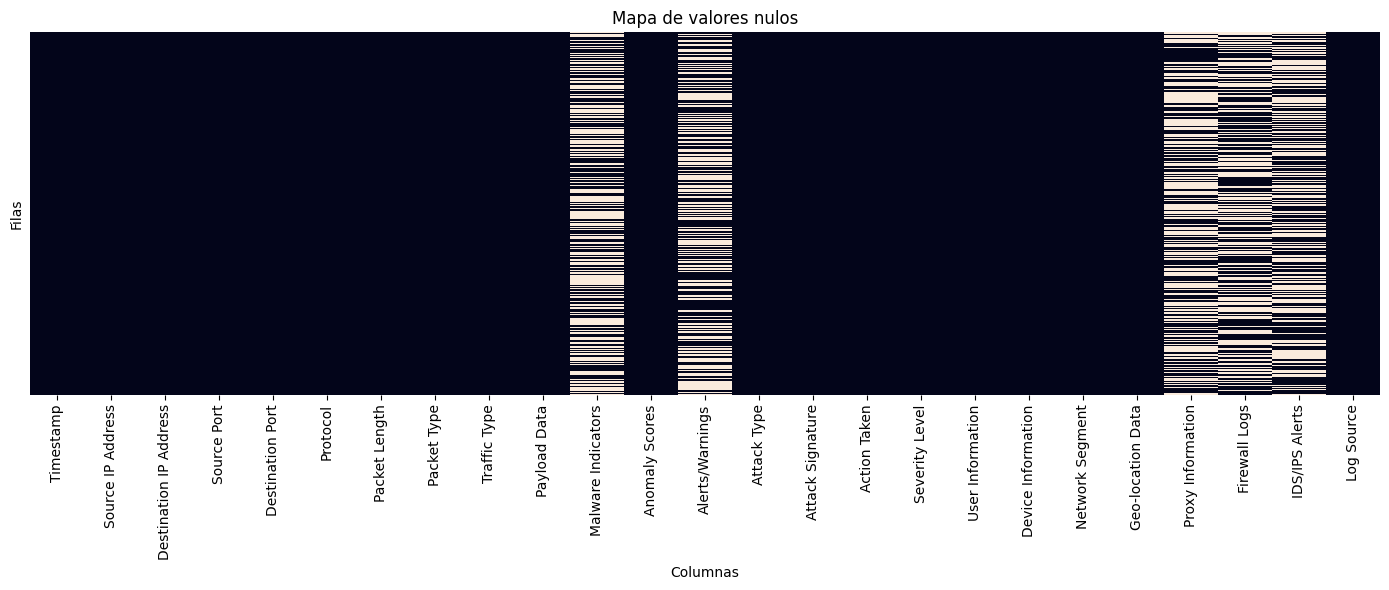

In [17]:
# 4.2 Análisis específico de valores nulos

import matplotlib.pyplot as plt
import seaborn as sns

# Resumen de nulos solo para columnas que realmente tienen ausencias
tabla_nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "nulos_pct": (df.isna().mean() * 100).round(2)
})

tabla_nulos = tabla_nulos[tabla_nulos["nulos"] > 0].sort_values(
    by="nulos_pct", ascending=False
)

display(tabla_nulos)

# Mapa de nulos
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Mapa de valores nulos")
plt.xlabel("Columnas")
plt.ylabel("Filas")
plt.tight_layout()
plt.show()

<br>

## 4.3 Revisión de duplicados exactos

En este paso se comprueba si el dataset contiene filas completamente repetidas. Esta verificación es importante porque los duplicados pueden sesgar el análisis descriptivo, alterar distribuciones y afectar a la evaluación de los modelos si no se detectan a tiempo. Si aparecen registros duplicados, en el siguiente momento habrá que decidir si deben eliminarse o si responden a una lógica real del dato.

In [18]:
# 4.3 Revisión de duplicados exactos

duplicados_abs = df.duplicated().sum()
duplicados_pct = round((duplicados_abs / len(df)) * 100, 2)

print(f"Duplicados exactos: {duplicados_abs}")
print(f"Porcentaje de duplicados: {duplicados_pct}%")

# Mostrar algunas filas duplicadas si existen
if duplicados_abs > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))
else:
    print("No se han detectado filas duplicadas exactas.")

Duplicados exactos: 0
Porcentaje de duplicados: 0.0%
No se han detectado filas duplicadas exactas.


<br>

## 4.4 Revisión de cardinalidad por columna
En este paso se analiza cuántos valores distintos presenta cada variable del dataset. La cardinalidad es un aspecto importante de la calidad de datos porque permite identificar columnas con muy poca variabilidad, que pueden aportar poca señal, y columnas con demasiados valores únicos, que pueden requerir un tratamiento especial en fases posteriores. Este análisis ayuda a anticipar problemas de limpieza, codificación y selección de variables antes del preprocesado y del modelado.

,unicos,unicos_pct,dtype
Destination IP Address,40000,100.00,object
Payload Data,40000,100.00,object
Source IP Address,40000,100.00,object
Timestamp,39997,99.99,object
User Information,32389,80.97,object
Device Information,32104,80.26,object
Destination Port,29895,74.74,int64
Source Port,29761,74.40,int64
Proxy Information,20149,50.37,object
Anomaly Scores,9826,24.56,float64


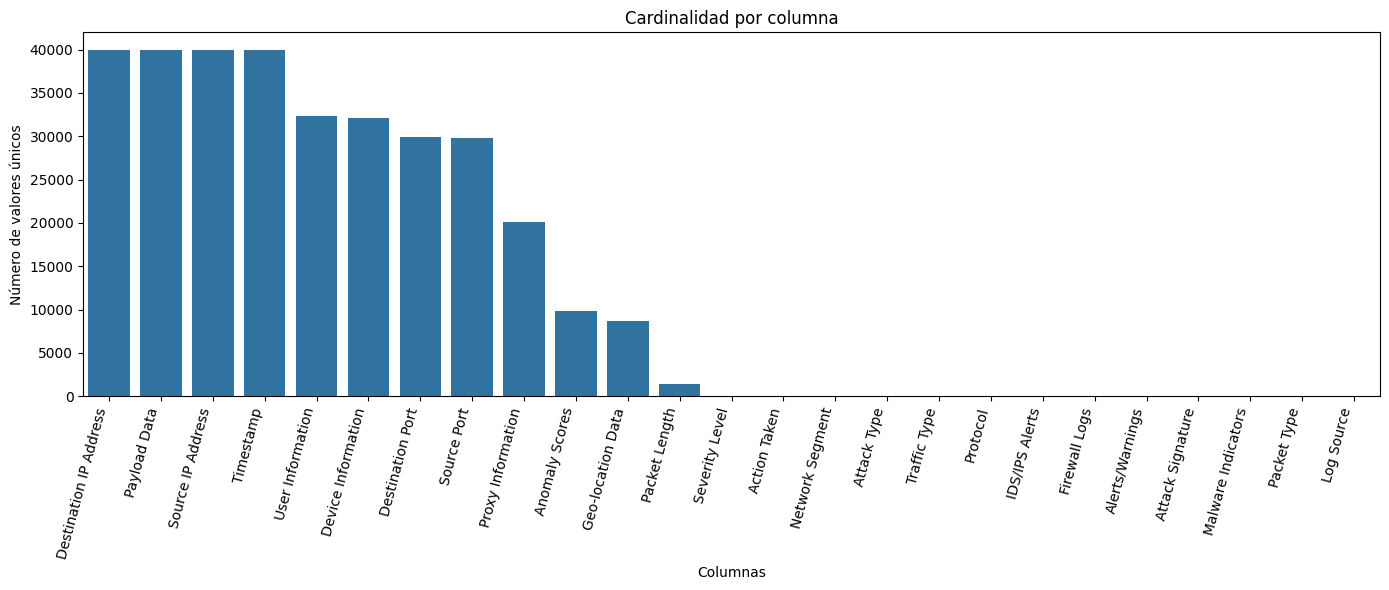

Columnas con más de 1000 valores únicos:


,unicos,unicos_pct,dtype
Destination IP Address,40000,100.00,object
Payload Data,40000,100.00,object
Source IP Address,40000,100.00,object
Timestamp,39997,99.99,object
User Information,32389,80.97,object
Device Information,32104,80.26,object
Destination Port,29895,74.74,int64
Source Port,29761,74.40,int64
Proxy Information,20149,50.37,object
Anomaly Scores,9826,24.56,float64


In [19]:
# 4.4 Revisión de cardinalidad por columna

tabla_cardinalidad = pd.DataFrame({
    "unicos": df.nunique(dropna=False),
    "unicos_pct": (df.nunique(dropna=False) / len(df) * 100).round(2),
    "dtype": df.dtypes.astype(str)
}).sort_values(by="unicos", ascending=False)

display(tabla_cardinalidad)

# Gráfico de cardinalidad por columna
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.barplot(
    data=tabla_cardinalidad.reset_index(),
    x="index",
    y="unicos"
)
plt.title("Cardinalidad por columna")
plt.xlabel("Columnas")
plt.ylabel("Número de valores únicos")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# Identificación rápida de columnas de cardinalidad muy alta
umbral_alto = 1000

columnas_cardinalidad_alta = tabla_cardinalidad[tabla_cardinalidad["unicos"] > umbral_alto]

print(f"Columnas con más de {umbral_alto} valores únicos:")
display(columnas_cardinalidad_alta)

<br>

## 4.5 Revisión de columnas casi constantes

En este paso se analiza si existen variables cuya mayor parte de los registros contiene siempre el mismo valor. Este tipo de columnas puede aportar muy poca información real al modelo y, por tanto, conviene detectarlas antes del preprocesado. La revisión permite distinguir entre variables con baja diversidad útil y columnas que, aunque tengan pocos valores posibles, siguen manteniendo una distribución suficientemente equilibrada como para conservar interés analítico.

In [20]:
# 4.5 Revisión de columnas casi constantes

tabla_constantes = pd.DataFrame(index=df.columns)

tabla_constantes["valor_mas_frecuente"] = [
    df[col].value_counts(dropna=False).index[0] if len(df[col].value_counts(dropna=False)) > 0 else np.nan
    for col in df.columns
]

tabla_constantes["freq_abs"] = [
    df[col].value_counts(dropna=False).iloc[0] if len(df[col].value_counts(dropna=False)) > 0 else np.nan
    for col in df.columns
]

tabla_constantes["freq_pct"] = [
    round(df[col].value_counts(dropna=False, normalize=True).iloc[0] * 100, 2)
    if len(df[col].value_counts(dropna=False, normalize=True)) > 0 else np.nan
    for col in df.columns
]

tabla_constantes["n_unicos"] = df.nunique(dropna=False)

tabla_constantes = tabla_constantes.sort_values(by="freq_pct", ascending=False)

display(tabla_constantes)

# Umbral orientativo para columnas casi constantes
umbral_constante = 95

columnas_casi_constantes = tabla_constantes[tabla_constantes["freq_pct"] >= umbral_constante]

print(f"Columnas casi constantes (valor más frecuente >= {umbral_constante}%):")
display(columnas_casi_constantes)

,valor_mas_frecuente,freq_abs,freq_pct,n_unicos
Packet Type,Control,20237,50.59,2
Log Source,Firewall,20116,50.29,2
Attack Signature,Known Pattern A,20076,50.19,2
Alerts/Warnings,NaN,20067,50.17,2
IDS/IPS Alerts,NaN,20050,50.12,2
Firewall Logs,Log Data,20039,50.10,2
Malware Indicators,IoC Detected,20000,50.00,2
Proxy Information,NaN,19851,49.63,20149
Action Taken,Blocked,13529,33.82,3
Severity Level,Medium,13435,33.59,3


Columnas casi constantes (valor más frecuente >= 95%):


,valor_mas_frecuente,freq_abs,freq_pct,n_unicos


<br>

## 4.6 Revisión inicial de valores raros en columnas categóricas

En este paso se inspeccionan los valores más frecuentes de las columnas categóricas para detectar posibles etiquetas extrañas, categorías incoherentes o problemas visibles de formato. La revisión permite comprobar que las variables categóricas principales presentan valores limpios y consistentes, mientras que otras columnas de tipo texto, como direcciones IP, marcas temporales o contenidos de payload, requieren un tratamiento distinto al no comportarse como categorías convencionales.

In [21]:
# 4.6 Revisión de valores raros en columnas categóricas

columnas_categoricas = df.select_dtypes(include="object").columns.tolist()

for col in columnas_categoricas:
    print(f"\n{'='*80}")
    print(f"Columna: {col}")
    print(f"{'='*80}")
    display(df[col].value_counts(dropna=False).head(10))


Columna: Timestamp


Timestamp
2022-06-11 14:28:15    2
2022-06-06 12:12:43    2
2022-04-17 20:05:34    2
2023-05-30 06:33:58    1
2021-01-11 23:03:29    1
2020-11-25 18:49:20    1
2023-07-29 16:59:01    1
2023-09-18 23:11:05    1
2022-02-13 22:18:53    1
2022-02-26 02:25:53    1
Name: count, dtype: int64


Columna: Source IP Address


Source IP Address
103.216.15.12      1
74.225.47.66       1
147.178.224.232    1
119.183.250.156    1
80.60.140.131      1
197.184.240.174    1
81.194.89.127      1
92.144.85.155      1
40.119.100.114     1
37.220.27.135      1
Name: count, dtype: int64


Columna: Destination IP Address


...

Firewall Logs
Log Data    20039
NaN         19961
Name: count, dtype: int64


Columna: IDS/IPS Alerts


IDS/IPS Alerts
NaN           20050
Alert Data    19950
Name: count, dtype: int64


Columna: Log Source


Log Source
Firewall    20116
Server      19884
Name: count, dtype: int64

<br>

## 4.7 Revisión de inconsistencias de formato y contenido
En este paso se comprueba si algunas columnas clave presentan problemas básicos de consistencia en su formato. La revisión confirma que las marcas temporales pueden convertirse correctamente a fecha y hora, que las direcciones IP siguen un formato válido, que los puertos se mantienen dentro del rango esperado y que la geolocalización conserva una estructura homogénea. Este resultado indica que, al menos a nivel formal, el dataset no presenta errores evidentes de escritura o codificación en estas variables.

In [22]:
# 4.7 Revisión de inconsistencias de formato y contenido

import re
import pandas as pd

# ---------
# 1) Timestamp: comprobar si se puede convertir correctamente a datetime
# ---------
timestamp_convertido = pd.to_datetime(df["Timestamp"], errors="coerce")

inconsistencias_timestamp = pd.DataFrame({
    "valor_original": df["Timestamp"],
    "timestamp_convertido": timestamp_convertido
})

inconsistencias_timestamp = inconsistencias_timestamp[
    inconsistencias_timestamp["timestamp_convertido"].isna()
]

print("Valores no convertibles en Timestamp:")
display(inconsistencias_timestamp.head(10))
print(f"Total no convertibles en Timestamp: {len(inconsistencias_timestamp)}")


# ---------
# 2) IPs: validar formato IPv4 básico
# ---------
patron_ip = re.compile(r"^(?:\d{1,3}\.){3}\d{1,3}$")

def formato_ip_valido(ip):
    if pd.isna(ip):
        return False
    if not patron_ip.match(str(ip)):
        return False
    bloques = str(ip).split(".")
    return all(b.isdigit() and 0 <= int(b) <= 255 for b in bloques)

ip_source_invalidas = df.loc[
    ~df["Source IP Address"].apply(formato_ip_valido),
    ["Source IP Address"]
]

ip_dest_invalidas = df.loc[
    ~df["Destination IP Address"].apply(formato_ip_valido),
    ["Destination IP Address"]
]

print("\nIPs origen con formato inválido:")
display(ip_source_invalidas.head(10))
print(f"Total IPs origen inválidas: {len(ip_source_invalidas)}")

print("\nIPs destino con formato inválido:")
display(ip_dest_invalidas.head(10))
print(f"Total IPs destino inválidas: {len(ip_dest_invalidas)}")


# ---------
# 3) Puertos: comprobar rango válido [0, 65535]
# ---------
puertos_source_invalidos = df.loc[
    (df["Source Port"] < 0) | (df["Source Port"] > 65535),
    ["Source Port"]
]

puertos_dest_invalidos = df.loc[
    (df["Destination Port"] < 0) | (df["Destination Port"] > 65535),
    ["Destination Port"]
]

print("\nSource Port fuera de rango:")
display(puertos_source_invalidos.head(10))
print(f"Total Source Port fuera de rango: {len(puertos_source_invalidos)}")

print("\nDestination Port fuera de rango:")
display(puertos_dest_invalidos.head(10))
print(f"Total Destination Port fuera de rango: {len(puertos_dest_invalidos)}")


# ---------
# 4) Geo-location Data: comprobar formato básico "Ciudad, Región/Estado"
# ---------
geo_sin_coma = df.loc[
    df["Geo-location Data"].astype(str).str.count(",") != 1,
    ["Geo-location Data"]
]

print("\nGeo-location Data con formato no esperado:")
display(geo_sin_coma.head(10))
print(f"Total Geo-location Data con formato no esperado: {len(geo_sin_coma)}")

Valores no convertibles en Timestamp:


,valor_original,timestamp_convertido


Total no convertibles en Timestamp: 0

IPs origen con formato inválido:


,Source IP Address


Total IPs origen inválidas: 0

IPs destino con formato inválido:


...

Total Source Port fuera de rango: 0

Destination Port fuera de rango:


,Destination Port


Total Destination Port fuera de rango: 0

Geo-location Data con formato no esperado:


,Geo-location Data


Total Geo-location Data con formato no esperado: 0


<br>

## 4.8 Primeros outliers en variables numéricas
En este paso se revisan las variables numéricas del dataset mediante boxplots y una detección básica de valores atípicos utilizando el criterio del rango intercuartílico. El resultado no muestra outliers estadísticos en las variables numéricas analizadas, lo que sugiere que, en esta fase inicial, no existen valores extremos evidentes que distorsionen de forma clara la distribución de estos campos. Por tanto, los principales problemas de calidad del dataset no parecen estar en la presencia de valores atípicos, sino en otros aspectos ya detectados, como los nulos concentrados y la alta cardinalidad de varias columnas.

Columnas numéricas detectadas:
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']


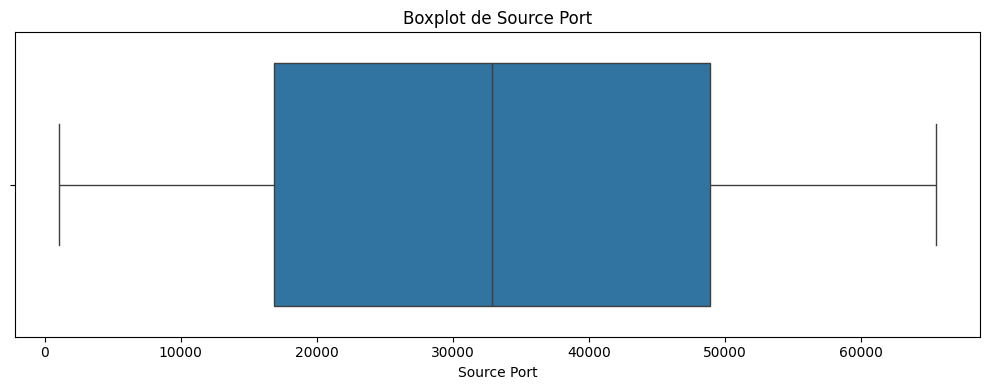

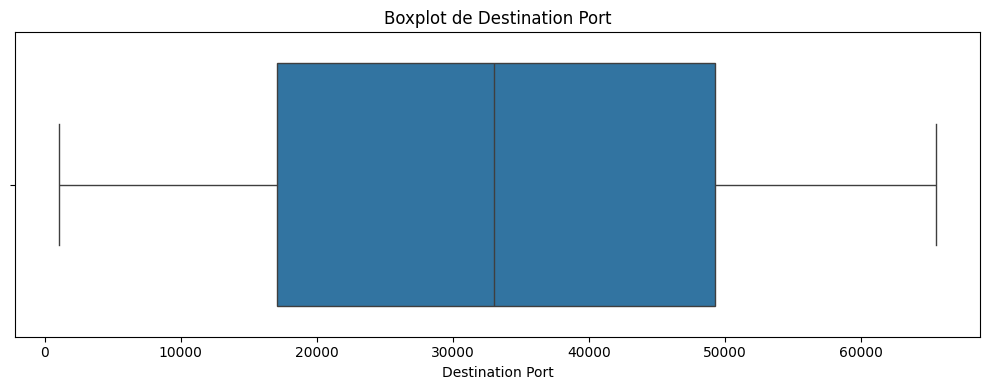

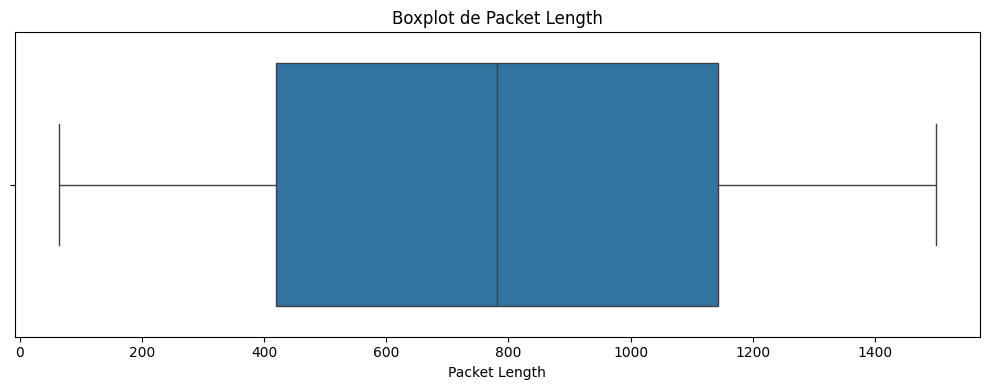

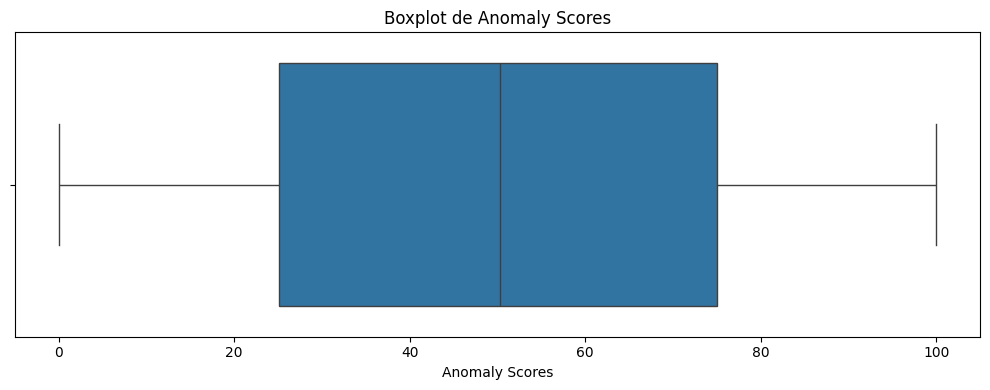

,columna,n_outliers,pct_outliers,limite_inferior,limite_superior
0,Source Port,0,0.0,-31265.50,97044.50
1,Destination Port,0,0.0,-31193.62,97575.38
2,Packet Length,0,0.0,-664.50,2227.50
3,Anomaly Scores,0,0.0,-49.67,149.85


In [23]:
# 4.8 Primeros outliers en variables numéricas

import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Columnas numéricas detectadas:")
print(columnas_numericas)

for col in columnas_numericas:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Resumen numérico ampliado
resumen_numerico = df[columnas_numericas].describe().T
resumen_numerico["iqr"] = resumen_numerico["75%"] - resumen_numerico["25%"]
resumen_numerico["limite_inferior"] = resumen_numerico["25%"] - 1.5 * resumen_numerico["iqr"]
resumen_numerico["limite_superior"] = resumen_numerico["75%"] + 1.5 * resumen_numerico["iqr"]

outliers_resumen = []

for col in columnas_numericas:
    li = resumen_numerico.loc[col, "limite_inferior"]
    ls = resumen_numerico.loc[col, "limite_superior"]
    n_outliers = ((df[col] < li) | (df[col] > ls)).sum()
    pct_outliers = round((n_outliers / len(df)) * 100, 2)

    outliers_resumen.append({
        "columna": col,
        "n_outliers": n_outliers,
        "pct_outliers": pct_outliers,
        "limite_inferior": round(li, 2),
        "limite_superior": round(ls, 2)
    })

tabla_outliers = pd.DataFrame(outliers_resumen).sort_values(by="pct_outliers", ascending=False)

display(tabla_outliers)

<br>

## 4.9 Resumen final de posibles problemas de limpieza detectados

En este paso se integra la información obtenida a lo largo de toda la fase para resumir los principales focos de limpieza del dataset. La revisión confirma que no existen duplicados exactos, inconsistencias formales evidentes ni outliers numéricos claros, pero sí se identifican dos retos importantes para el trabajo posterior: un bloque de columnas con muchos valores nulos y varias variables con cardinalidad muy alta. Este cierre permite dejar señalados los puntos que deberán tratarse con mayor cuidado en la fase de limpieza y preprocesado, manteniendo una transición ordenada hacia las etapas siguientes del proyecto.

In [24]:
# 4.9 Resumen final de posibles problemas de limpieza detectados

resumen_problemas_limpieza = pd.DataFrame({
    "columna": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "nulos_pct": (df.isna().mean() * 100).round(2).values,
    "unicos": df.nunique(dropna=False).values,
    "unicos_pct": ((df.nunique(dropna=False) / len(df)) * 100).round(2).values
})

# Etiquetas interpretativas básicas para la fase de limpieza
resumen_problemas_limpieza["problema_limpieza_detectado"] = "Sin problema evidente"

# Muchas ausencias
resumen_problemas_limpieza.loc[
    resumen_problemas_limpieza["nulos_pct"] >= 40,
    "problema_limpieza_detectado"
] = "Muchos nulos"

# Cardinalidad muy alta
resumen_problemas_limpieza.loc[
    resumen_problemas_limpieza["unicos_pct"] >= 70,
    "problema_limpieza_detectado"
] = "Cardinalidad muy alta"

# Mezcla: muchos nulos + cardinalidad alta
resumen_problemas_limpieza.loc[
    (resumen_problemas_limpieza["nulos_pct"] >= 40) &
    (resumen_problemas_limpieza["unicos_pct"] >= 40),
    "problema_limpieza_detectado"
] = "Muchos nulos y cardinalidad alta"

display(resumen_problemas_limpieza.sort_values(
    by=["nulos_pct", "unicos_pct"], ascending=False
))

,columna,dtype,nulos,nulos_pct,unicos,unicos_pct,problema_limpieza_detectado
12,Alerts/Warnings,object,20067,50.17,2,0.00,Muchos nulos
23,IDS/IPS Alerts,object,20050,50.12,2,0.00,Muchos nulos
10,Malware Indicators,object,20000,50.00,2,0.00,Muchos nulos
22,Firewall Logs,object,19961,49.90,2,0.00,Muchos nulos
21,Proxy Information,object,19851,49.63,20149,50.37,Muchos nulos y cardinalidad alta
1,Source IP Address,object,0,0.00,40000,100.00,Cardinalidad muy alta
2,Destination IP Address,object,0,0.00,40000,100.00,Cardinalidad muy alta
9,Payload Data,object,0,0.00,40000,100.00,Cardinalidad muy alta
0,Timestamp,object,0,0.00,39997,99.99,Cardinalidad muy alta
17,User Information,object,0,0.00,32389,80.97,Cardinalidad muy alta


## Conclusión de la fase 4

La auditoría de calidad de datos muestra que el dataset parte de una base estructuralmente sólida, ya que no presenta duplicados exactos, no contiene inconsistencias formales en las variables clave revisadas y tampoco evidencia valores atípicos claros en las variables numéricas analizadas. Esto es positivo porque reduce la necesidad de corregir errores básicos y permite enfocar el trabajo posterior en decisiones de tratamiento más analíticas que puramente reparadoras.

Aun así, la fase también confirma dos focos de atención relevantes. Por un lado, existe un conjunto de columnas con una proporción muy alta de valores nulos, lo que obliga a interpretar si estas ausencias representan falta real de información o la ausencia de determinados eventos, alertas o registros. Por otro lado, se identifican varias variables con cardinalidad muy alta, como direcciones IP, marcas temporales, payloads o información de usuario y dispositivo, que no podrán utilizarse directamente como variables categóricas convencionales y requerirán transformación, agrupación o descarte razonado en fases posteriores.

En conjunto, esta fase cumple su objetivo: dejar identificado el estado real del dataset antes del EDA más profundo y antes del preprocesado. El resultado general es que el dataset no parece problemático por errores estructurales graves, pero sí exige decisiones cuidadosas de limpieza y tratamiento para que el análisis y el modelado posteriores sean metodológicamente correctos.

<br>

# Fase 5 — EDA descriptivo y visual

<br>

## 5.1 Distribución del target

En este paso se analiza visualmente la variable objetivo **Action Taken** mediante un gráfico de frecuencias y una tabla con valores absolutos y relativos. Este análisis permite comprobar si las clases están equilibradas o si existe desbalance, ya que este aspecto condicionará la interpretación de métricas, la comparación entre modelos y la validez de las conclusiones en fases posteriores.


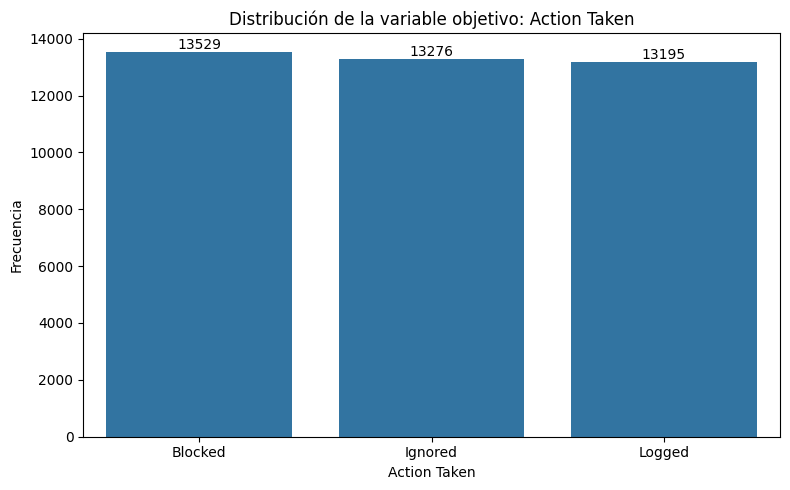

,frecuencia
Action Taken,
Blocked,13529
Ignored,13276
Logged,13195


,porcentaje
Action Taken,
Blocked,33.82
Ignored,33.19
Logged,32.99


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 5.1 — Distribución del target
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="Action Taken", order=df["Action Taken"].value_counts().index)

# Añadir etiquetas de frecuencia sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title("Distribución de la variable objetivo: Action Taken")
plt.xlabel("Action Taken")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Frecuencia absoluta
display(df["Action Taken"].value_counts().to_frame(name="frecuencia"))

# Frecuencia relativa
display((df["Action Taken"].value_counts(normalize=True) * 100).round(2).to_frame(name="porcentaje"))

<br>

## 5.2 Distribución de variables numéricas

Las variables numéricas analizadas (**Source Port**, **Destination Port**, **Packet Length** y **Anomaly Scores**) presentan distribuciones bastante homogéneas a lo largo de sus respectivos rangos. En los histogramas no se observan concentraciones especialmente marcadas, picos dominantes ni asimetrías extremas, sino un reparto visual relativamente uniforme de los valores.

Desde el punto de vista exploratorio, este comportamiento resulta relevante porque no refleja patrones univariantes muy definidos. En un contexto de tráfico de red real sería habitual encontrar concentraciones más claras en determinados puertos, tamaños de paquete o niveles de anomalía, por lo que esta forma de distribución sugiere que el dataset podría tener un componente sintético o fuertemente estructurado.

Aun así, en esta fase no puede concluirse que estas variables carezcan de utilidad predictiva. Lo que sí puede afirmarse es que, observadas de forma individual, no muestran una señal visual fuerte. Por ello, su posible relación con la variable objetivo deberá confirmarse más adelante mediante cruces con el target, análisis de correlación y evaluación de importancia dentro de los modelos.

Columnas numéricas detectadas: ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']


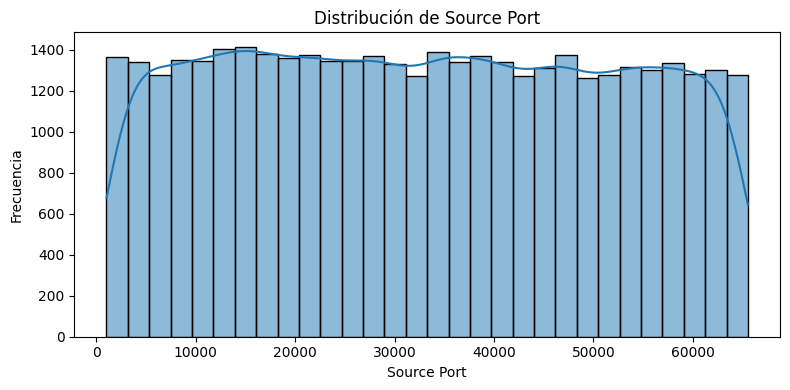

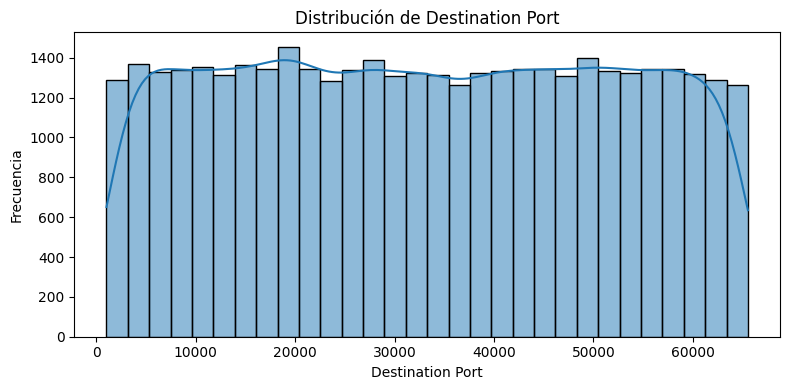

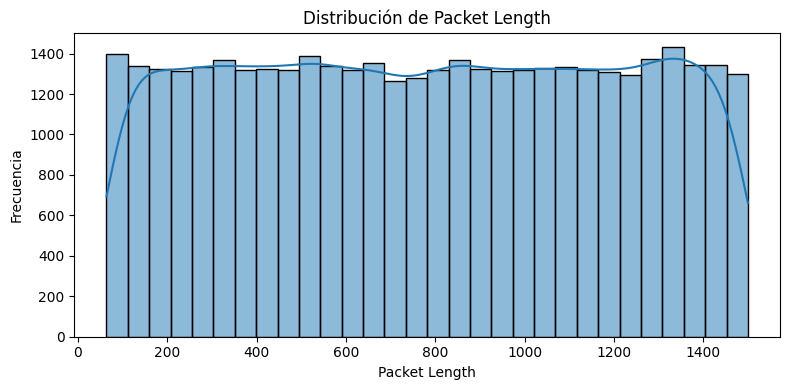

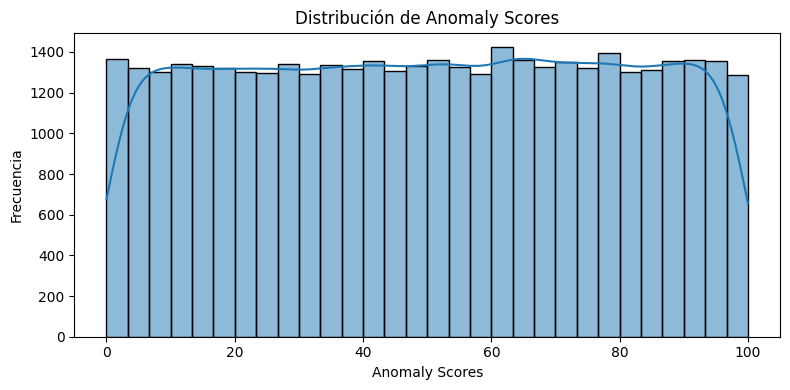

In [26]:
# Paso 5.2 — Distribución de variables numéricas

import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Columnas numéricas detectadas:", columnas_numericas)

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

<br>

## 5.3 Frecuencias de variables categóricas relevantes

Las variables categóricas visualizadas presentan, en general, distribuciones muy equilibradas entre sus distintas categorías. En **Protocol** se observa un reparto casi uniforme entre **ICMP**, **UDP** y **TCP**. En **Packet Type** también existe una distribución muy similar entre **Control** y **Data**. Del mismo modo, **Traffic Type**, **Attack Type**, **Severity Level** y **Network Segment** muestran frecuencias próximas entre sus valores posibles, sin que ninguna categoría domine de forma clara.

La variable **Log Source** mantiene el mismo patrón de equilibrio, con una presencia muy parecida entre **Firewall** y **Server**. Además, la visualización de **Action Taken** vuelve a confirmar lo ya observado en el paso anterior: las clases **Blocked**, **Ignored** y **Logged** están prácticamente balanceadas.

Desde el punto de vista exploratorio, este comportamiento refuerza la idea de que el dataset está fuertemente estructurado y presenta una distribución bastante regular también en sus variables categóricas. Esto facilita el análisis comparativo posterior, aunque al mismo tiempo sugiere que muchas variables, observadas de manera individual, no muestran una señal descriptiva especialmente fuerte. Por ello, el siguiente paso lógico será analizar relaciones más profundas entre variables, detectar posibles valores atípicos y estudiar su vínculo con la variable objetivo.

Columnas categóricas relevantes encontradas: ['Protocol', 'Packet Type', 'Traffic Type', 'Attack Type', 'Action Taken', 'Severity Level', 'Network Segment', 'Log Source']

Analizando columna: Protocol
Protocol
ICMP    13429
UDP     13299
TCP     13272
Name: count, dtype: int64


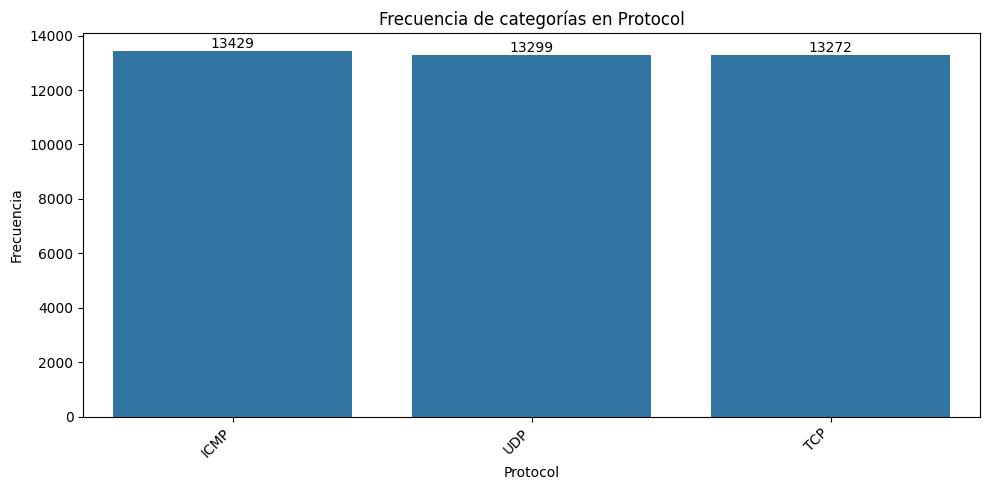


Analizando columna: Packet Type
Packet Type
Control    20237
Data       19763
Name: count, dtype: int64


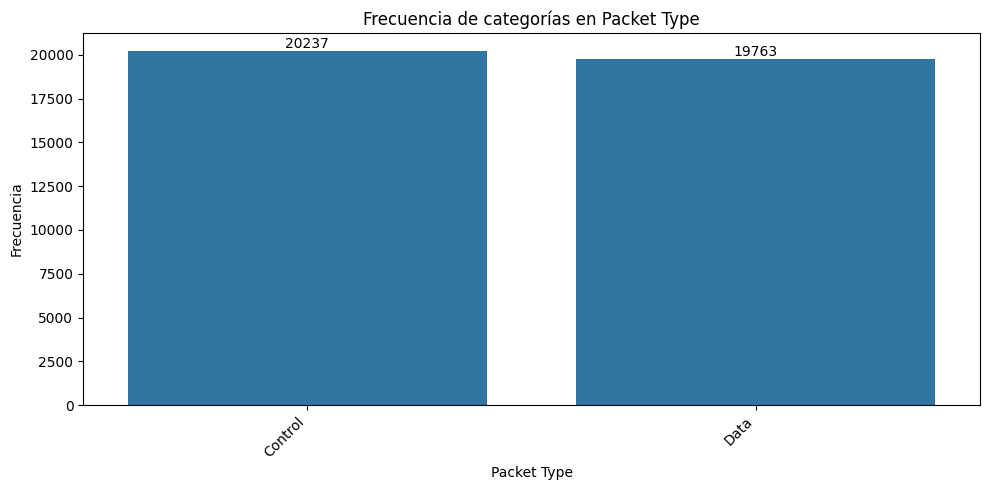


Analizando columna: Traffic Type
Traffic Type
DNS     13376
HTTP    13360
FTP     13264
Name: count, dtype: int64


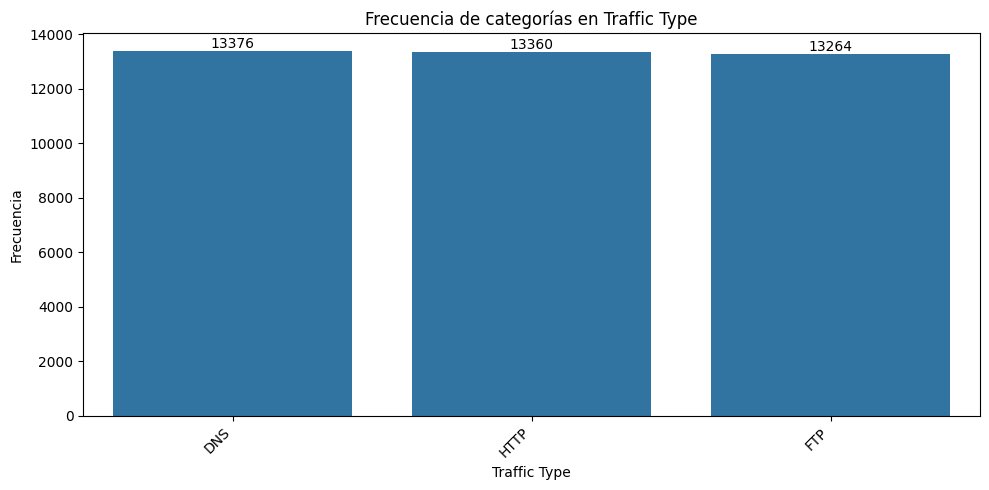


Analizando columna: Attack Type
Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


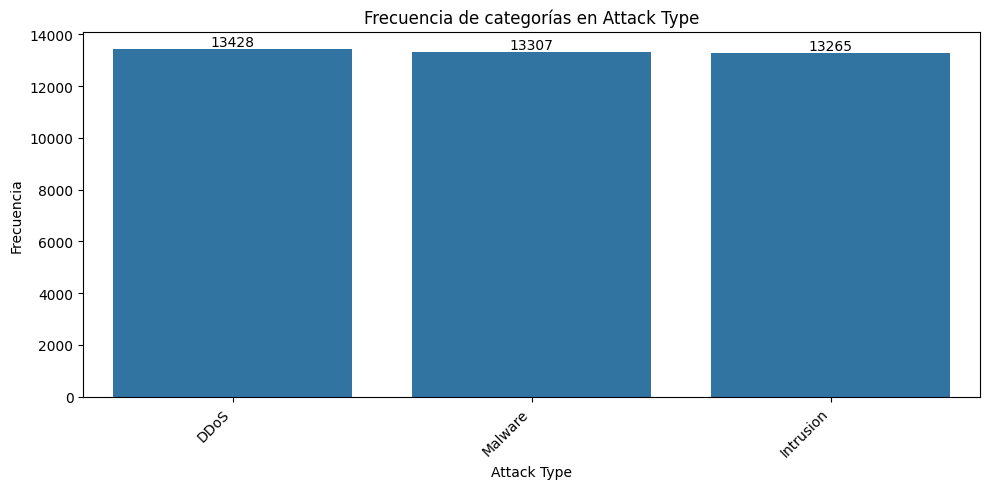


Analizando columna: Action Taken
Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64


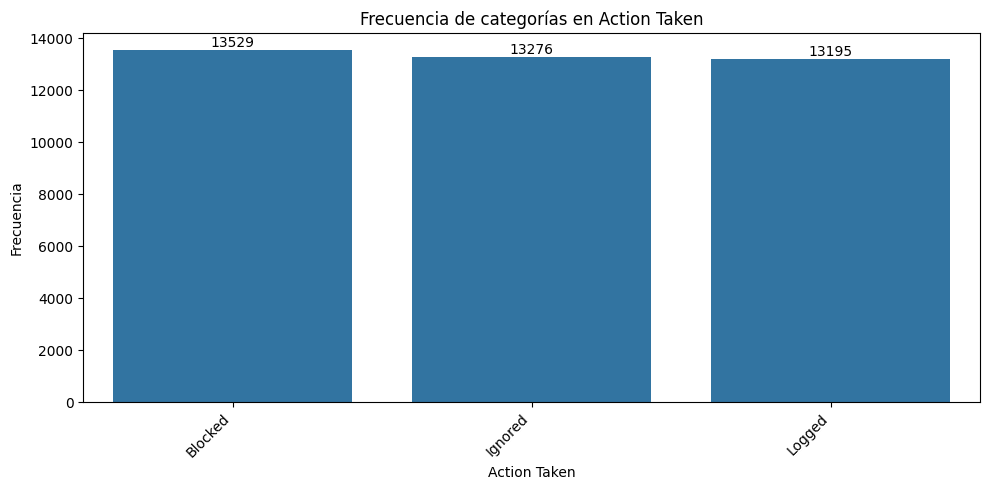


Analizando columna: Severity Level
Severity Level
Medium    13435
High      13382
Low       13183
Name: count, dtype: int64


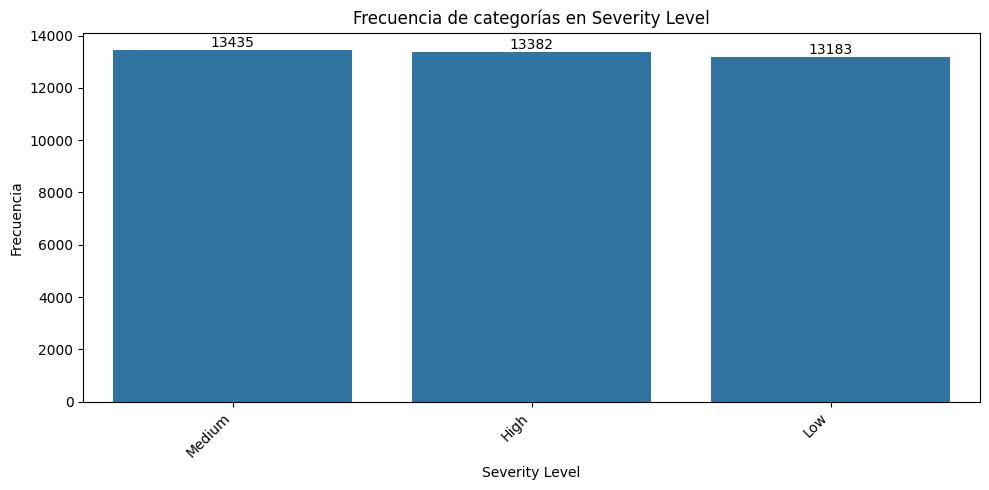


Analizando columna: Network Segment
Network Segment
Segment C    13408
Segment B    13319
Segment A    13273
Name: count, dtype: int64


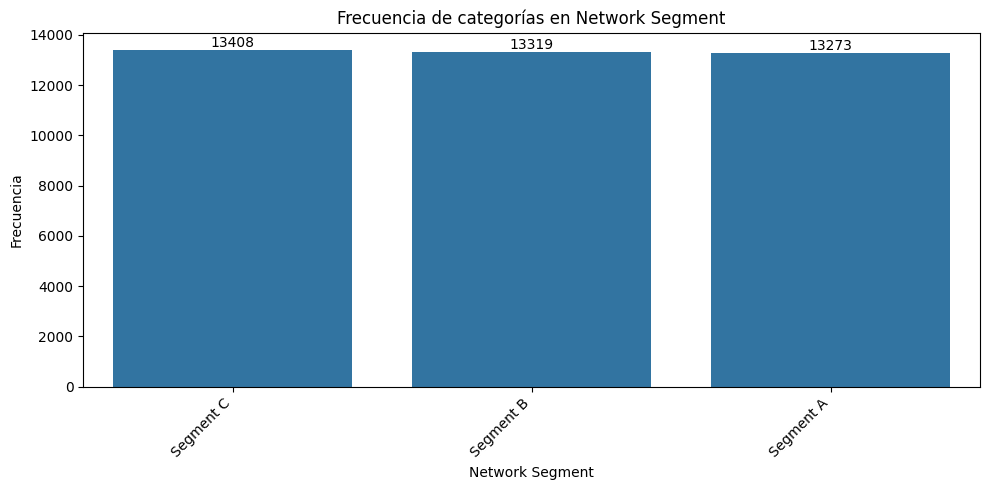


Analizando columna: Log Source
Log Source
Firewall    20116
Server      19884
Name: count, dtype: int64


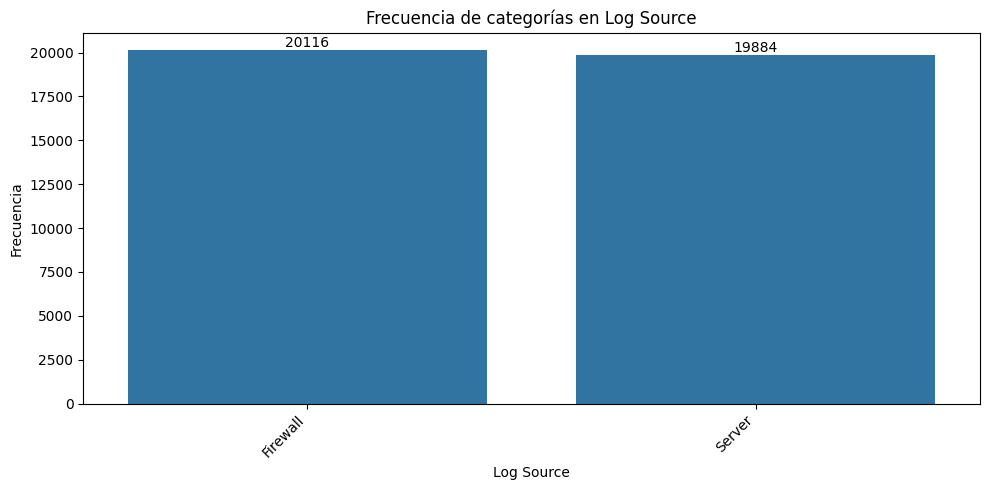

In [27]:
# Paso 5.3 — Frecuencias de variables categóricas relevantes

import matplotlib.pyplot as plt
import seaborn as sns

columnas_candidatas = [
    "Protocol",
    "Packet Type",
    "Traffic Type",
    "Attack Type",
    "Action Taken",
    "Severity Level",
    "Network Segment",
    "Log Source"
]

# Filtrar solo las columnas que realmente existen en el dataframe
columnas_categoricas_relevantes = [col for col in columnas_candidatas if col in df.columns]

print("Columnas categóricas relevantes encontradas:", columnas_categoricas_relevantes)

for col in columnas_categoricas_relevantes:
    print(f"\nAnalizando columna: {col}")
    print(df[col].value_counts())

    plt.figure(figsize=(10, 5))
    orden = df[col].value_counts().index
    ax = sns.countplot(data=df, x=col, order=orden)

    for container in ax.containers:
        ax.bar_label(container, fmt="%d")

    plt.title(f"Frecuencia de categorías en {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

<br>

## 5.4 Detección visual de posibles outliers

Los boxplots de **Source Port**, **Destination Port**, **Packet Length** y **Anomaly Scores** muestran un comportamiento muy homogéneo y sin valores atípicos claramente visibles. No aparecen puntos aislados fuera de los bigotes, y la dispersión general de las variables se mantiene estable en todos los casos.

Aunque visualmente los gráficos resultan muy parecidos entre sí, precisamente esa similitud constituye un hallazgo relevante dentro del análisis exploratorio. Las variables numéricas presentan una estructura regular, con medianas centradas y sin colas extremas destacables, lo que refuerza la idea observada en pasos anteriores de que el dataset está fuertemente equilibrado y distribuido de forma muy uniforme.

Desde el punto de vista metodológico, este resultado permite concluir que, en esta fase descriptiva, no se aprecian indicios claros que justifiquen un tratamiento específico de outliers basado únicamente en la inspección visual. Su posible impacto deberá valorarse más adelante en función del comportamiento real de los modelos.

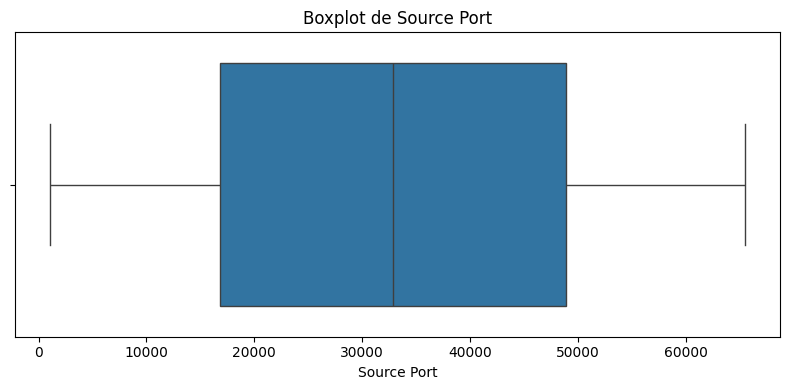

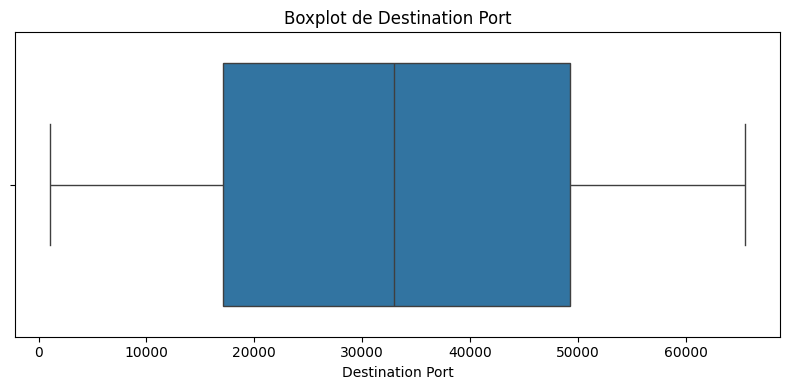

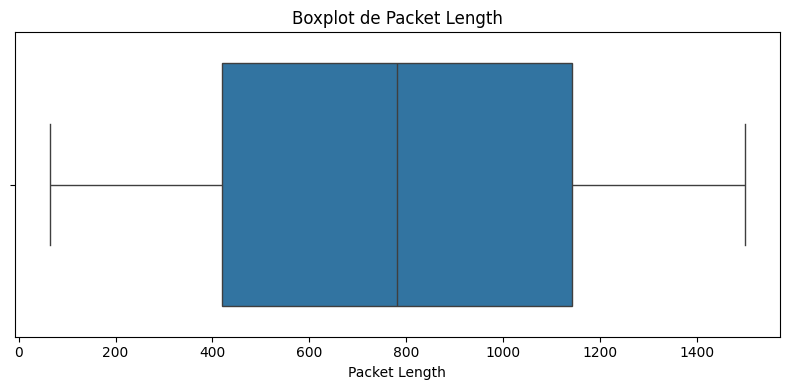

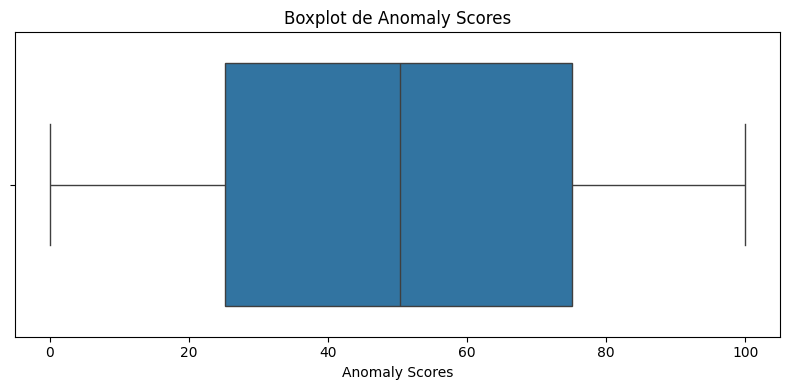

In [28]:
# Paso 5.4 — Detección visual de outliers en variables numéricas

import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = ["Source Port", "Destination Port", "Packet Length", "Anomaly Scores"]

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

<br>

## 5.5 Correlaciones entre variables numéricas

La matriz de correlación muestra que no existe una relación lineal relevante entre las variables numéricas analizadas. Los coeficientes entre **Source Port**, **Destination Port**, **Packet Length** y **Anomaly Scores** son prácticamente nulos, con valores muy próximos a cero en todos los casos.

El mapa de calor confirma visualmente esta ausencia de asociación lineal, ya que fuera de la diagonal principal no aparecen zonas con intensidad destacable. Desde el punto de vista exploratorio, esto indica que estas variables aportan información aparentemente independiente entre sí y que no se observan problemas de multicolinealidad en esta parte del dataset.

Este resultado es importante para las fases posteriores, ya que sugiere que no será necesario aplicar, en principio, una reducción de variables numéricas por redundancia lineal. Al mismo tiempo, refuerza la idea observada en pasos anteriores de que el dataset presenta una estructura muy regular y poco correlacionada a nivel descriptivo, por lo que la capacidad predictiva real deberá comprobarse más adelante mediante cruces con el target y evaluación de modelos.

Matriz de correlación:


,Source Port,Destination Port,Packet Length,Anomaly Scores
Source Port,1.000000,-0.005216,0.003657,0.004826
Destination Port,-0.005216,1.000000,0.002581,-0.003616
Packet Length,0.003657,0.002581,1.000000,-0.003599
Anomaly Scores,0.004826,-0.003616,-0.003599,1.000000


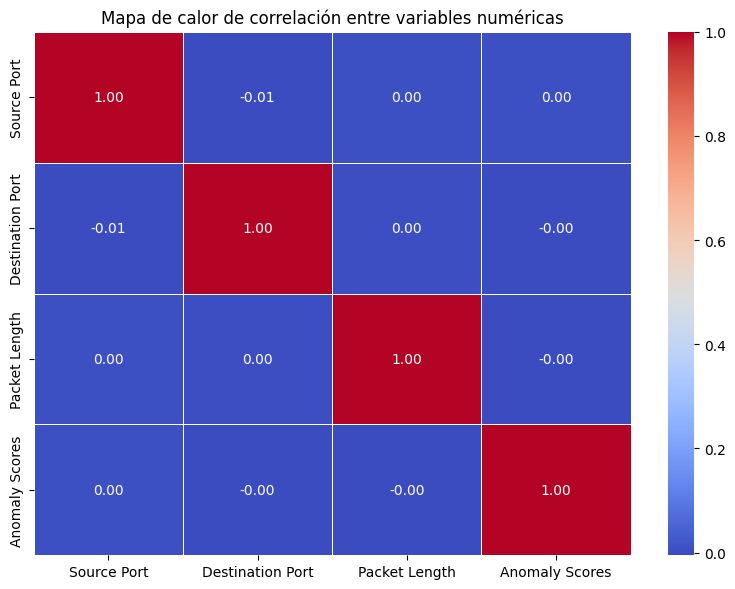

In [29]:
# Paso 5.5 — Correlaciones entre variables numéricas

import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

matriz_correlacion = df[columnas_numericas].corr(numeric_only=True)

print("Matriz de correlación:")
display(matriz_correlacion)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de calor de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

<br>

## 5.6 Cruces entre variables categóricas y el target

Los cruces entre las variables categóricas relevantes y la variable objetivo **Action Taken** muestran un comportamiento muy uniforme. En **Protocol**, **Packet Type**, **Traffic Type**, **Attack Type**, **Severity Level**, **Network Segment** y **Log Source**, las tres clases del target (**Blocked**, **Ignored** y **Logged**) mantienen proporciones muy similares dentro de cada categoría, normalmente en torno al 33 %.

Los gráficos comparativos y las tablas de contingencia no muestran diferencias marcadas ni patrones de separación claros entre categorías y acción tomada. Aunque pueden observarse pequeñas variaciones puntuales, estas son reducidas y no sugieren, a nivel descriptivo, una relación fuerte entre una variable categórica individual y el target.

Desde el punto de vista exploratorio, este resultado es relevante porque indica que las variables categóricas, analizadas de forma aislada, no parecen aportar una señal visual muy intensa para predecir **Action Taken**. Esto refuerza la idea observada en pasos anteriores de que el dataset está muy equilibrado y estructurado, por lo que la capacidad predictiva real deberá evaluarse más adelante mediante preprocesamiento adecuado, modelado y comparación formal de métricas.


===== Protocol vs Action Taken =====
Frecuencia absoluta:


Action Taken,Blocked,Ignored,Logged
Protocol,,,
ICMP,4503,4492,4434
TCP,4487,4384,4401
UDP,4539,4400,4360


Porcentaje por categoría:


Action Taken,Blocked,Ignored,Logged
Protocol,,,
ICMP,33.53,33.45,33.02
TCP,33.81,33.03,33.16
UDP,34.13,33.09,32.78


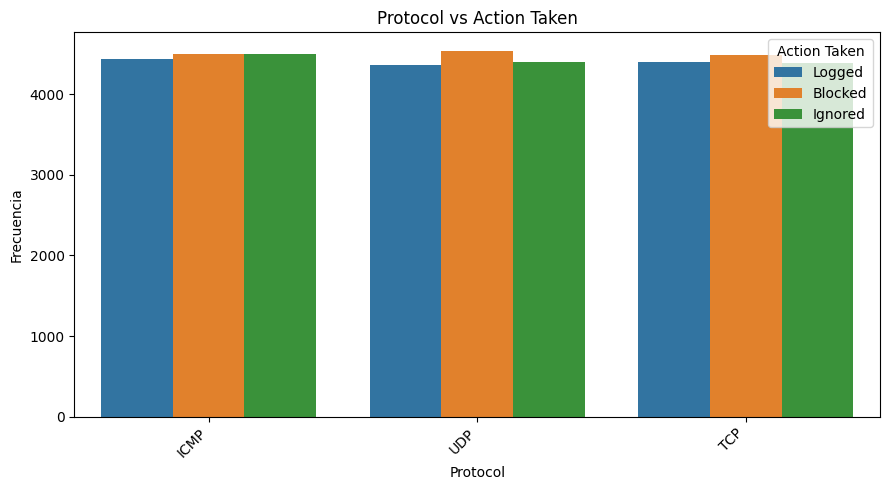


===== Packet Type vs Action Taken =====
Frecuencia absoluta:


Action Taken,Blocked,Ignored,Logged
Packet Type,,,
Control,6956,6706,6575
Data,6573,6570,6620


Porcentaje por categoría:


Action Taken,Blocked,Ignored,Logged
Packet Type,,,
Control,34.37,33.14,32.49
Data,33.26,33.24,33.50


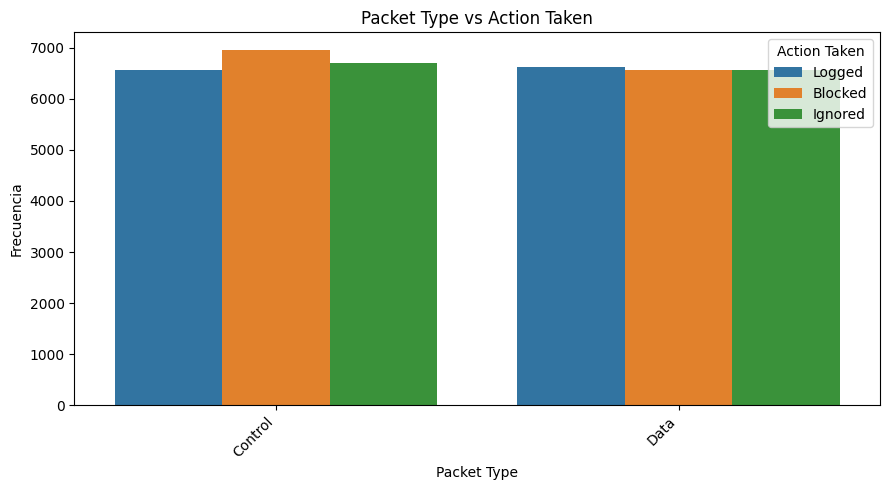


===== Traffic Type vs Action Taken =====
Frecuencia absoluta:


Action Taken,Blocked,Ignored,Logged
Traffic Type,,,
DNS,4514,4470,4392
FTP,4509,4391,4364
HTTP,4506,4415,4439


Porcentaje por categoría:


Action Taken,Blocked,Ignored,Logged
Traffic Type,,,
DNS,33.75,33.42,32.83
FTP,33.99,33.10,32.90
HTTP,33.73,33.05,33.23


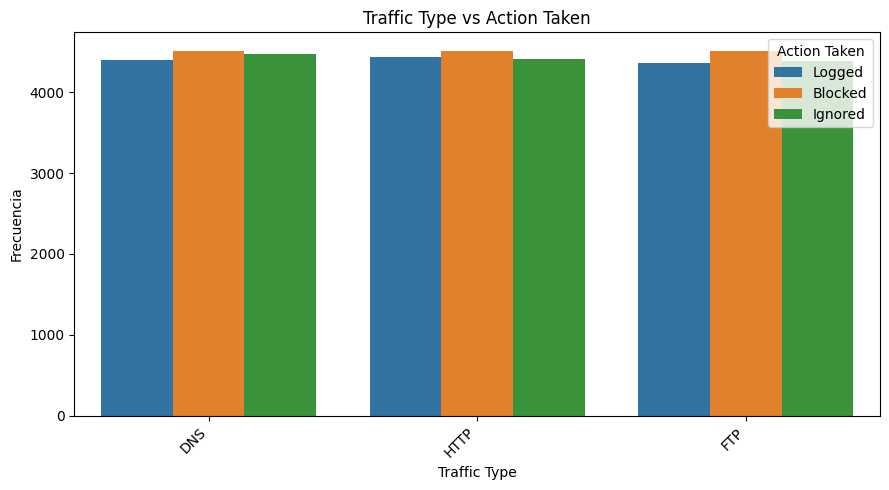


===== Attack Type vs Action Taken =====
Frecuencia absoluta:


Action Taken,Blocked,Ignored,Logged
Attack Type,,,
DDoS,4533,4459,4436
Intrusion,4553,4401,4311
Malware,4443,4416,4448


Porcentaje por categoría:


Action Taken,Blocked,Ignored,Logged
Attack Type,,,
DDoS,33.76,33.21,33.04
Intrusion,34.32,33.18,32.50
Malware,33.39,33.19,33.43


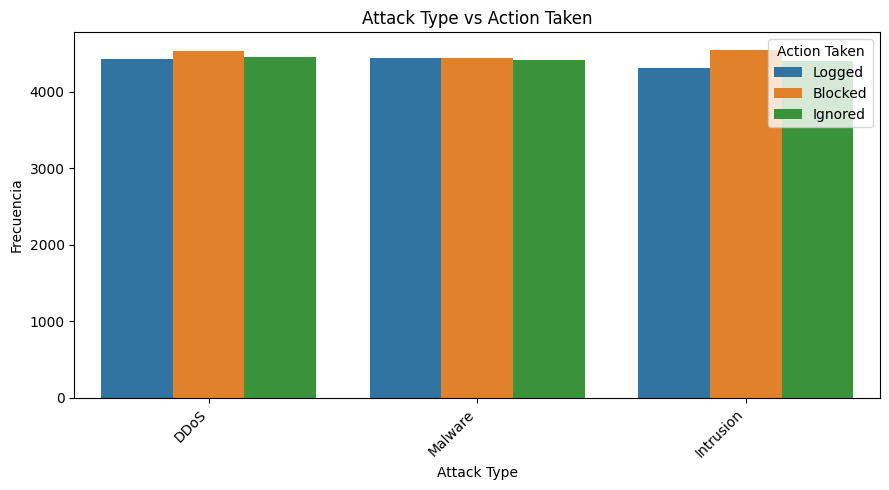


===== Severity Level vs Action Taken =====
Frecuencia absoluta:


Action Taken,Blocked,Ignored,Logged
Severity Level,,,
High,4530,4460,4392
Low,4481,4409,4293
Medium,4518,4407,4510


Porcentaje por categoría:


Action Taken,Blocked,Ignored,Logged
Severity Level,,,
High,33.85,33.33,32.82
Low,33.99,33.44,32.56
Medium,33.63,32.80,33.57


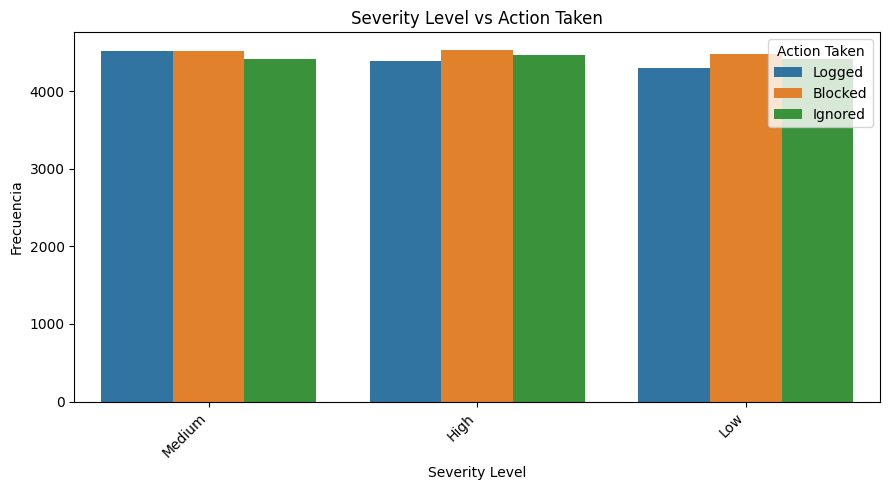


===== Network Segment vs Action Taken =====
Frecuencia absoluta:


Action Taken,Blocked,Ignored,Logged
Network Segment,,,
Segment A,4585,4314,4374
Segment B,4475,4439,4405
Segment C,4469,4523,4416


Porcentaje por categoría:


Action Taken,Blocked,Ignored,Logged
Network Segment,,,
Segment A,34.54,32.50,32.95
Segment B,33.60,33.33,33.07
Segment C,33.33,33.73,32.94


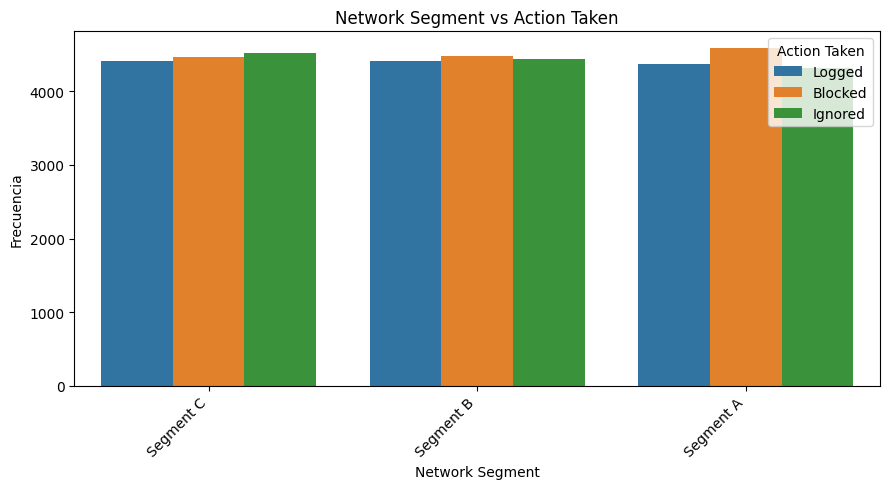


===== Log Source vs Action Taken =====
Frecuencia absoluta:


Action Taken,Blocked,Ignored,Logged
Log Source,,,
Firewall,6830,6652,6634
Server,6699,6624,6561


Porcentaje por categoría:


Action Taken,Blocked,Ignored,Logged
Log Source,,,
Firewall,33.95,33.07,32.98
Server,33.69,33.31,33.00


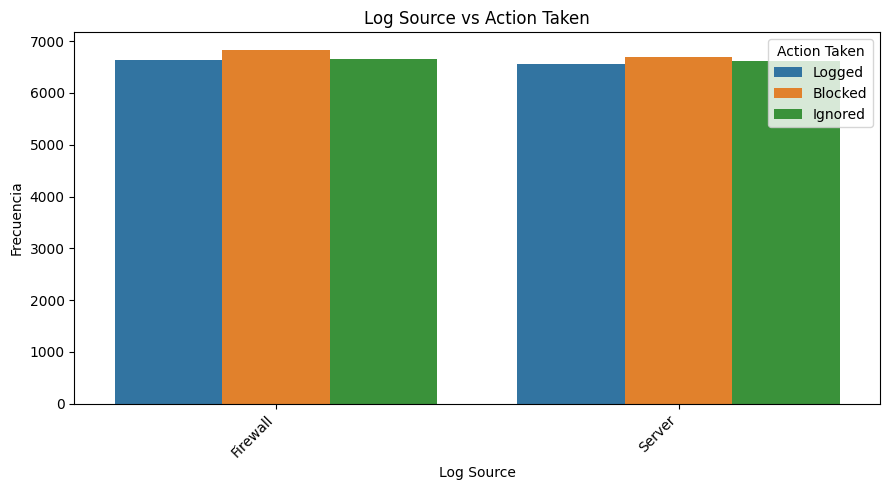

In [30]:
# Paso 5.6 — Cruces de variables categóricas relevantes con Action Taken

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

columnas_categoricas_relevantes = [
    "Protocol",
    "Packet Type",
    "Traffic Type",
    "Attack Type",
    "Severity Level",
    "Network Segment",
    "Log Source"
]

for col in columnas_categoricas_relevantes:
    print(f"\n===== {col} vs Action Taken =====")
    
    tabla = pd.crosstab(df[col], df["Action Taken"])
    tabla_pct = pd.crosstab(df[col], df["Action Taken"], normalize="index") * 100
    
    print("Frecuencia absoluta:")
    display(tabla)
    
    print("Porcentaje por categoría:")
    display(tabla_pct.round(2))
    
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=col, hue="Action Taken", order=df[col].value_counts().index)
    plt.title(f"{col} vs Action Taken")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

<br>

## 5.7 Conclusión de la fase

El análisis exploratorio descriptivo y visual muestra que el dataset presenta una estructura muy equilibrada tanto en la variable objetivo como en las principales variables numéricas y categóricas analizadas. **Action Taken** se distribuye de forma prácticamente uniforme entre sus tres clases, y este mismo patrón de equilibrio se repite en gran parte de las variables observadas. Las distribuciones numéricas son regulares, no se aprecian outliers visuales relevantes y la matriz de correlación confirma la ausencia de relaciones lineales fuertes entre las variables numéricas.

Por su parte, los cruces entre variables categóricas y el target tampoco muestran separaciones visuales claras ni patrones descriptivos especialmente intensos. En conjunto, esto sugiere que el dataset está fuertemente estructurado y que, al menos a nivel exploratorio univariante y bivariante simple, no existen señales evidentes que permitan anticipar un comportamiento predictivo muy claro solo a partir de la inspección visual.

Desde el punto de vista metodológico, esta conclusión es importante porque justifica que la siguiente fase no debe centrarse en corregir grandes problemas del dato, sino en preparar correctamente las variables para el modelado y comprobar, mediante técnicas de preprocesamiento y evaluación formal, si existen relaciones útiles que no se aprecian directamente en el análisis descriptivo. Esta fase, por tanto, deja una base sólida para avanzar hacia el tratamiento de variables y la construcción de modelos de forma ordenada y técnicamente coherente.

---
<br>

# Fase 6 — EDA orientado al modelado

## 6.1 Interpretación de variables numéricas por clase

La comparación de `Source Port`, `Destination Port`, `Packet Length` y `Anomaly Scores` por `Action Taken` muestra medias y medianas muy próximas entre `Blocked`, `Ignored` y `Logged`. Además, la desviación estándar es elevada en los tres grupos, lo que indica un fuerte solapamiento entre clases.

Esto sugiere que, de forma individual, estas variables numéricas no parecen separar claramente el target. Por tanto, su capacidad predictiva aislada parece limitada en esta fase del análisis, aunque más adelante podrían aportar valor combinadas con otras variables o dentro de modelos no lineales.

In [31]:
# 6.1 - Vista comparativa de variables numéricas por clase (Action Taken)

import pandas as pd

target_col = "Action Taken"

# Seleccionamos solo variables numéricas distintas del target
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_col]

# Tabla agregada por clase: media, mediana y desviación típica
tabla_numericas_por_clase = (
    df.groupby(target_col)[numeric_cols]
      .agg(["mean", "median", "std"])
      .round(2)
)

# Mostramos una versión más cómoda de leer
display(tabla_numericas_por_clase)

Source Port                    Destination Port           \
                    mean   median       std             mean   median   
Action Taken                                                            
Blocked         33135.76  33264.0  18564.77         33391.50  33339.0   
Ignored         32957.53  32896.5  18530.56         32916.95  32770.0   
Logged          32813.67  32346.0  18585.97         33139.50  33058.0   

                       Packet Length                Anomaly Scores         \
                   std          mean median     std           mean median   
Action Taken                                                                
Blocked       18549.93        784.17  786.0  413.47          50.14  50.25   
Ignored       18561.66        781.72  784.0  416.98          49.93  50.02   
Logged        18611.39        778.39  774.0  417.74          50.27  50.72   

                     
                std  
Action Taken         
Blocked       28.93  
Ignored       28.87  
Logged        28.76

<br>

## 6.2 Evaluación de variables categóricas para el modelado

El análisis de las variables categóricas muestra que no todas tienen el mismo valor de cara al modelado. Algunas columnas de baja cardinalidad, como `Protocol`, `Packet Type`, `Traffic Type`, `Attack Type`, `Attack Signature`, `Severity Level`, `Network Segment` y `Log Source`, permiten una comparación razonable con `Action Taken`, aunque en general presentan distribuciones bastante equilibradas entre clases, por lo que su señal individual parece limitada.

También se observa un grupo de variables problemáticas para usar directamente en un modelo tabular. `Timestamp` requiere transformación a componentes más útiles, mientras que columnas como `Source IP Address`, `Destination IP Address`, `Proxy Information`, `Payload Data`, `User Information`, `Device Information` y `Geo-location Data` presentan cardinalidad muy alta o texto libre, lo que puede introducir ruido si no se transforman adecuadamente.

Por último, `Malware Indicators`, `Alerts/Warnings`, `Firewall Logs` e `IDS/IPS Alerts` no aportan variabilidad, ya que toman el mismo valor en todos los registros. Por tanto, en esta fase quedan identificadas como candidatas directas a exclusión, mientras que el resto deberá clasificarse en fases posteriores según convenga mantener, transformar o descartar.

In [32]:
# 6.2 - Comparativa de variables categóricas por clase (Action Taken)

target_col = "Action Taken"

# Columnas categóricas, excluyendo el target
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != target_col]

# Generamos tablas de frecuencia relativa por clase para cada variable categórica
tablas_categoricas_por_clase = {}

for col in categorical_cols:
    tabla = pd.crosstab(df[col], df[target_col], normalize="columns") * 100
    tabla = tabla.round(2)
    tablas_categoricas_por_clase[col] = tabla

# Mostrar una por una
for col, tabla in tablas_categoricas_por_clase.items():
    print(f"\n{'='*80}")
    print(f"Columna: {col}")
    print(f"{'='*80}")
    display(tabla)


Columna: Timestamp


Action Taken,Blocked,Ignored,Logged
Timestamp,,,
2020-01-01 00:43:27,0.01,0.00,0.00
2020-01-01 01:14:07,0.01,0.00,0.00
2020-01-01 03:02:42,0.00,0.00,0.01
2020-01-01 03:11:48,0.00,0.01,0.00
2020-01-01 03:29:20,0.00,0.01,0.00
...,...,...,...
2023-10-11 12:29:23,0.00,0.01,0.00
2023-10-11 12:36:21,0.00,0.00,0.01
2023-10-11 17:44:41,0.00,0.01,0.00



Columna: Source IP Address


Action Taken,Blocked,Ignored,Logged
Source IP Address,,,
1.1.45.194,0.00,0.01,0.00
1.1.51.229,0.01,0.00,0.00
1.10.201.206,0.00,0.00,0.01
1.10.74.49,0.01,0.00,0.00
1.100.115.5,0.00,0.01,0.00
...,...,...,...
99.98.33.36,0.00,0.01,0.00
99.98.4.179,0.01,0.00,0.00
99.99.110.210,0.01,0.00,0.00



Columna: Destination IP Address


...

Action Taken,Blocked,Ignored,Logged
Firewall Logs,,,
Log Data,100.0,100.0,100.0



Columna: IDS/IPS Alerts


Action Taken,Blocked,Ignored,Logged
IDS/IPS Alerts,,,
Alert Data,100.0,100.0,100.0



Columna: Log Source


Action Taken,Blocked,Ignored,Logged
Log Source,,,
Firewall,50.48,50.11,50.28
Server,49.52,49.89,49.72


<br>

## 6.3 Detección de columnas constantes o casi constantes

En este paso se ha comprobado qué variables presentan una variabilidad insuficiente para resultar útiles en el modelado. El análisis confirma que `Alerts/Warnings`, `Firewall Logs`, `IDS/IPS Alerts` y `Malware Indicators` son columnas constantes, ya que contienen un único valor en todo el dataset.

Desde el punto de vista predictivo, estas variables no aportan información para diferenciar las clases de `Action Taken`, por lo que quedan identificadas como candidatas directas a exclusión en el preprocesado. Además, no se han detectado columnas casi constantes con el umbral definido, lo que indica que este problema se concentra en las variables completamente constantes.

In [33]:
# 6.3 - Detección de columnas constantes o casi constantes

# Número de valores únicos por columna (sin contar nulos)
unique_counts = df.nunique(dropna=True).sort_values()

# Columnas constantes
constant_cols = unique_counts[unique_counts == 1]

# Columnas casi constantes: la categoría más frecuente supera el 95%
quasi_constant_info = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq > 0.95 and df[col].nunique(dropna=True) > 1:
        quasi_constant_info.append({
            "columna": col,
            "top_freq_pct": round(top_freq * 100, 2),
            "n_valores_unicos": df[col].nunique(dropna=True)
        })

quasi_constant_df = pd.DataFrame(quasi_constant_info)

print("Columnas constantes:")
display(constant_cols)

print("\nColumnas casi constantes (>95% en una sola categoría):")
if quasi_constant_df.empty:
    print("No se han detectado columnas casi constantes con el umbral definido.")
else:
    quasi_constant_df = quasi_constant_df.sort_values(by="top_freq_pct", ascending=False)
    display(quasi_constant_df)

Columnas constantes:


Alerts/Warnings       1
Firewall Logs         1
IDS/IPS Alerts        1
Malware Indicators    1
dtype: int64


Columnas casi constantes (>95% en una sola categoría):
No se han detectado columnas casi constantes con el umbral definido.


<br>

## 6.4 Evaluación de la cardinalidad de las variables categóricas

El análisis de cardinalidad permite separar las variables categóricas según su viabilidad para el modelado. Por un lado, `Protocol`, `Traffic Type`, `Network Segment`, `Attack Type`, `Severity Level`, `Attack Signature`, `Packet Type` y `Log Source` presentan baja cardinalidad, por lo que son técnicamente manejables y adecuadas para un preprocesado estándar.

Por otro lado, `Source IP Address`, `Destination IP Address`, `Payload Data` y `Timestamp` muestran una cardinalidad extrema, con prácticamente un valor único por registro. Esto indica que no conviene usarlas directamente como variables categóricas. Además, `User Information`, `Device Information`, `Proxy Information` y `Geo-location Data` también presentan cardinalidad alta, por lo que quedan identificadas como variables a revisar, transformar o posiblemente excluir.

Este paso ayuda a tomar una decisión clave para el modelado: no todas las variables categóricas deben tratarse igual, y conviene priorizar aquellas que sean interpretables, manejables y potencialmente útiles para la predicción.

In [34]:
# 6.4 - Cardinalidad de variables categóricas

target_col = "Action Taken"

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != target_col]

cardinality_df = pd.DataFrame({
    "columna": categorical_cols,
    "n_valores_unicos": [df[col].nunique(dropna=True) for col in categorical_cols],
    "pct_unicos_sobre_total": [round(df[col].nunique(dropna=True) / len(df) * 100, 2) for col in categorical_cols]
}).sort_values(by="n_valores_unicos", ascending=False)

display(cardinality_df)

,columna,n_valores_unicos,pct_unicos_sobre_total
2,Destination IP Address,40000,100.00
6,Payload Data,40000,100.00
1,Source IP Address,40000,100.00
0,Timestamp,39997,99.99
12,User Information,32389,80.97
13,Device Information,32104,80.26
16,Proxy Information,20148,50.37
15,Geo-location Data,8723,21.81
3,Protocol,3,0.01
5,Traffic Type,3,0.01


<br>

## 6.5 Clasificación inicial de variables para el modelado

Este paso permite organizar las variables según la acción más razonable de cara al preprocesado y al entrenamiento del modelo. Por un lado, `Malware Indicators`, `Alerts/Warnings`, `Firewall Logs` e `IDS/IPS Alerts` quedan identificadas como columnas a excluir, ya que son constantes y no aportan capacidad predictiva.

Por otro lado, las variables numéricas (`Source Port`, `Destination Port`, `Packet Length` y `Anomaly Scores`) y las categóricas de baja cardinalidad (`Protocol`, `Packet Type`, `Traffic Type`, `Attack Type`, `Attack Signature`, `Severity Level`, `Network Segment` y `Log Source`) pueden mantenerse inicialmente, ya que son técnicamente manejables dentro de un pipeline base.

Además, se detecta un grupo de variables que requieren revisión específica antes de modelar. `Timestamp` debe transformarse en componentes temporales más útiles, mientras que `Source IP Address`, `Destination IP Address`, `Proxy Information`, `Payload Data`, `User Information`, `Device Information` y `Geo-location Data` presentan alta cardinalidad o naturaleza compleja, por lo que conviene revisarlas críticamente, transformarlas o considerar su exclusión.

In [35]:
# 6.5 - Clasificación inicial de columnas según necesidad de transformación

transformacion_sugerida = []

for col in df.columns:
    if col == "Action Taken":
        continue
        
    n_unicos = df[col].nunique(dropna=True)
    dtype = df[col].dtype
    
    if col == "Timestamp":
        decision = "transformar"
        motivo = "variable temporal; conviene derivar componentes como hora, día o mes"
    elif n_unicos == 1:
        decision = "excluir"
        motivo = "columna constante sin utilidad predictiva"
    elif col in ["Source IP Address", "Destination IP Address", "Proxy Information"]:
        decision = "revisar/excluir"
        motivo = "identificadores de alta cardinalidad"
    elif col in ["Payload Data"]:
        decision = "revisar/excluir"
        motivo = "texto libre con cardinalidad extrema"
    elif col in ["User Information", "Device Information", "Geo-location Data"]:
        decision = "revisar/transformar"
        motivo = "alta cardinalidad; requiere simplificación o ingeniería de variables"
    elif dtype == "object":
        decision = "mantener"
        motivo = "categórica manejable para análisis posterior"
    else:
        decision = "mantener"
        motivo = "numérica utilizable en principio"
    
    transformacion_sugerida.append({
        "columna": col,
        "dtype": str(dtype),
        "n_unicos": n_unicos,
        "decision_inicial": decision,
        "motivo": motivo
    })

decision_modelado_df = pd.DataFrame(transformacion_sugerida)
display(decision_modelado_df.sort_values(by=["decision_inicial", "n_unicos"], ascending=[True, False]))

,columna,dtype,n_unicos,decision_inicial,motivo
10,Malware Indicators,object,1,excluir,columna constante sin utilidad predictiva
12,Alerts/Warnings,object,1,excluir,columna constante sin utilidad predictiva
21,Firewall Logs,object,1,excluir,columna constante sin utilidad predictiva
22,IDS/IPS Alerts,object,1,excluir,columna constante sin utilidad predictiva
4,Destination Port,int64,29895,mantener,numérica utilizable en principio
3,Source Port,int64,29761,mantener,numérica utilizable en principio
11,Anomaly Scores,float64,9826,mantener,numérica utilizable en principio
6,Packet Length,int64,1437,mantener,numérica utilizable en principio
5,Protocol,object,3,mantener,categórica manejable para análisis posterior
8,Traffic Type,object,3,mantener,categórica manejable para análisis posterior


<br>

## 6.6 Revisión de columnas con riesgo conceptual o utilidad limitada

En este paso se identifican variables que conviene tratar con cautela antes del modelado. `Attack Signature` y `Severity Level` quedan marcadas como columnas a revisar, ya que podrían estar demasiado próximas a la lógica operativa que influye en `Action Taken`, lo que obliga a valorar su uso con cuidado para evitar conclusiones artificialmente optimistas.

Además, `Malware Indicators`, `Alerts/Warnings`, `Firewall Logs` e `IDS/IPS Alerts` vuelven a confirmarse como variables sin utilidad real para la predicción, ya que son constantes. Por su parte, `Log Source` podría mantenerse como variable operativa, aunque hasta ahora ha mostrado una señal limitada. Esta revisión deja preparado un criterio útil para la fase de modelado, donde podrá compararse el rendimiento del modelo con y sin algunas de estas columnas.

In [36]:
# 6.6 - Revisión manual de columnas con posible leakage o utilidad dudosa

revision_riesgo = [
    {
        "columna": "Attack Signature",
        "riesgo_leakage": "medio",
        "utilidad_dudosa": "media",
        "motivo": "puede estar demasiado ligada a reglas de detección ya construidas"
    },
    {
        "columna": "Severity Level",
        "riesgo_leakage": "medio",
        "utilidad_dudosa": "media",
        "motivo": "podría ser una variable derivada de lógica de seguridad cercana a la decisión final"
    },
    {
        "columna": "Malware Indicators",
        "riesgo_leakage": "bajo",
        "utilidad_dudosa": "alta",
        "motivo": "es constante; no aporta valor predictivo"
    },
    {
        "columna": "Alerts/Warnings",
        "riesgo_leakage": "bajo",
        "utilidad_dudosa": "alta",
        "motivo": "es constante; no aporta valor predictivo"
    },
    {
        "columna": "Firewall Logs",
        "riesgo_leakage": "bajo",
        "utilidad_dudosa": "alta",
        "motivo": "es constante; no aporta valor predictivo"
    },
    {
        "columna": "IDS/IPS Alerts",
        "riesgo_leakage": "bajo",
        "utilidad_dudosa": "alta",
        "motivo": "es constante; no aporta valor predictivo"
    },
    {
        "columna": "Log Source",
        "riesgo_leakage": "bajo",
        "utilidad_dudosa": "media",
        "motivo": "puede tener valor operativo, pero la señal observada hasta ahora es débil"
    }
]

revision_riesgo_df = pd.DataFrame(revision_riesgo)
display(revision_riesgo_df)

,columna,riesgo_leakage,utilidad_dudosa,motivo
0,Attack Signature,medio,media,puede estar demasiado ligada a reglas de detec...
1,Severity Level,medio,media,podría ser una variable derivada de lógica de ...
2,Malware Indicators,bajo,alta,es constante; no aporta valor predictivo
3,Alerts/Warnings,bajo,alta,es constante; no aporta valor predictivo
4,Firewall Logs,bajo,alta,es constante; no aporta valor predictivo
5,IDS/IPS Alerts,bajo,alta,es constante; no aporta valor predictivo
6,Log Source,bajo,media,"puede tener valor operativo, pero la señal obs..."


<br>

## 6.7 Tabla final de decisión para el modelado

Este paso resume la decisión operativa tomada sobre cada variable de cara a la siguiente fase de la práctica. Se define un conjunto de variables para el modelo base (`Source Port`, `Destination Port`, `Protocol`, `Packet Length`, `Packet Type`, `Traffic Type`, `Anomaly Scores`, `Attack Type`, `Network Segment` y `Log Source`), ya que son las más viables para construir un primer pipeline interpretable y técnicamente limpio.

Además, `Timestamp` queda marcado como variable a transformar antes del entrenamiento, mientras que `Attack Signature` y `Severity Level` se reservan para una comparación controlada de modelos, con el fin de evaluar si realmente aportan valor o si generan una dependencia excesiva de variables demasiado próximas a la lógica del target. Por otro lado, `Geo-location Data` se deja para revisión posterior, ya que su alta cardinalidad complica su uso inmediato en un baseline.

Finalmente, se excluyen del modelado inicial las columnas constantes, los identificadores de alta cardinalidad y el texto libre, ya que no encajan bien en un enfoque tabular base o no aportan señal útil. Con ello, la fase deja preparado un criterio claro y justificable para construir el preprocesado y comparar configuraciones de entrada en la siguiente etapa.

In [37]:
# Ajustes de visualización para aprovechar mejor el ancho en Jupyter
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

# 6.7 - Tabla final de decisión por columna para el modelado

decision_final_refinada = [
    {"columna": "Timestamp", "decision_modelado": "transformar", "justificacion": "variable temporal; conviene extraer componentes útiles como hora, día o mes"},
    
    {"columna": "Source IP Address", "decision_modelado": "excluir", "justificacion": "identificador de cardinalidad extrema; alto riesgo de ruido"},
    {"columna": "Destination IP Address", "decision_modelado": "excluir", "justificacion": "identificador de cardinalidad extrema; alto riesgo de ruido"},
    {"columna": "Payload Data", "decision_modelado": "excluir", "justificacion": "texto libre con cardinalidad extrema; fuera de alcance para un baseline tabular limpio"},
    {"columna": "Malware Indicators", "decision_modelado": "excluir", "justificacion": "columna constante sin utilidad predictiva"},
    {"columna": "Alerts/Warnings", "decision_modelado": "excluir", "justificacion": "columna constante sin utilidad predictiva"},
    {"columna": "User Information", "decision_modelado": "excluir", "justificacion": "alta cardinalidad y baja viabilidad en un baseline interpretable"},
    {"columna": "Device Information", "decision_modelado": "excluir", "justificacion": "alta cardinalidad y baja viabilidad en un baseline interpretable"},
    {"columna": "Proxy Information", "decision_modelado": "excluir", "justificacion": "identificador de alta cardinalidad y utilidad dudosa"},
    {"columna": "Firewall Logs", "decision_modelado": "excluir", "justificacion": "columna constante sin utilidad predictiva"},
    {"columna": "IDS/IPS Alerts", "decision_modelado": "excluir", "justificacion": "columna constante sin utilidad predictiva"},
    
    {"columna": "Source Port", "decision_modelado": "mantener_base", "justificacion": "variable numérica utilizable en un modelo base"},
    {"columna": "Destination Port", "decision_modelado": "mantener_base", "justificacion": "variable numérica utilizable en un modelo base"},
    {"columna": "Protocol", "decision_modelado": "mantener_base", "justificacion": "categórica de baja cardinalidad y técnicamente manejable"},
    {"columna": "Packet Length", "decision_modelado": "mantener_base", "justificacion": "variable numérica utilizable en un modelo base"},
    {"columna": "Packet Type", "decision_modelado": "mantener_base", "justificacion": "categórica de baja cardinalidad y con algo de señal"},
    {"columna": "Traffic Type", "decision_modelado": "mantener_base", "justificacion": "categórica de baja cardinalidad y técnicamente manejable"},
    {"columna": "Anomaly Scores", "decision_modelado": "mantener_base", "justificacion": "variable numérica utilizable en un modelo base"},
    {"columna": "Attack Type", "decision_modelado": "mantener_base", "justificacion": "categórica de baja cardinalidad y técnicamente manejable"},
    {"columna": "Network Segment", "decision_modelado": "mantener_base", "justificacion": "categórica de baja cardinalidad y potencialmente útil"},
    {"columna": "Log Source", "decision_modelado": "mantener_base", "justificacion": "categórica de baja cardinalidad; se puede conservar en el baseline"},
    
    {"columna": "Attack Signature", "decision_modelado": "testear_comparativo", "justificacion": "puede aportar señal, pero conviene comparar modelos con y sin esta variable"},
    {"columna": "Severity Level", "decision_modelado": "testear_comparativo", "justificacion": "puede estar próxima a la lógica del target; conviene testear su impacto"},
    
    {"columna": "Geo-location Data", "decision_modelado": "revisar_mas_adelante", "justificacion": "alta cardinalidad; podría simplificarse en fases posteriores, pero no entra en el baseline inicial"}
]

decision_final_refinada_df = pd.DataFrame(decision_final_refinada)

orden_decision = {
    "mantener_base": 0,
    "transformar": 1,
    "testear_comparativo": 2,
    "revisar_mas_adelante": 3,
    "excluir": 4
}

decision_final_refinada_df["orden"] = decision_final_refinada_df["decision_modelado"].map(orden_decision)

decision_final_refinada_df = (
    decision_final_refinada_df
    .sort_values(["orden", "columna"])
    .drop(columns="orden")
)

display(decision_final_refinada_df)

,columna,decision_modelado,justificacion
17,Anomaly Scores,mantener_base,variable numérica utilizable en un modelo base
18,Attack Type,mantener_base,categórica de baja cardinalidad y técnicamente manejable
12,Destination Port,mantener_base,variable numérica utilizable en un modelo base
20,Log Source,mantener_base,categórica de baja cardinalidad; se puede conservar en el baseline
19,Network Segment,mantener_base,categórica de baja cardinalidad y potencialmente útil
14,Packet Length,mantener_base,variable numérica utilizable en un modelo base
15,Packet Type,mantener_base,categórica de baja cardinalidad y con algo de señal
13,Protocol,mantener_base,categórica de baja cardinalidad y técnicamente manejable
11,Source Port,mantener_base,variable numérica utilizable en un modelo base
16,Traffic Type,mantener_base,categórica de baja cardinalidad y técnicamente manejable


<br>

## 6.8 Conclusión metodológica sobre variables a testear en el modelado

A partir del análisis realizado en esta fase, se adopta como criterio principal construir un modelo base con variables estructuralmente más limpias y defendibles desde el punto de vista técnico. Por ello, el baseline partirá de las variables numéricas y categóricas de baja cardinalidad ya seleccionadas, junto con la transformación previa de `Timestamp`, y sin incluir columnas constantes, identificadores de alta cardinalidad, texto libre ni variables de utilidad dudosa.

En este contexto, `Attack Signature` y `Severity Level` no se incorporan directamente al modelo base, sino que se reservan para una comparación controlada de modelos. La razón es que ambas podrían estar demasiado próximas a la lógica operativa que influye en `Action Taken`, lo que podría introducir una mejora aparente en las métricas sin representar necesariamente una señal robusta y generalizable. Por tanto, en la fase de modelado se planteará un esquema comparativo entre un modelo base y un modelo ampliado que incorpore estas dos columnas, con el objetivo de evaluar si su aportación es realmente útil o si genera una dependencia excesiva de variables conceptualmente cercanas al target.

La decisión profesional adoptada para esta práctica es conservadora y metodológicamente sólida: utilizar `Attack Signature` y `Severity Level` únicamente como variables de test comparativo, no como parte obligatoria del pipeline inicial. De este modo, la evaluación posterior permitirá justificar con mayor rigor si conviene mantenerlas o si el modelo final debe apoyarse únicamente en variables más estables, interpretables y operativamente defendibles.

---
<br>

# Fase 7 — Definición del dataset de modelado

<br>

## 7.1 Creación de la base de modelado y control de versiones del dataset

En este paso se ha creado una copia específica del dataset para iniciar la fase de modelado de forma ordenada y trazable. En lugar de seguir trabajando directamente sobre `df`, se define `df_modelado_base` como versión de referencia para esta fase, lo que permite separar claramente el dataset general utilizado en exploración y calidad de datos de la base que servirá para preparar el entrenamiento de los modelos.

Además, se ha incorporado un registro simple de versiones del dataset dentro del notebook. Este control no transforma todavía los datos, pero sí fija una estructura metodológica clara para distinguir entre el dataset original, la versión revisada tras el análisis previo, la base de modelado y la futura versión final orientada al problema principal. Esta decisión es importante porque facilita la trazabilidad de los cambios, evita confundir distintas copias del dataset y prepara el trabajo para las fases siguientes, donde ya se definirán formalmente la variable objetivo, las exclusiones y las transformaciones necesarias para el pipeline.

Desde el punto de vista técnico, este paso no altera el contenido del dataset ni elimina columnas. Su función es establecer una base estable de trabajo sobre la que se podrán tomar decisiones posteriores con mayor claridad, especialmente al diferenciar entre el dataset que conserva columnas útiles para trazabilidad o comparativas y la estructura final que se empleará en el modelado de `Action Taken`.

In [38]:
# Paso 7.1 — Crear una base específica para modelado y registrar versiones del dataset

# Registro simple de versiones del dataset dentro del notebook
versiones_dataset = {
    "v0_base": "Dataset original cargado desde el archivo fuente",
    "v1_revision_eda": "Dataset revisado tras exploración, calidad y decisiones previas",
    "v2_modelado_base": "Base de modelado que conserva targets alternativos para trazabilidad y comparación futura",
    "v3_modelado_principal": "Versión destinada al problema principal con target Action Taken y exclusión de targets alternativos en X"
}

# Crear una copia explícita para esta fase
df_modelado_base = df.copy()

print("Registro de versiones del dataset:")
for clave, descripcion in versiones_dataset.items():
    print(f"{clave}: {descripcion}")

print("\nShape de df original:", df.shape)
print("Shape de df_modelado_base:", df_modelado_base.shape)

print("\nColumnas de df_modelado_base:")
print(df_modelado_base.columns.tolist())

Registro de versiones del dataset:
v0_base: Dataset original cargado desde el archivo fuente
v1_revision_eda: Dataset revisado tras exploración, calidad y decisiones previas
v2_modelado_base: Base de modelado que conserva targets alternativos para trazabilidad y comparación futura
v3_modelado_principal: Versión destinada al problema principal con target Action Taken y exclusión de targets alternativos en X

Shape de df original: (40000, 25)
Shape de df_modelado_base: (40000, 25)

Columnas de df_modelado_base:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


<br>

## 7.2 Definición del target principal y declaración de targets alternativos

En este paso se ha fijado formalmente `Action Taken` como variable objetivo principal del problema de clasificación, en coherencia con los criterios metodológicos establecidos en la práctica y con las decisiones tomadas en fases anteriores. Esta definición es esencial porque a partir de ella se organizará todo el proceso posterior de modelado, evaluación e interpretación de resultados.

Además, se han identificado explícitamente `Severity Level` y `Attack Type` como targets alternativos presentes en el dataset. Aunque estas variables pueden resultar útiles en análisis comparativos o experimentos posteriores, no forman parte del problema principal que se está resolviendo en esta práctica. Por ello, se mantienen declaradas a nivel metodológico, pero diferenciadas del target principal para evitar confusiones en la construcción del conjunto de entrada.

También se ha creado `y_modelado` como copia específica de la variable objetivo principal y se ha comprobado su distribución de clases. El resultado muestra un reparto bastante equilibrado entre `Blocked`, `Ignored` y `Logged`, lo que indica que, al menos en esta etapa inicial, no existe un desbalance severo que obligue a aplicar técnicas de compensación antes del entrenamiento base. Esta comprobación refuerza la validez de seguir con una estrategia de modelado inicial sencilla y bien controlada.

In [39]:
# Paso 7.2 — Definir el target principal y declarar los targets alternativos

# Target principal obligatorio de la práctica
target_principal = "Action Taken"

# Targets alternativos presentes en el dataset, pero fuera del modelado principal
targets_alternativos = ["Severity Level", "Attack Type"]

# Conjunto total de columnas objetivo para control metodológico
columnas_objetivo = [target_principal] + targets_alternativos

print("Target principal:", target_principal)
print("Targets alternativos:", targets_alternativos)
print("Columnas objetivo declaradas:", columnas_objetivo)

print("\nVerificación de existencia en df_modelado_base:")
for col in columnas_objetivo:
    print(f"{col}: {'presente' if col in df_modelado_base.columns else 'ausente'}")

# Definición de la variable objetivo principal
y_modelado = df_modelado_base[target_principal].copy()

print("\nShape de y_modelado:", y_modelado.shape)
print("\nDistribución de clases en y_modelado:")
print(y_modelado.value_counts(dropna=False))

Target principal: Action Taken
Targets alternativos: ['Severity Level', 'Attack Type']
Columnas objetivo declaradas: ['Action Taken', 'Severity Level', 'Attack Type']

Verificación de existencia en df_modelado_base:
Action Taken: presente
Severity Level: presente
Attack Type: presente

Shape de y_modelado: (40000,)

Distribución de clases en y_modelado:
Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64


<br>

## 7.3 Construcción de la matriz de entrada del modelado principal

En este paso se ha construido `X_modelado` como matriz de variables predictoras del problema principal. Para ello, se ha partido de `df_modelado_base` y se han excluido explícitamente `Action Taken`, `Severity Level` y `Attack Type`, que forman parte del conjunto de variables objetivo declarado en esta fase. Con esta operación queda formalmente separada la estructura de entrada del modelo respecto al target principal y respecto a los targets alternativos.

El resultado obtenido confirma que `X_modelado` queda compuesto por 22 columnas y 40.000 registros, manteniendo la dimensionalidad esperada del dataset tras retirar únicamente las variables objetivo. Además, la comprobación final verifica que ninguna de las tres columnas excluidas permanece dentro de la matriz de entrada, lo que evita fugas conceptuales y deja preparada una base correcta para el siguiente análisis de selección y tratamiento de variables.

Desde el punto de vista metodológico, este paso no implica aún que todas las variables incluidas en `X_modelado` deban utilizarse sin cambios en el entrenamiento final. Algunas de ellas podrán requerir transformación específica, codificación, revisión adicional o incluso exclusión posterior. Por tanto, `X_modelado` debe entenderse en este momento como la base inicial de predictores del problema principal, pendiente todavía de refinamiento técnico antes de construir el pipeline definitivo.

In [40]:
# Paso 7.3 — Construir X_modelado excluyendo targets y columnas objetivo del problema

# Columnas que no deben entrar en la matriz de entrada del problema principal
columnas_excluir_en_x = [target_principal] + targets_alternativos

# Construcción de la matriz de predictores del modelado principal
X_modelado = df_modelado_base.drop(columns=columnas_excluir_en_x).copy()

print("Columnas excluidas de X_modelado:")
print(columnas_excluir_en_x)

print("\nShape de X_modelado:", X_modelado.shape)

print("\nColumnas incluidas en X_modelado:")
print(X_modelado.columns.tolist())

print("\nVerificación de exclusión:")
for col in columnas_excluir_en_x:
    print(f"{col} en X_modelado:", col in X_modelado.columns)

Columnas excluidas de X_modelado:
['Action Taken', 'Severity Level', 'Attack Type']

Shape de X_modelado: (40000, 22)

Columnas incluidas en X_modelado:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Signature', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']

Verificación de exclusión:
Action Taken en X_modelado: False
Severity Level en X_modelado: False
Attack Type en X_modelado: False


<br>

## 7.4 Clasificación técnica de las variables de entrada

En este paso se han clasificado las 22 columnas de `X_modelado` según su naturaleza técnica: variable temporal, identificadores, variables numéricas directas, variables categóricas de baja cardinalidad y variables de texto libre o semiestructurado. Esta organización permite entender mejor la estructura real del dataset antes de pasar al entrenamiento y anticipar qué tratamiento requerirá cada grupo de variables.

El resultado confirma que todas las columnas han quedado clasificadas correctamente, sin duplicados ni variables sin asignar. A partir de aquí ya es posible decidir con criterio qué variables pueden entrar en un baseline inicial, cuáles necesitan transformación específica y cuáles conviene excluir del primer modelado para mantener un pipeline limpio y controlado.

In [41]:
# Paso 7.4 — Clasificar las variables según el tipo de tratamiento que previsiblemente requerirán

# Clasificación inicial de variables por tipología técnica
variables_temporales = [
    "Timestamp"
]

variables_identificadores = [
    "Source IP Address",
    "Destination IP Address"
]

variables_numericas_directas = [
    "Source Port",
    "Destination Port",
    "Packet Length",
    "Anomaly Scores"
]

variables_categoricas_baja_cardinalidad = [
    "Protocol",
    "Packet Type",
    "Traffic Type",
    "Network Segment",
    "Log Source"
]

variables_texto_libre_o_semiestructurado = [
    "Payload Data",
    "Malware Indicators",
    "Alerts/Warnings",
    "Attack Signature",
    "User Information",
    "Device Information",
    "Geo-location Data",
    "Proxy Information",
    "Firewall Logs",
    "IDS/IPS Alerts"
]

# Comprobación de cobertura de todas las columnas de X_modelado
clasificacion_total = (
    variables_temporales
    + variables_identificadores
    + variables_numericas_directas
    + variables_categoricas_baja_cardinalidad
    + variables_texto_libre_o_semiestructurado
)

columnas_no_clasificadas = [col for col in X_modelado.columns if col not in clasificacion_total]
columnas_repetidas = [col for col in clasificacion_total if clasificacion_total.count(col) > 1]

print("Variables temporales:")
print(variables_temporales)

print("\nVariables identificadores:")
print(variables_identificadores)

print("\nVariables numéricas directas:")
print(variables_numericas_directas)

print("\nVariables categóricas de baja cardinalidad:")
print(variables_categoricas_baja_cardinalidad)

print("\nVariables de texto libre o semiestructurado:")
print(variables_texto_libre_o_semiestructurado)

print("\nResumen de clasificación:")
print(f"Total columnas en X_modelado: {len(X_modelado.columns)}")
print(f"Total columnas clasificadas: {len(clasificacion_total)}")

print("\nColumnas no clasificadas:")
print(columnas_no_clasificadas)

print("\nColumnas repetidas en la clasificación:")
print(sorted(set(columnas_repetidas)))

Variables temporales:
['Timestamp']

Variables identificadores:
['Source IP Address', 'Destination IP Address']

Variables numéricas directas:
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']

Variables categóricas de baja cardinalidad:
['Protocol', 'Packet Type', 'Traffic Type', 'Network Segment', 'Log Source']

Variables de texto libre o semiestructurado:
['Payload Data', 'Malware Indicators', 'Alerts/Warnings', 'Attack Signature', 'User Information', 'Device Information', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts']

Resumen de clasificación:
Total columnas en X_modelado: 22
Total columnas clasificadas: 22

Columnas no clasificadas:
[]

Columnas repetidas en la clasificación:
[]


<br>

## 7.5 Selección inicial de variables para el baseline

En este paso se ha definido `X_baseline` como la versión inicial del conjunto de entrada para el modelado base. Se han seleccionado 9 variables numéricas y categóricas manejables, manteniendo una estructura sencilla y adecuada para construir un primer baseline interpretable y metodológicamente limpio.

También se han excluido del baseline las variables temporales, los identificadores y los campos de texto libre o semiestructurado, ya que requieren un tratamiento específico o podrían introducir ruido en esta fase inicial. La comprobación final confirma que todas las variables seleccionadas y excluidas existen correctamente en `X_modelado`.

In [42]:
# Paso 7.5 — Definir una propuesta inicial de variables para el baseline

# Variables que entran en el baseline inicial
variables_baseline = [
    "Source Port",
    "Destination Port",
    "Packet Length",
    "Anomaly Scores",
    "Protocol",
    "Packet Type",
    "Traffic Type",
    "Network Segment",
    "Log Source"
]

# Variables que quedan fuera del baseline inicial
variables_excluidas_baseline = [
    "Timestamp",
    "Source IP Address",
    "Destination IP Address",
    "Payload Data",
    "Malware Indicators",
    "Alerts/Warnings",
    "Attack Signature",
    "User Information",
    "Device Information",
    "Geo-location Data",
    "Proxy Information",
    "Firewall Logs",
    "IDS/IPS Alerts"
]

# Construcción de la versión inicial de X para baseline
X_baseline = X_modelado[variables_baseline].copy()

print("Variables seleccionadas para el baseline inicial:")
print(variables_baseline)

print("\nVariables excluidas del baseline inicial:")
print(variables_excluidas_baseline)

print("\nShape de X_baseline:", X_baseline.shape)

print("\nColumnas de X_baseline:")
print(X_baseline.columns.tolist())

# Comprobaciones de consistencia
faltan_en_x_modelado = [col for col in variables_baseline if col not in X_modelado.columns]
sobran_fuera_de_clasificacion = [col for col in variables_excluidas_baseline if col not in X_modelado.columns]

print("\nVariables baseline no encontradas en X_modelado:")
print(faltan_en_x_modelado)

print("\nVariables excluidas no encontradas en X_modelado:")
print(sobran_fuera_de_clasificacion)

Variables seleccionadas para el baseline inicial:
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores', 'Protocol', 'Packet Type', 'Traffic Type', 'Network Segment', 'Log Source']

Variables excluidas del baseline inicial:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Payload Data', 'Malware Indicators', 'Alerts/Warnings', 'Attack Signature', 'User Information', 'Device Information', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts']

Shape de X_baseline: (40000, 9)

Columnas de X_baseline:
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores', 'Protocol', 'Packet Type', 'Traffic Type', 'Network Segment', 'Log Source']

Variables baseline no encontradas en X_modelado:
[]

Variables excluidas no encontradas en X_modelado:
[]


<br>

## 7.6 Verificación técnica de X_baseline antes del pipeline

En este paso se ha revisado la estructura de `X_baseline` para confirmar que el conjunto de entrada seleccionado para el baseline es coherente desde el punto de vista técnico. El resultado muestra un total de 9 variables, distribuidas en 4 numéricas (`Source Port`, `Destination Port`, `Packet Length` y `Anomaly Scores`) y 5 categóricas (`Protocol`, `Packet Type`, `Traffic Type`, `Network Segment` y `Log Source`).

Esta comprobación es importante porque deja preparada la siguiente fase de preprocesado y entrenamiento. En concreto, confirma que el baseline deberá construirse con un tratamiento diferenciado para variables numéricas y categóricas dentro del pipeline, manteniendo una estructura simple, limpia y adecuada para un primer modelo de referencia.

In [43]:
# Paso 7.6 — Revisar la estructura técnica de X_baseline antes del pipeline

print("Shape de X_baseline:", X_baseline.shape)

print("\nTipos de datos de X_baseline:")
print(X_baseline.dtypes)

print("\nConteo de tipos de datos:")
print(X_baseline.dtypes.value_counts())

# Separación técnica de variables del baseline según tipo
variables_baseline_numericas = X_baseline.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_baseline_categoricas = X_baseline.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nVariables numéricas en X_baseline:")
print(variables_baseline_numericas)

print("\nVariables categóricas en X_baseline:")
print(variables_baseline_categoricas)

# Comprobación de cobertura total
total_detectadas = len(variables_baseline_numericas) + len(variables_baseline_categoricas)

print("\nResumen:")
print("Total columnas en X_baseline:", X_baseline.shape[1])
print("Total variables numéricas:", len(variables_baseline_numericas))
print("Total variables categóricas:", len(variables_baseline_categoricas))
print("Total variables detectadas:", total_detectadas)

Shape de X_baseline: (40000, 9)

Tipos de datos de X_baseline:
Source Port           int64
Destination Port      int64
Packet Length         int64
Anomaly Scores      float64
Protocol             object
Packet Type          object
Traffic Type         object
Network Segment      object
Log Source           object
dtype: object

Conteo de tipos de datos:
object     5
int64      3
float64    1
Name: count, dtype: int64

Variables numéricas en X_baseline:
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']

Variables categóricas en X_baseline:
['Protocol', 'Packet Type', 'Traffic Type', 'Network Segment', 'Log Source']

Resumen:
Total columnas en X_baseline: 9
Total variables numéricas: 4
Total variables categóricas: 5
Total variables detectadas: 9


<br>

## 7.7 Registro del tratamiento previsto de las variables

En este paso se ha documentado el tratamiento previsto para todas las variables de `X_modelado`. Se ha distinguido entre las variables que entran directamente en el baseline, la variable temporal `Timestamp`, que requerirá transformación si se utiliza más adelante, y los grupos de identificadores y texto libre o semiestructurado, que quedan excluidos del baseline inicial.

La comprobación final confirma que las 22 variables han quedado registradas correctamente, sin omisiones ni duplicados. Esto deja cerrada la estructura técnica del dataset de modelado y preparada la transición hacia la fase de preprocesado y entrenamiento.

In [44]:
# Paso 7.7 — Registrar el tratamiento previsto de las variables del modelado principal

tratamiento_variables = {
    "baseline_directo": {
        "variables": variables_baseline,
        "criterio": "Variables aptas para el baseline inicial con tratamiento estándar dentro del pipeline"
    },
    "transformacion_temporal": {
        "variables": ["Timestamp"],
        "criterio": "Variable temporal que no debe entrar en bruto; requerirá extracción de atributos si se usa más adelante"
    },
    "identificadores_excluir": {
        "variables": ["Source IP Address", "Destination IP Address"],
        "criterio": "Identificadores de alta cardinalidad; se excluyen del baseline inicial"
    },
    "texto_semiestructurado_excluir": {
        "variables": [
            "Payload Data",
            "Malware Indicators",
            "Alerts/Warnings",
            "Attack Signature",
            "User Information",
            "Device Information",
            "Geo-location Data",
            "Proxy Information",
            "Firewall Logs",
            "IDS/IPS Alerts"
        ],
        "criterio": "Variables de texto libre o semiestructurado; requieren tratamiento específico y se excluyen del baseline inicial"
    }
}

print("Tratamiento previsto por grupo:\n")
for grupo, info in tratamiento_variables.items():
    print(f"{grupo}")
    print("Variables:", info["variables"])
    print("Criterio:", info["criterio"])
    print()

# Verificación global de cobertura
variables_tratadas = []
for info in tratamiento_variables.values():
    variables_tratadas.extend(info["variables"])

faltan_por_registrar = [col for col in X_modelado.columns if col not in variables_tratadas]
sobran_o_duplicadas = sorted({col for col in variables_tratadas if variables_tratadas.count(col) > 1})

print("Resumen de control:")
print("Total variables en X_modelado:", len(X_modelado.columns))
print("Total variables registradas:", len(variables_tratadas))
print("Variables no registradas:", faltan_por_registrar)
print("Variables duplicadas en el registro:", sobran_o_duplicadas)

Tratamiento previsto por grupo:

baseline_directo
Variables: ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores', 'Protocol', 'Packet Type', 'Traffic Type', 'Network Segment', 'Log Source']
Criterio: Variables aptas para el baseline inicial con tratamiento estándar dentro del pipeline

transformacion_temporal
Variables: ['Timestamp']
Criterio: Variable temporal que no debe entrar en bruto; requerirá extracción de atributos si se usa más adelante

identificadores_excluir
Variables: ['Source IP Address', 'Destination IP Address']
Criterio: Identificadores de alta cardinalidad; se excluyen del baseline inicial

texto_semiestructurado_excluir
Variables: ['Payload Data', 'Malware Indicators', 'Alerts/Warnings', 'Attack Signature', 'User Information', 'Device Information', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts']
Criterio: Variables de texto libre o semiestructurado; requieren tratamiento específico y se excluyen del baseline inicial

Res

<br>

## 7.8 Resumen final de la estructura de modelado

En este paso se ha consolidado la estructura final de la fase de modelado. `df_modelado_base` queda como base completa de referencia, `X_modelado` como conjunto general de predictores del problema principal, `y_modelado` como variable objetivo `Action Taken` y `X_baseline` como versión reducida y controlada para el entrenamiento inicial. Esta organización deja separadas de forma clara la base general, la matriz de entrada, el target principal y la versión simplificada para el baseline.

Las comprobaciones finales confirman que la estructura es coherente: `X_modelado`, `X_baseline` e `y_modelado` mantienen el mismo número de filas, las columnas objetivo han quedado correctamente fuera de la matriz de entrada y la distribución de clases del target sigue siendo equilibrada. Con ello, la fase queda preparada para pasar al preprocesado y al entrenamiento del primer modelo base.

In [45]:
# Paso 7.8 — Validar la coherencia final de la estructura de modelado

print("Resumen final de estructuras:")
print("df_modelado_base:", df_modelado_base.shape)
print("X_modelado:", X_modelado.shape)
print("y_modelado:", y_modelado.shape)
print("X_baseline:", X_baseline.shape)

print("\nTarget principal:", target_principal)
print("Targets alternativos:", targets_alternativos)

print("\nNúmero de variables en X_modelado:", X_modelado.shape[1])
print("Número de variables en X_baseline:", X_baseline.shape[1])

print("\nComprobaciones de coherencia:")
print("Mismo número de filas entre X_modelado e y_modelado:", X_modelado.shape[0] == y_modelado.shape[0])
print("Mismo número de filas entre X_baseline e y_modelado:", X_baseline.shape[0] == y_modelado.shape[0])

print("\nColumnas objetivo fuera de X_modelado:")
for col in [target_principal] + targets_alternativos:
    print(f"{col} en X_modelado:", col in X_modelado.columns)

print("\nColumnas de X_baseline:")
print(X_baseline.columns.tolist())

print("\nDistribución final de y_modelado:")
print(y_modelado.value_counts(dropna=False))

Resumen final de estructuras:
df_modelado_base: (40000, 25)
X_modelado: (40000, 22)
y_modelado: (40000,)
X_baseline: (40000, 9)

Target principal: Action Taken
Targets alternativos: ['Severity Level', 'Attack Type']

Número de variables en X_modelado: 22
Número de variables en X_baseline: 9

Comprobaciones de coherencia:
Mismo número de filas entre X_modelado e y_modelado: True
Mismo número de filas entre X_baseline e y_modelado: True

Columnas objetivo fuera de X_modelado:
Action Taken en X_modelado: False
Severity Level en X_modelado: False
Attack Type en X_modelado: False

Columnas de X_baseline:
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores', 'Protocol', 'Packet Type', 'Traffic Type', 'Network Segment', 'Log Source']

Distribución final de y_modelado:
Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64


In [46]:
# Paso 9.1
# Partimos de X_modelado definido en la fase anterior

# Identificación automática de tipos de variables
columnas_numericas = X_modelado.select_dtypes(include=["number"]).columns.tolist()
columnas_categoricas = X_modelado.select_dtypes(exclude=["number"]).columns.tolist()

# Resumen general
print("Número total de variables en X_modelado:", X_modelado.shape[1])
print("Número de variables numéricas:", len(columnas_numericas))
print("Número de variables categóricas:", len(columnas_categoricas))

print("\nColumnas numéricas:")
print(columnas_numericas)

print("\nColumnas categóricas:")
print(columnas_categoricas)

# Tabla resumen para dejar documentado el reparto
import pandas as pd

resumen_tipos_preprocesamiento = pd.DataFrame({
    "columna": X_modelado.columns,
    "tipo_detectado": X_modelado.dtypes.astype(str).values,
    "grupo_preprocesamiento": [
        "numérica" if col in columnas_numericas else "categórica"
        for col in X_modelado.columns
    ]
})

display(resumen_tipos_preprocesamiento)

# Comprobación de coherencia
print("\nComprobación:")
print("Numéricas + categóricas = total columnas:",
      len(columnas_numericas) + len(columnas_categoricas) == X_modelado.shape[1])

Número total de variables en X_modelado: 22
Número de variables numéricas: 4
Número de variables categóricas: 18

Columnas numéricas:
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']

Columnas categóricas:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Protocol', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Alerts/Warnings', 'Attack Signature', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


,columna,tipo_detectado,grupo_preprocesamiento
0,Timestamp,object,categórica
1,Source IP Address,object,categórica
2,Destination IP Address,object,categórica
3,Source Port,int64,numérica
4,Destination Port,int64,numérica
5,Protocol,object,categórica
6,Packet Length,int64,numérica
7,Packet Type,object,categórica
8,Traffic Type,object,categórica
9,Payload Data,object,categórica



Comprobación:
Numéricas + categóricas = total columnas: True


<br>

---

<br>

    
# Fase 8 — División train/test del dataset de modelado

<br>

## 8.1 División inicial train/test

Se ha realizado la separación del dataset en conjunto de entrenamiento y conjunto de prueba usando una proporción 80/20. El conjunto principal de modelado queda con 32.000 observaciones para entrenamiento y 8.000 para prueba, manteniendo 22 variables predictoras. En paralelo, el conjunto baseline conserva la misma división de filas, pero con 9 variables. Este paso fija una base metodológica correcta para las siguientes fases, ya que a partir de aquí cualquier transformación deberá ajustarse primero sobre `train` y después aplicarse sobre `test`, evitando fuga de información.

In [47]:
from sklearn.model_selection import train_test_split

# División principal para el conjunto de modelado completo
X_train, X_test, y_train, y_test = train_test_split(
    X_modelado,
    y_modelado,
    test_size=0.2,
    random_state=42,
    stratify=y_modelado
)

# División equivalente para el baseline, reutilizando el mismo target
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_baseline,
    y_modelado,
    test_size=0.2,
    random_state=42,
    stratify=y_modelado
)

print("Shapes conjunto principal")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nShapes conjunto baseline")
print("Xb_train:", Xb_train.shape)
print("Xb_test :", Xb_test.shape)
print("yb_train:", yb_train.shape)
print("yb_test :", yb_test.shape)

Shapes conjunto principal
X_train: (32000, 22)
X_test : (8000, 22)
y_train: (32000,)
y_test : (8000,)

Shapes conjunto baseline
Xb_train: (32000, 9)
Xb_test : (8000, 9)
yb_train: (32000,)
yb_test : (8000,)


<br>

## 8.2 Comprobación del equilibrio del target en train y test

Se ha verificado que la variable objetivo `Action Taken` mantiene una distribución prácticamente idéntica en los conjuntos de entrenamiento y prueba. Esto significa que, tras la división train/test, las clases `Blocked`, `Ignored` y `Logged` siguen conservando el mismo equilibrio que tenían en el dataset original. Metodológicamente, esto es importante porque permite entrenar y evaluar los modelos sobre conjuntos comparables, evitando que las métricas queden distorsionadas por un reparto desigual de clases.

In [48]:
# Distribución absoluta del target en train y test
print("Distribución absoluta en y_train:")
print(y_train.value_counts())

print("\nDistribución absoluta en y_test:")
print(y_test.value_counts())

# Distribución relativa del target en train y test
print("\nDistribución relativa en y_train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribución relativa en y_test:")
print(y_test.value_counts(normalize=True).sort_index())

Distribución absoluta en y_train:
Action Taken
Blocked    10823
Ignored    10621
Logged     10556
Name: count, dtype: int64

Distribución absoluta en y_test:
Action Taken
Blocked    2706
Ignored    2655
Logged     2639
Name: count, dtype: int64

Distribución relativa en y_train:
Action Taken
Blocked    0.338219
Ignored    0.331906
Logged     0.329875
Name: proportion, dtype: float64

Distribución relativa en y_test:
Action Taken
Blocked    0.338250
Ignored    0.331875
Logged     0.329875
Name: proportion, dtype: float64


<br>

## 8.3 Verificación final de coherencia del split

Se ha comprobado que la división train/test mantiene la coherencia estructural tanto en el conjunto principal como en el baseline. En ambos casos, el número de filas de las matrices predictoras coincide correctamente con el número de observaciones del vector objetivo, lo que confirma que no se ha perdido la alineación entre `X` e `y`. Además, se verifica que el conjunto principal conserva sus 22 variables y el baseline sus 9 variables, tanto en entrenamiento como en prueba. Con ello, la partición queda validada y preparada para las siguientes fases de transformación y modelado.

In [49]:
print("Comprobaciones de coherencia del split")

print("\nConjunto principal")
print("Mismo número de filas entre X_train e y_train:", X_train.shape[0] == y_train.shape[0])
print("Mismo número de filas entre X_test e y_test:", X_test.shape[0] == y_test.shape[0])

print("\nConjunto baseline")
print("Mismo número de filas entre Xb_train e yb_train:", Xb_train.shape[0] == yb_train.shape[0])
print("Mismo número de filas entre Xb_test e yb_test:", Xb_test.shape[0] == yb_test.shape[0])

print("\nNúmero de variables")
print("Variables en X_train:", X_train.shape[1])
print("Variables en X_test :", X_test.shape[1])
print("Variables en Xb_train:", Xb_train.shape[1])
print("Variables en Xb_test :", Xb_test.shape[1])

Comprobaciones de coherencia del split

Conjunto principal
Mismo número de filas entre X_train e y_train: True
Mismo número de filas entre X_test e y_test: True

Conjunto baseline
Mismo número de filas entre Xb_train e yb_train: True
Mismo número de filas entre Xb_test e yb_test: True

Número de variables
Variables en X_train: 22
Variables en X_test : 22
Variables en Xb_train: 9
Variables en Xb_test : 9


<br>

## 8.4 Cierre de la fase de división train/test

Se ha dejado fijada la partición oficial de trabajo para las siguientes fases del proyecto. El conjunto principal de modelado queda dividido en 32.000 observaciones para entrenamiento y 8.000 para prueba, manteniendo 22 variables predictoras, mientras que el baseline conserva la misma separación de filas con 9 variables. Además, se confirma que el target principal de modelado sigue siendo `Action Taken`. A partir de este punto, cualquier transformación, ajuste o entrenamiento deberá realizarse tomando esta división como referencia estable para garantizar coherencia metodológica y comparabilidad entre modelos.

In [50]:
# Resumen final de los conjuntos que se usarán en las siguientes fases
print("Resumen final Fase 8")
print("\nConjunto principal")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nConjunto baseline")
print("Xb_train:", Xb_train.shape)
print("Xb_test :", Xb_test.shape)
print("yb_train:", yb_train.shape)
print("yb_test :", yb_test.shape)

print("\nTarget principal de modelado:", y_modelado.name)

Resumen final Fase 8

Conjunto principal
X_train: (32000, 22)
X_test : (8000, 22)
y_train: (32000,)
y_test : (8000,)

Conjunto baseline
Xb_train: (32000, 9)
Xb_test : (8000, 9)
yb_train: (32000,)
yb_test : (8000,)

Target principal de modelado: Action Taken


# Fase 9 — Preprocesamiento de datos

<br>

## 9.1 Clasificación de variables para el preprocesamiento

En este paso se ha identificado la estructura de variables de entrada sobre los conjuntos de entrenamiento (`X_train` y `Xb_train`), con el objetivo de preparar correctamente el preprocesamiento sin romper la separación `train/test` definida en la Fase 8. En el conjunto principal se confirma que el modelo trabajará con `22` variables, distribuidas en `4` numéricas y `18` categóricas, mientras que el baseline queda formado por `9` variables, de las cuales `4` son numéricas y `5` categóricas. Esta clasificación es necesaria porque el tratamiento posterior no será igual para todos los campos y deberá diferenciar claramente entre ramas numéricas y categóricas.

Además, se ha generado una tabla resumen con el tipo de dato, el número de nulos, el porcentaje de valores ausentes y la cantidad de valores únicos por columna en entrenamiento. Este paso no transforma todavía los datos, pero deja definida la base técnica para construir en los siguientes apartados el `ColumnTransformer` y el `Pipeline`, aplicando imputación, codificación y, si procede, escalado de forma ordenada y sin fuga de información.

In [51]:
import pandas as pd
from IPython.display import display

def resumir_variables_preprocesamiento(X):
    resumen = pd.DataFrame({
        "columna": X.columns,
        "dtype": X.dtypes.astype(str).values,
        "nulos_train": X.isna().sum().values,
        "pct_nulos_train": (X.isna().mean() * 100).round(2).values,
        "n_unicos_train": X.nunique(dropna=True).values,
    })

    resumen["grupo_prepro"] = [
        "numérica" if pd.api.types.is_numeric_dtype(X[col]) else "categórica"
        for col in X.columns
    ]

    return resumen.sort_values(["grupo_prepro", "columna"]).reset_index(drop=True)

# Resumen del conjunto principal
resumen_prepro_principal = resumir_variables_preprocesamiento(X_train)

num_cols = resumen_prepro_principal.loc[
    resumen_prepro_principal["grupo_prepro"] == "numérica", "columna"
].tolist()

cat_cols = resumen_prepro_principal.loc[
    resumen_prepro_principal["grupo_prepro"] == "categórica", "columna"
].tolist()

# Resumen del conjunto baseline
resumen_prepro_baseline = resumir_variables_preprocesamiento(Xb_train)

num_cols_b = resumen_prepro_baseline.loc[
    resumen_prepro_baseline["grupo_prepro"] == "numérica", "columna"
].tolist()

cat_cols_b = resumen_prepro_baseline.loc[
    resumen_prepro_baseline["grupo_prepro"] == "categórica", "columna"
].tolist()

print("=== Dimensiones de entrada ===")
print("X_train  :", X_train.shape)
print("X_test   :", X_test.shape)
print("Xb_train :", Xb_train.shape)
print("Xb_test  :", Xb_test.shape)

print("\n=== Recuento de variables por tipo ===")
print(f"Principal  -> numéricas: {len(num_cols)} | categóricas: {len(cat_cols)}")
print(f"Baseline   -> numéricas: {len(num_cols_b)} | categóricas: {len(cat_cols_b)}")

print("\n=== Variables numéricas (principal) ===")
print(num_cols)

print("\n=== Variables categóricas (principal) ===")
print(cat_cols)

print("\n=== Variables numéricas (baseline) ===")
print(num_cols_b)

print("\n=== Variables categóricas (baseline) ===")
print(cat_cols_b)

display(resumen_prepro_principal)
display(resumen_prepro_baseline)

=== Dimensiones de entrada ===
X_train  : (32000, 22)
X_test   : (8000, 22)
Xb_train : (32000, 9)
Xb_test  : (8000, 9)

=== Recuento de variables por tipo ===
Principal  -> numéricas: 4 | categóricas: 18
Baseline   -> numéricas: 4 | categóricas: 5

=== Variables numéricas (principal) ===
['Anomaly Scores', 'Destination Port', 'Packet Length', 'Source Port']

=== Variables categóricas (principal) ===
['Alerts/Warnings', 'Attack Signature', 'Destination IP Address', 'Device Information', 'Firewall Logs', 'Geo-location Data', 'IDS/IPS Alerts', 'Log Source', 'Malware Indicators', 'Network Segment', 'Packet Type', 'Payload Data', 'Protocol', 'Proxy Information', 'Source IP Address', 'Timestamp', 'Traffic Type', 'User Information']

=== Variables numéricas (baseline) ===
['Anomaly Scores', 'Destination Port', 'Packet Length', 'Source Port']

=== Variables categóricas (baseline) ===
['Log Source', 'Network Segment', 'Packet Type', 'Protocol', 'Traffic Type']


,columna,dtype,nulos_train,pct_nulos_train,n_unicos_train,grupo_prepro
0,Alerts/Warnings,object,15982,49.94,1,categórica
1,Attack Signature,object,0,0.00,2,categórica
2,Destination IP Address,object,0,0.00,32000,categórica
3,Device Information,object,0,0.00,25838,categórica
4,Firewall Logs,object,15982,49.94,1,categórica
5,Geo-location Data,object,0,0.00,8573,categórica
6,IDS/IPS Alerts,object,16044,50.14,1,categórica
7,Log Source,object,0,0.00,2,categórica
8,Malware Indicators,object,16019,50.06,1,categórica
9,Network Segment,object,0,0.00,3,categórica


,columna,dtype,nulos_train,pct_nulos_train,n_unicos_train,grupo_prepro
0,Log Source,object,0,0.0,2,categórica
1,Network Segment,object,0,0.0,3,categórica
2,Packet Type,object,0,0.0,2,categórica
3,Protocol,object,0,0.0,3,categórica
4,Traffic Type,object,0,0.0,3,categórica
5,Anomaly Scores,float64,0,0.0,9609,numérica
6,Destination Port,int64,0,0.0,25330,numérica
7,Packet Length,int64,0,0.0,1437,numérica
8,Source Port,int64,0,0.0,25217,numérica


<br>

## 9.2 Definición de los transformadores de preprocesamiento

En este paso se ha definido la estrategia base de transformación para las variables numéricas y categóricas, sin ajustar todavía ningún transformador sobre los datos. Para las variables numéricas se ha establecido una imputación por mediana, y además se ha dejado preparada una segunda variante con escalado mediante `StandardScaler()` para aquellos modelos que lo puedan necesitar en fases posteriores. Para las variables categóricas se ha definido una imputación por moda seguida de `OneHotEncoder(handle_unknown='ignore')`, con el objetivo de codificar correctamente las categorías sin introducir un orden artificial y manteniendo robustez ante valores no vistos en test.

Este paso no aplica aún el preprocesamiento, pero deja construidas las piezas que se integrarán en el siguiente apartado dentro de `ColumnTransformer`. De esta forma, el tratamiento de cada tipo de variable queda formalizado de manera ordenada, reutilizable y coherente con la separación entre entrenamiento y prueba, evitando fugas de información y preparando la práctica para el modelado posterior.

In [52]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# =========================
# 1) Rama numérica
# =========================
# Versión base: imputación sin escalado
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Versión opcional: imputación + escalado
# Se deja preparada para modelos que sí lo necesiten más adelante
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# =========================
# 2) Rama categórica
# =========================
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# =========================
# 3) Resumen de la estrategia
# =========================
resumen_estrategia_principal = pd.DataFrame({
    "grupo": ["numéricas", "categóricas"],
    "columnas": [len(num_cols), len(cat_cols)],
    "tratamiento": [
        "Imputación mediana",
        "Imputación moda + OneHotEncoder(handle_unknown='ignore')"
    ]
})

resumen_estrategia_baseline = pd.DataFrame({
    "grupo": ["numéricas", "categóricas"],
    "columnas": [len(num_cols_b), len(cat_cols_b)],
    "tratamiento": [
        "Imputación mediana",
        "Imputación moda + OneHotEncoder(handle_unknown='ignore')"
    ]
})

print("=== Transformador numérico (base) ===")
print(numeric_transformer)

print("\n=== Transformador numérico (con escalado, opcional) ===")
print(numeric_transformer_scaled)

print("\n=== Transformador categórico ===")
print(categorical_transformer)

print("\n=== Estrategia de preprocesamiento: conjunto principal ===")
display(resumen_estrategia_principal)

print("\n=== Estrategia de preprocesamiento: baseline ===")
display(resumen_estrategia_baseline)

=== Transformador numérico (base) ===
Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])

=== Transformador numérico (con escalado, opcional) ===
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

=== Transformador categórico ===
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

=== Estrategia de preprocesamiento: conjunto principal ===


,grupo,columnas,tratamiento
0,numéricas,4,Imputación mediana
1,categóricas,18,Imputación moda + OneHotEncoder(handle_unknown='ignore')



=== Estrategia de preprocesamiento: baseline ===


,grupo,columnas,tratamiento
0,numéricas,4,Imputación mediana
1,categóricas,5,Imputación moda + OneHotEncoder(handle_unknown='ignore')


<br>

## 9.3 Construcción del ColumnTransformer

En este paso se ha construido el `ColumnTransformer` para el conjunto principal y para el baseline, uniendo los grupos de variables detectados en 9.1 con los transformadores definidos en 9.2. De esta forma, las variables numéricas quedan asociadas a su pipeline de imputación por mediana, mientras que las categóricas quedan conectadas a la imputación por moda y al `OneHotEncoder`. Además, se han dejado preparadas dos versiones en cada caso: una sin escalado, pensada como opción base, y otra con escalado, reservada para modelos que lo puedan requerir más adelante.

También se ha verificado que todas las columnas de entrada estén correctamente cubiertas y que no exista solapamiento entre variables numéricas y categóricas. Con este paso el preprocesamiento deja de ser una idea suelta y pasa a estar formalizado en una estructura única, reutilizable y coherente, preparada para aplicarse de forma controlada sobre entrenamiento y prueba dentro del flujo de modelado.

In [53]:
from sklearn.compose import ColumnTransformer

# ==========================================
# 1) Verificación de cobertura de columnas
# ==========================================
assert set(num_cols + cat_cols) == set(X_train.columns), "Error: las columnas del conjunto principal no están completamente cubiertas."
assert len(set(num_cols).intersection(set(cat_cols))) == 0, "Error: hay columnas repetidas entre numéricas y categóricas."

assert set(num_cols_b + cat_cols_b) == set(Xb_train.columns), "Error: las columnas del baseline no están completamente cubiertas."
assert len(set(num_cols_b).intersection(set(cat_cols_b))) == 0, "Error: hay columnas repetidas entre numéricas y categóricas en baseline."

# ==========================================
# 2) ColumnTransformer - conjunto principal
# ==========================================
preprocessor_main = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# Variante opcional con escalado para modelos que lo necesiten
preprocessor_main_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# ==========================================
# 3) ColumnTransformer - conjunto baseline
# ==========================================
preprocessor_baseline = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_b),
        ("cat", categorical_transformer, cat_cols_b),
    ],
    remainder="drop"
)

# Variante opcional con escalado para baseline
preprocessor_baseline_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, num_cols_b),
        ("cat", categorical_transformer, cat_cols_b),
    ],
    remainder="drop"
)

# ==========================================
# 4) Resumen estructural
# ==========================================
resumen_column_transformer = pd.DataFrame({
    "conjunto": ["principal", "principal_scaled", "baseline", "baseline_scaled"],
    "n_cols_num": [len(num_cols), len(num_cols), len(num_cols_b), len(num_cols_b)],
    "n_cols_cat": [len(cat_cols), len(cat_cols), len(cat_cols_b), len(cat_cols_b)],
    "usa_escalado": [False, True, False, True]
})

print("=== ColumnTransformer principal ===")
print(preprocessor_main)

print("\n=== ColumnTransformer principal (con escalado) ===")
print(preprocessor_main_scaled)

print("\n=== ColumnTransformer baseline ===")
print(preprocessor_baseline)

print("\n=== ColumnTransformer baseline (con escalado) ===")
print(preprocessor_baseline_scaled)

print("\n=== Resumen estructural ===")
display(resumen_column_transformer)

=== ColumnTransformer principal ===
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Anomaly Scores', 'Destination Port',
                                  'Packet Length', 'Source Port']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Alerts/Warnings', 'Attack Signature',
                                  'Destination IP Address',
                                  'Device Information', 'Firewall Logs',
                                  'Geo-location Data', 'IDS/IPS Alerts',
           

,conjunto,n_cols_num,n_cols_cat,usa_escalado
0,principal,4,18,False
1,principal_scaled,4,18,True
2,baseline,4,5,False
3,baseline_scaled,4,5,True


## 9.4 Aplicación inicial del preprocesamiento sin fuga de información

En este paso se ha aplicado por primera vez el preprocesamiento definido en los apartados anteriores, ajustándolo únicamente sobre `X_train` y `Xb_train` y transformando después `X_test` y `Xb_test`. Con ello se comprueba que el flujo es metodológicamente correcto, que no existe fuga de información y que la estructura resultante en entrenamiento y prueba es coherente en ambos conjuntos, manteniendo el mismo número de filas y el mismo número de variables transformadas en cada par `train/test`.

El resultado confirma que el baseline queda en una representación manejable, pasando de `9` a `17` variables, mientras que el conjunto principal se expande de `22` a `205480` variables tras la codificación categórica. Este comportamiento no indica un error de ejecución, sino una consecuencia técnica del tratamiento aplicado a variables categóricas de muy alta cardinalidad, y deja justificada la necesidad de ajustar el preprocesamiento del conjunto principal en el siguiente paso para obtener una versión más utilizable.

In [54]:
import pandas as pd
from scipy import sparse

# =========================================================
# 1) Ajuste SOLO con train y transformación de train/test
# =========================================================
X_train_pre = preprocessor_main.fit_transform(X_train)
X_test_pre  = preprocessor_main.transform(X_test)

Xb_train_pre = preprocessor_baseline.fit_transform(Xb_train)
Xb_test_pre  = preprocessor_baseline.transform(Xb_test)

# =========================================================
# 2) Comprobación de tipos de salida
# =========================================================
def tipo_salida(X):
    if sparse.issparse(X):
        return "matriz dispersa (sparse)"
    elif isinstance(X, pd.DataFrame):
        return "DataFrame"
    else:
        return type(X).__name__

# =========================================================
# 3) Resumen antes/después
# =========================================================
resumen_transformacion = pd.DataFrame({
    "conjunto": ["principal_train", "principal_test", "baseline_train", "baseline_test"],
    "forma_original": [X_train.shape, X_test.shape, Xb_train.shape, Xb_test.shape],
    "forma_transformada": [X_train_pre.shape, X_test_pre.shape, Xb_train_pre.shape, Xb_test_pre.shape],
    "tipo_salida": [
        tipo_salida(X_train_pre),
        tipo_salida(X_test_pre),
        tipo_salida(Xb_train_pre),
        tipo_salida(Xb_test_pre),
    ]
})

print("=== Resumen de transformación ===")
display(resumen_transformacion)

# =========================================================
# 4) Comprobaciones de coherencia
# =========================================================
print("=== Comprobaciones de coherencia ===")
print("Mismas columnas transformadas en principal train/test:", X_train_pre.shape[1] == X_test_pre.shape[1])
print("Mismas columnas transformadas en baseline train/test :", Xb_train_pre.shape[1] == Xb_test_pre.shape[1])

print("\nFilas conservadas en principal train:", X_train_pre.shape[0] == X_train.shape[0])
print("Filas conservadas en principal test :", X_test_pre.shape[0] == X_test.shape[0])
print("Filas conservadas en baseline train :", Xb_train_pre.shape[0] == Xb_train.shape[0])
print("Filas conservadas en baseline test  :", Xb_test_pre.shape[0] == Xb_test.shape[0])

# =========================================================
# 5) Cambio de dimensionalidad
# =========================================================
comparativa_dimensiones = pd.DataFrame({
    "conjunto": ["principal", "baseline"],
    "n_features_originales_train": [X_train.shape[1], Xb_train.shape[1]],
    "n_features_transformadas_train": [X_train_pre.shape[1], Xb_train_pre.shape[1]],
    "incremento_features": [
        X_train_pre.shape[1] - X_train.shape[1],
        Xb_train_pre.shape[1] - Xb_train.shape[1]
    ]
})

print("\n=== Comparativa de dimensionalidad ===")
display(comparativa_dimensiones)

=== Resumen de transformación ===


,conjunto,forma_original,forma_transformada,tipo_salida
0,principal_train,"(32000, 22)","(32000, 205480)",matriz dispersa (sparse)
1,principal_test,"(8000, 22)","(8000, 205480)",matriz dispersa (sparse)
2,baseline_train,"(32000, 9)","(32000, 17)",ndarray
3,baseline_test,"(8000, 9)","(8000, 17)",ndarray


=== Comprobaciones de coherencia ===
Mismas columnas transformadas en principal train/test: True
Mismas columnas transformadas en baseline train/test : True

Filas conservadas en principal train: True
Filas conservadas en principal test : True
Filas conservadas en baseline train : True
Filas conservadas en baseline test  : True

=== Comparativa de dimensionalidad ===


,conjunto,n_features_originales_train,n_features_transformadas_train,incremento_features
0,principal,22,205480,205458
1,baseline,9,17,8


## 9.5 Ajuste del preprocesamiento del conjunto principal

En este paso se ha ajustado el preprocesamiento del conjunto principal para corregir el crecimiento excesivo de dimensionalidad detectado en 9.4. En lugar de codificar todas las variables categóricas del conjunto principal, se ha refinado el criterio y se han mantenido únicamente aquellas categorías manejables por cardinalidad y útiles para este esquema de transformación. Como resultado, se conservan y codifican `Attack Signature`, `Log Source`, `Network Segment`, `Packet Type`, `Protocol` y `Traffic Type`, mientras que se excluyen del principal ajustado las variables categóricas de cardinalidad extrema o de escasa utilidad práctica en este contexto.

Tras este ajuste, el conjunto principal transformado pasa de `205480` a `19` variables, manteniendo la coherencia entre entrenamiento y prueba y sin pérdida de filas. Con ello, el preprocesamiento queda en una versión mucho más utilizable, robusta y alineada con una metodología incremental: se conserva el baseline como referencia estable y se deja el conjunto principal preparado para continuar hacia el pipeline final y el modelado sin arrastrar una explosión innecesaria de variables.

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse
import pandas as pd

# =========================================================
# 1) Ajuste de criterio para categóricas del conjunto principal
#    Nos quedamos solo con categóricas manejables:
#    - más de 1 valor único
#    - cardinalidad baja (umbral configurable)
# =========================================================
max_unicos_cat = 20

cat_principal_info = resumen_prepro_principal[
    resumen_prepro_principal["grupo_prepro"] == "categórica"
].copy()

cat_cols_main_ajustadas = cat_principal_info[
    (cat_principal_info["n_unicos_train"] > 1) &
    (cat_principal_info["n_unicos_train"] <= max_unicos_cat)
]["columna"].tolist()

cat_cols_main_excluidas = cat_principal_info[
    ~cat_principal_info["columna"].isin(cat_cols_main_ajustadas)
]["columna"].tolist()

# =========================================================
# 2) Tabla de decisión
# =========================================================
tabla_ajuste_principal = cat_principal_info[["columna", "n_unicos_train", "pct_nulos_train"]].copy()
tabla_ajuste_principal["decision_9_5"] = tabla_ajuste_principal["columna"].apply(
    lambda c: "mantener y codificar" if c in cat_cols_main_ajustadas else "excluir del principal ajustado"
)

print("=== Categóricas que se mantienen en el principal ajustado ===")
print(cat_cols_main_ajustadas)

print("\n=== Categóricas excluidas del principal ajustado ===")
print(cat_cols_main_excluidas)

print("\n=== Tabla de decisión del ajuste ===")
display(tabla_ajuste_principal.sort_values(["decision_9_5", "columna"]).reset_index(drop=True))

# =========================================================
# 3) Transformadores ajustados
# =========================================================
numeric_transformer_main_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_main_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# =========================================================
# 4) ColumnTransformer final del conjunto principal
# =========================================================
preprocessor_main_final = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_main_final, num_cols),
        ("cat", categorical_transformer_main_final, cat_cols_main_ajustadas),
    ],
    remainder="drop"
)

# =========================================================
# 5) Ajuste SOLO con train y transformación de test
# =========================================================
X_train_pre_main_final = preprocessor_main_final.fit_transform(X_train)
X_test_pre_main_final  = preprocessor_main_final.transform(X_test)

# Dejamos el baseline final como referencia estable
preprocessor_baseline_final = preprocessor_baseline
Xb_train_pre_final = Xb_train_pre
Xb_test_pre_final  = Xb_test_pre

# =========================================================
# 6) Resumen del ajuste
# =========================================================
def tipo_salida(X):
    if sparse.issparse(X):
        return "matriz dispersa (sparse)"
    elif isinstance(X, pd.DataFrame):
        return "DataFrame"
    else:
        return type(X).__name__

resumen_main_final = pd.DataFrame({
    "conjunto": ["principal_final_train", "principal_final_test"],
    "forma_original": [X_train.shape, X_test.shape],
    "forma_transformada": [X_train_pre_main_final.shape, X_test_pre_main_final.shape],
    "tipo_salida": [
        tipo_salida(X_train_pre_main_final),
        tipo_salida(X_test_pre_main_final),
    ]
})

print("\n=== Resumen del conjunto principal ajustado ===")
display(resumen_main_final)

# =========================================================
# 7) Comparativa antes/después del ajuste
# =========================================================
n_features_pre_9_4 = X_train_pre.shape[1] if "X_train_pre" in globals() else None
n_features_post_9_5 = X_train_pre_main_final.shape[1]

comparativa_9_4_9_5 = pd.DataFrame({
    "version": ["principal_original", "principal_ajustado"],
    "n_features_transformadas_train": [n_features_pre_9_4, n_features_post_9_5]
})

if n_features_pre_9_4 is not None:
    comparativa_9_4_9_5["reduccion_features"] = [
        0,
        n_features_pre_9_4 - n_features_post_9_5
    ]

print("\n=== Comparativa 9.4 vs 9.5 ===")
display(comparativa_9_4_9_5)

# =========================================================
# 8) Comprobaciones finales de coherencia
# =========================================================
print("=== Comprobaciones finales ===")
print("Mismas columnas transformadas en principal final train/test:", X_train_pre_main_final.shape[1] == X_test_pre_main_final.shape[1])
print("Filas conservadas en principal final train:", X_train_pre_main_final.shape[0] == X_train.shape[0])
print("Filas conservadas en principal final test :", X_test_pre_main_final.shape[0] == X_test.shape[0])

=== Categóricas que se mantienen en el principal ajustado ===
['Attack Signature', 'Log Source', 'Network Segment', 'Packet Type', 'Protocol', 'Traffic Type']

=== Categóricas excluidas del principal ajustado ===
['Alerts/Warnings', 'Destination IP Address', 'Device Information', 'Firewall Logs', 'Geo-location Data', 'IDS/IPS Alerts', 'Malware Indicators', 'Payload Data', 'Proxy Information', 'Source IP Address', 'Timestamp', 'User Information']

=== Tabla de decisión del ajuste ===


,columna,n_unicos_train,pct_nulos_train,decision_9_5
0,Alerts/Warnings,1,49.94,excluir del principal ajustado
1,Destination IP Address,32000,0.00,excluir del principal ajustado
2,Device Information,25838,0.00,excluir del principal ajustado
3,Firewall Logs,1,49.94,excluir del principal ajustado
4,Geo-location Data,8573,0.00,excluir del principal ajustado
5,IDS/IPS Alerts,1,50.14,excluir del principal ajustado
6,Malware Indicators,1,50.06,excluir del principal ajustado
7,Payload Data,32000,0.00,excluir del principal ajustado
8,Proxy Information,16065,49.79,excluir del principal ajustado
9,Source IP Address,32000,0.00,excluir del principal ajustado



=== Resumen del conjunto principal ajustado ===


,conjunto,forma_original,forma_transformada,tipo_salida
0,principal_final_train,"(32000, 22)","(32000, 19)",ndarray
1,principal_final_test,"(8000, 22)","(8000, 19)",ndarray



=== Comparativa 9.4 vs 9.5 ===


,version,n_features_transformadas_train,reduccion_features
0,principal_original,205480,0
1,principal_ajustado,19,205461


=== Comprobaciones finales ===
Mismas columnas transformadas en principal final train/test: True
Filas conservadas en principal final train: True
Filas conservadas en principal final test : True


<br>

## 9.6 Preparación de los pipelines finales para el modelado

En este paso se han dejado preparadas las dos versiones finales de preprocesamiento que se utilizarán en la fase de modelado: la versión `baseline`, más simple y controlada, y la versión `principal`, ya ajustada tras la revisión realizada en 9.5. Para ello, se han creado plantillas reutilizables de preprocesamiento y una función que permitirá construir de forma limpia el pipeline completo con cualquier modelo, integrando en una sola estructura el tratamiento de datos y el algoritmo de aprendizaje.

Con este cierre, la Fase 9 deja de ser un conjunto de transformaciones aisladas y pasa a quedar conectada directamente con la siguiente etapa del proyecto. La versión principal queda preparada con `19` variables transformadas finales y la baseline con `17`, ambas listas para ser utilizadas de forma consistente, reproducible y sin fuga de información en los experimentos de modelado posteriores.

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import pandas as pd

# =========================================================
# 1) Plantillas limpias de preprocesamiento
#    Se clonan para dejar versiones reutilizables y sin ajustar
# =========================================================
preprocessor_main_template = clone(preprocessor_main_final)
preprocessor_baseline_template = clone(preprocessor_baseline_final)

preprocessors_finales = {
    "principal": preprocessor_main_template,
    "baseline": preprocessor_baseline_template,
}

# =========================================================
# 2) Función para crear el pipeline completo con cualquier modelo
# =========================================================
def crear_pipeline_modelo(modelo, version="principal"):
    if version not in preprocessors_finales:
        raise ValueError("La versión debe ser 'principal' o 'baseline'.")

    pipeline = Pipeline(steps=[
        ("preprocessing", clone(preprocessors_finales[version])),
        ("model", clone(modelo))
    ])
    return pipeline

# =========================================================
# 3) Resumen de las dos rutas finales de trabajo
# =========================================================
resumen_pipelines_finales = pd.DataFrame({
    "version": ["principal", "baseline"],
    "n_variables_entrada": [X_train.shape[1], Xb_train.shape[1]],
    "n_numéricas": [len(num_cols), len(num_cols_b)],
    "n_categóricas_codificadas": [len(cat_cols_main_ajustadas), len(cat_cols_b)],
    "n_features_transformadas_train": [X_train_pre_main_final.shape[1], Xb_train_pre_final.shape[1]],
    "preprocesador_final": ["preprocessor_main_final", "preprocessor_baseline_final"],
    "listo_para_pipeline": [True, True]
})

print("=== Versiones finales de preprocesamiento listas para modelado ===")
display(resumen_pipelines_finales)

print("\n=== Claves disponibles para crear pipelines ===")
print(list(preprocessors_finales.keys()))

# =========================================================
# 4) Comprobación mínima de consistencia
# =========================================================
print("\n=== Comprobaciones finales ===")
print("Plantilla principal disponible :", "principal" in preprocessors_finales)
print("Plantilla baseline disponible  :", "baseline" in preprocessors_finales)
print("Función crear_pipeline_modelo definida correctamente:", callable(crear_pipeline_modelo))

=== Versiones finales de preprocesamiento listas para modelado ===


,version,n_variables_entrada,n_numéricas,n_categóricas_codificadas,n_features_transformadas_train,preprocesador_final,listo_para_pipeline
0,principal,22,4,6,19,preprocessor_main_final,True
1,baseline,9,4,5,17,preprocessor_baseline_final,True



=== Claves disponibles para crear pipelines ===
['principal', 'baseline']

=== Comprobaciones finales ===
Plantilla principal disponible : True
Plantilla baseline disponible  : True
Función crear_pipeline_modelo definida correctamente: True


<br>

## 9.7 Comparación visual de la dimensionalidad tras el preprocesamiento

En esta visual se compara el número de variables antes y después del preprocesamiento en las tres versiones trabajadas durante la fase: el conjunto principal original, el principal ajustado y el baseline final. La gráfica confirma de forma visual que el problema no estaba en el preprocesamiento en sí, sino en aplicar la codificación categórica a variables de cardinalidad extrema dentro del conjunto principal original.

Para poder representar conjuntamente magnitudes tan diferentes, la visual se muestra en escala logarítmica. Gracias a ello se observa con claridad que el principal original genera una expansión excesiva de variables, mientras que tanto el principal ajustado como el baseline final quedan en dimensiones mucho más razonables y adecuadas para continuar con la fase de modelado.

,versión,features_originales,features_transformadas
0,Principal 9.4,22,205480
1,Principal ajustado 9.5,22,19
2,Baseline final,9,17


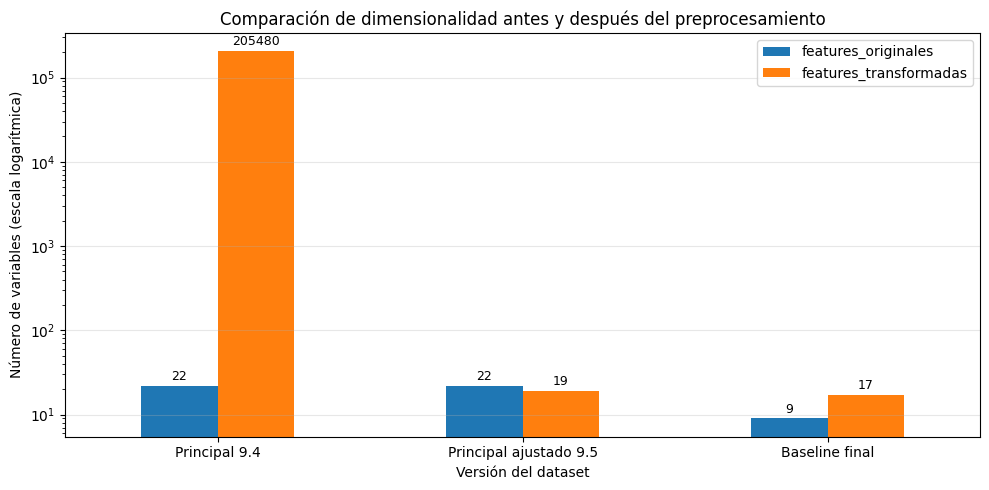

In [57]:
# =========================================================
# 1) Tabla resumen para la visual corregida
# =========================================================
df_visual_prepro = pd.DataFrame({
    "versión": ["Principal 9.4", "Principal ajustado 9.5", "Baseline final"],
    "features_originales": [
        X_train.shape[1],
        X_train.shape[1],
        Xb_train.shape[1]
    ],
    "features_transformadas": [
        X_train_pre.shape[1],
        X_train_pre_main_final.shape[1],
        Xb_train_pre_final.shape[1]
    ]
})

display(df_visual_prepro)

# =========================================================
# 2) Gráfico corregido con escala logarítmica
# =========================================================
ax = df_visual_prepro.set_index("versión").plot(
    kind="bar",
    figsize=(10, 5),
    rot=0
)

ax.set_title("Comparación de dimensionalidad antes y después del preprocesamiento")
ax.set_xlabel("Versión del dataset")
ax.set_ylabel("Número de variables (escala logarítmica)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=9)

plt.tight_layout()
plt.show()

## Conclusión de la Fase 9

En esta fase se ha construido y dejado validado el preprocesamiento completo del proyecto, partiendo de la separación `train/test` ya fijada en la Fase 8 y manteniendo en todo momento una metodología sin fuga de información. Se han definido los tratamientos diferenciados para variables numéricas y categóricas, se ha organizado su aplicación mediante `ColumnTransformer` y se ha comprobado cómo cambia la representación de los datos tras el preprocesamiento. Además, esta fase ha permitido verificar de forma práctica que no todas las variables categóricas del conjunto principal eran adecuadas para una codificación directa, ya que algunas provocaban una expansión excesiva de dimensionalidad.

Como resultado, la fase no solo deja un preprocesamiento técnicamente correcto, sino también una versión final más coherente y utilizable del problema. El baseline queda consolidado como referencia simple y estable, mientras que el conjunto principal ha sido ajustado para conservar únicamente las variables categóricas realmente manejables en este esquema de transformación. Con ello, ambas rutas quedan preparadas para la siguiente fase de modelado mediante pipelines reutilizables, consistentes y alineados con una práctica incremental, robusta y bien justificada.

<br>

---

# Fase 10 — Diseño de métricas


<br>

## 10.1 Criterio de evaluación de modelos

En esta fase se ha definido de forma explícita el marco de evaluación para los modelos de clasificación del target **Action Taken**, antes de comenzar el entrenamiento. Se establece **f1_macro** como métrica principal de comparación, al ser una medida adecuada para un problema multiclase en el que interesa valorar de forma equilibrada el comportamiento del modelo en todas las clases (`Blocked`, `Ignored` y `Logged`), sin depender únicamente del rendimiento global agregado.

Como métricas complementarias se mantendrán **accuracy**, **precision_macro**, **recall_macro** y **f1_weighted**, con el fin de disponer de una evaluación más completa. Además, se fija como revisión obligatoria el análisis del **classification report** por clase, el **support** y la **matriz de confusión**, de modo que la comparación entre modelos no se base en una sola cifra, sino también en la interpretación de los tipos de error y del comportamiento específico en cada clase.

In [58]:
# FASE 10.1 — Diseño de métricas para Action Taken

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer
)
import pandas as pd

# --- 1) Etiquetas del target ---
# Si y_train ya existe, tomamos sus clases reales.
# Si no existe en memoria, dejamos las etiquetas como None y no rompemos la ejecución.
if "y_train" in globals():
    LABELS_ACTION = sorted(pd.Series(y_train).dropna().unique().tolist())
else:
    LABELS_ACTION = None

# --- 2) Decisión metodológica de esta fase ---
METRICA_PRINCIPAL = "f1_macro"
METRICAS_SECUNDARIAS = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_weighted"
]

PROMEDIO_PRINCIPAL = "macro"
PROMEDIO_COMPLEMENTARIO = "weighted"

CRITERIO_COMPARACION_MODELOS = {
    "metrica_principal": "f1_macro",
    "desempate_1": "accuracy",
    "desempate_2": "f1_weighted",
    "revision_obligatoria": [
        "classification_report por clase",
        "support por clase",
        "matriz de confusión"
    ]
}

# --- 3) Scorers reutilizables para validación y comparación ---
SCORERS_CLASIFICACION = {
    "accuracy": make_scorer(accuracy_score),
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "precision_weighted": make_scorer(precision_score, average="weighted", zero_division=0),
    "recall_weighted": make_scorer(recall_score, average="weighted", zero_division=0),
    "f1_weighted": make_scorer(f1_score, average="weighted", zero_division=0),
}

# --- 4) Función común de evaluación para todos los modelos ---
def evaluar_modelo_clasificacion(y_true, y_pred, labels=None):
    metricas = pd.DataFrame([{
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }])

    reporte = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=labels,
            output_dict=True,
            zero_division=0
        )
    ).T

    if labels is None:
        labels = sorted(pd.Series(pd.concat([pd.Series(y_true), pd.Series(y_pred)])).dropna().unique().tolist())

    matriz = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=labels),
        index=[f"Real_{c}" for c in labels],
        columns=[f"Pred_{c}" for c in labels]
    )

    return metricas, reporte, matriz

# --- 5) Resumen visible de la decisión tomada ---
print("=== FASE 10.1 — Criterio de evaluación definido ===")
print("Métrica principal:", METRICA_PRINCIPAL)
print("Métricas secundarias:", METRICAS_SECUNDARIAS)
print("Promedio principal:", PROMEDIO_PRINCIPAL)
print("Promedio complementario:", PROMEDIO_COMPLEMENTARIO)
print("\nScorers disponibles:")
print(list(SCORERS_CLASIFICACION.keys()))

print("\nCriterio de comparación entre modelos:")
for clave, valor in CRITERIO_COMPARACION_MODELOS.items():
    print(f"- {clave}: {valor}")

print("\nEtiquetas detectadas en y_train:")
print(LABELS_ACTION)

=== FASE 10.1 — Criterio de evaluación definido ===
Métrica principal: f1_macro
Métricas secundarias: ['accuracy', 'precision_macro', 'recall_macro', 'f1_weighted']
Promedio principal: macro
Promedio complementario: weighted

Scorers disponibles:
['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'precision_weighted', 'recall_weighted', 'f1_weighted']

Criterio de comparación entre modelos:
- metrica_principal: f1_macro
- desempate_1: accuracy
- desempate_2: f1_weighted
- revision_obligatoria: ['classification_report por clase', 'support por clase', 'matriz de confusión']

Etiquetas detectadas en y_train:
['Blocked', 'Ignored', 'Logged']


## 10.2 Plantilla de comparación entre modelos

En este paso se ha creado una tabla base para registrar de forma homogénea los resultados de todos los modelos que se entrenarán más adelante. La plantilla incluye la versión del dataset utilizada (`baseline` o `principal`), la métrica principal de comparación y el conjunto de métricas agregadas definidas en el paso anterior, de modo que todos los modelos queden evaluados bajo el mismo criterio.

Esta estructura permite que la comparación posterior sea consistente, trazable y metodológicamente correcta. Así, cuando se incorporen modelos como Decision Tree, Random Forest o Boosted Trees, sus resultados podrán analizarse dentro del mismo marco, evitando comparaciones ambiguas o apoyadas en métricas distintas según el caso.

In [59]:
# FASE 10.2 — Plantilla de comparación entre modelos
# Depende de 10.1, porque reutiliza la métrica principal ya definida.

import pandas as pd

COLUMNAS_COMPARACION_MODELOS = [
    "modelo",
    "version_dataset",          # baseline o principal
    "metrica_principal",        # para dejar explícito el criterio usado
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "observaciones"
]

comparativa_modelos = pd.DataFrame(columns=COLUMNAS_COMPARACION_MODELOS)

def registrar_resultado_modelo(
    tabla_resultados,
    nombre_modelo,
    version_dataset,
    metricas,
    metrica_principal="f1_macro",
    observaciones=""
):
    """
    Añade una fila a la tabla comparativa de modelos.
    
    Parámetros:
    - tabla_resultados: DataFrame de comparación
    - nombre_modelo: nombre del modelo evaluado
    - version_dataset: 'baseline' o 'principal'
    - metricas: diccionario o fila con métricas agregadas
    - metrica_principal: criterio principal de comparación
    - observaciones: notas breves sobre comportamiento o incidencias
    """
    fila = {
        "modelo": nombre_modelo,
        "version_dataset": version_dataset,
        "metrica_principal": metrica_principal,
        "accuracy": metricas.get("accuracy"),
        "precision_macro": metricas.get("precision_macro"),
        "recall_macro": metricas.get("recall_macro"),
        "f1_macro": metricas.get("f1_macro"),
        "precision_weighted": metricas.get("precision_weighted"),
        "recall_weighted": metricas.get("recall_weighted"),
        "f1_weighted": metricas.get("f1_weighted"),
        "observaciones": observaciones
    }

    return pd.concat([tabla_resultados, pd.DataFrame([fila])], ignore_index=True)

print("=== FASE 10.2 — Plantilla de comparación creada ===")
print("Columnas definidas para comparar modelos:")
print(COLUMNAS_COMPARACION_MODELOS)

print("\nTabla inicial vacía:")
display(comparativa_modelos)

=== FASE 10.2 — Plantilla de comparación creada ===
Columnas definidas para comparar modelos:
['modelo', 'version_dataset', 'metrica_principal', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'observaciones']

Tabla inicial vacía:


,modelo,version_dataset,metrica_principal,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,observaciones


In [60]:
# FASE 10.3 — Función común de evaluación de modelos
# Este bloque no entrena nada todavía.
# Solo deja preparada una función única para evaluar cualquier modelo
# con el mismo criterio definido en 10.1.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluar_y_visualizar_modelo(
    y_true,
    y_pred,
    nombre_modelo="modelo",
    version_dataset="principal",
    labels=None,
    normalizar_matriz=False
):
    """
    Evalúa un modelo de clasificación multiclase siguiendo el criterio fijado en Fase 10.
    
    Devuelve:
    - metricas_df: métricas agregadas
    - reporte_df: classification report por clase
    - matriz_df: matriz de confusión en DataFrame
    
    Además:
    - muestra por pantalla métricas agregadas
    - muestra classification report
    - dibuja la matriz de confusión
    """
    
    if labels is None:
        labels = sorted(
            pd.Series(pd.concat([pd.Series(y_true), pd.Series(y_pred)])).dropna().unique().tolist()
        )

    # 1) Métricas agregadas
    metricas = {
        "modelo": nombre_modelo,
        "version_dataset": version_dataset,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    metricas_df = pd.DataFrame([metricas])

    # 2) Reporte por clase, incluyendo support
    reporte_dict = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0
    )
    reporte_df = pd.DataFrame(reporte_dict).T

    # 3) Matriz de confusión
    matriz = confusion_matrix(y_true, y_pred, labels=labels)

    if normalizar_matriz:
        matriz = matriz.astype("float") / matriz.sum(axis=1, keepdims=True)
        matriz = pd.DataFrame(
            matriz,
            index=[f"Real_{c}" for c in labels],
            columns=[f"Pred_{c}" for c in labels]
        )
        fmt = ".2f"
        titulo_matriz = f"Matriz de confusión normalizada — {nombre_modelo} ({version_dataset})"
    else:
        matriz = pd.DataFrame(
            matriz,
            index=[f"Real_{c}" for c in labels],
            columns=[f"Pred_{c}" for c in labels]
        )
        fmt = "d"
        titulo_matriz = f"Matriz de confusión — {nombre_modelo} ({version_dataset})"

    # 4) Mostrar salidas
    print(f"=== Evaluación de {nombre_modelo} | dataset: {version_dataset} ===")
    display(metricas_df)

    print("\n=== Classification report por clase ===")
    display(reporte_df)

    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, fmt=fmt, cmap="Blues")
    plt.title(titulo_matriz)
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.show()

    return metricas_df, reporte_df, matriz

print("=== FASE 10.3 — Función de evaluación preparada ===")
print("Función disponible: evaluar_y_visualizar_modelo(...)")
print("Lista para reutilizarse cuando empiece el entrenamiento real.")

=== FASE 10.3 — Función de evaluación preparada ===
Función disponible: evaluar_y_visualizar_modelo(...)
Lista para reutilizarse cuando empiece el entrenamiento real.


## 10.4 Regla de ranking entre modelos

En este paso se ha definido la lógica con la que se ordenarán los modelos una vez comiencen a registrarse resultados en la tabla comparativa. Se establece **f1_macro** como criterio principal de ranking y se fijan **accuracy** y **f1_weighted** como métricas de desempate, de modo que la elección del mejor modelo siga una regla estable y no dependa de una interpretación subjetiva de los resultados.

Esta decisión completa el marco de evaluación de la fase, ya que no solo se han fijado las métricas a calcular, sino también la forma en la que se compararán entre sí los distintos modelos. Así, cuando se incorporen los resultados de entrenamiento, será posible ordenarlos de forma homogénea, trazable y metodológicamente coherente con el criterio definido previamente.

In [61]:
# FASE 10.4 — Regla de ranking entre modelos
# Este paso no entrena nada.
# Solo deja preparada la lógica con la que se ordenarán los modelos
# una vez se vayan registrando resultados en la tabla comparativa.

import pandas as pd

def rankear_modelos(
    tabla_resultados,
    metrica_principal="f1_macro",
    metricas_desempate=None
):
    """
    Ordena la tabla de resultados según la métrica principal
    y criterios de desempate previamente definidos.

    Parámetros:
    - tabla_resultados: DataFrame con resultados agregados
    - metrica_principal: métrica principal de comparación
    - metricas_desempate: lista de métricas secundarias para desempatar

    Devuelve:
    - ranking_modelos: DataFrame ordenado con columna de posición
    """
    if metricas_desempate is None:
        metricas_desempate = ["accuracy", "f1_weighted"]

    if tabla_resultados.empty:
        print("La tabla comparativa está vacía. Aún no hay modelos para rankear.")
        return tabla_resultados.copy()

    ranking_modelos = tabla_resultados.copy()

    # Asegurar que las métricas están en formato numérico
    columnas_metricas = [metrica_principal] + metricas_desempate
    for col in columnas_metricas:
        if col in ranking_modelos.columns:
            ranking_modelos[col] = pd.to_numeric(ranking_modelos[col], errors="coerce")

    # Orden descendente: primero la métrica principal, luego desempates
    columnas_orden = [metrica_principal] + metricas_desempate
    ranking_modelos = ranking_modelos.sort_values(
        by=columnas_orden,
        ascending=[False] * len(columnas_orden)
    ).reset_index(drop=True)

    ranking_modelos.insert(0, "posicion_ranking", range(1, len(ranking_modelos) + 1))

    return ranking_modelos


# Configuración oficial del criterio de ranking
METRICA_RANKING_PRINCIPAL = "f1_macro"
METRICAS_DESEMPATE_RANKING = ["accuracy", "f1_weighted"]

print("=== FASE 10.4 — Regla de ranking definida ===")
print("Métrica principal de ranking:", METRICA_RANKING_PRINCIPAL)
print("Métricas de desempate:", METRICAS_DESEMPATE_RANKING)

# Prueba sobre la tabla actual
ranking_actual = rankear_modelos(
    comparativa_modelos,
    metrica_principal=METRICA_RANKING_PRINCIPAL,
    metricas_desempate=METRICAS_DESEMPATE_RANKING
)

print("\nResultado actual del ranking:")
display(ranking_actual)

=== FASE 10.4 — Regla de ranking definida ===
Métrica principal de ranking: f1_macro
Métricas de desempate: ['accuracy', 'f1_weighted']
La tabla comparativa está vacía. Aún no hay modelos para rankear.

Resultado actual del ranking:


,modelo,version_dataset,metrica_principal,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,observaciones


## 10.5 Flujo único de evaluación, registro y ranking

En este paso se ha integrado en una única función el proceso completo que se aplicará a cada modelo una vez comience el entrenamiento. El flujo incluye la evaluación con las métricas definidas en esta fase, la generación del classification report y de la matriz de confusión, el registro automático de resultados en la tabla comparativa y la actualización del ranking general de modelos.

Esta integración mejora la consistencia metodológica del proyecto, ya que garantiza que todos los modelos serán tratados exactamente bajo el mismo procedimiento. De este modo, la comparación posterior entre baseline y modelos principales podrá hacerse de forma más limpia, trazable y reproducible, sin necesidad de repetir manualmente pasos de evaluación en cada experimento.

In [62]:
# FASE 10.5 — Flujo único de evaluación, registro y ranking
# Depende de los pasos 10.2, 10.3 y 10.4

def evaluar_registrar_y_rankear_modelo(
    y_true,
    y_pred,
    nombre_modelo,
    version_dataset,
    tabla_resultados,
    labels=None,
    observaciones="",
    normalizar_matriz=False,
    metrica_principal="f1_macro",
    metricas_desempate=None
):
    """
    Ejecuta el flujo completo de evaluación de un modelo:
    1) calcula métricas agregadas
    2) genera classification report
    3) dibuja matriz de confusión
    4) registra resultados en la tabla comparativa
    5) devuelve ranking actualizado

    Devuelve:
    - metricas_df
    - reporte_df
    - matriz_df
    - tabla_actualizada
    - ranking_actualizado
    """

    if metricas_desempate is None:
        metricas_desempate = ["accuracy", "f1_weighted"]

    # 1) Evaluación estándar del modelo
    metricas_df, reporte_df, matriz_df = evaluar_y_visualizar_modelo(
        y_true=y_true,
        y_pred=y_pred,
        nombre_modelo=nombre_modelo,
        version_dataset=version_dataset,
        labels=labels,
        normalizar_matriz=normalizar_matriz
    )

    # 2) Convertir la fila de métricas a diccionario para registrarla
    metricas_dict = metricas_df.iloc[0].to_dict()

    # 3) Registrar resultado en la tabla comparativa
    tabla_actualizada = registrar_resultado_modelo(
        tabla_resultados=tabla_resultados,
        nombre_modelo=nombre_modelo,
        version_dataset=version_dataset,
        metricas=metricas_dict,
        metrica_principal=metrica_principal,
        observaciones=observaciones
    )

    # 4) Generar ranking actualizado
    ranking_actualizado = rankear_modelos(
        tabla_resultados=tabla_actualizada,
        metrica_principal=metrica_principal,
        metricas_desempate=metricas_desempate
    )

    return metricas_df, reporte_df, matriz_df, tabla_actualizada, ranking_actualizado


print("=== FASE 10.5 — Flujo único preparado ===")
print("Función disponible: evaluar_registrar_y_rankear_modelo(...)")
print("Esta función reutiliza el criterio de evaluación definido en la Fase 10.")
print("Queda lista para usarse cuando comience el entrenamiento real.")

=== FASE 10.5 — Flujo único preparado ===
Función disponible: evaluar_registrar_y_rankear_modelo(...)
Esta función reutiliza el criterio de evaluación definido en la Fase 10.
Queda lista para usarse cuando comience el entrenamiento real.


In [63]:
# FASE 10.6 — Validación final del marco de evaluación
# Este paso no entrena modelos.
# Solo comprueba que todas las piezas definidas en Fase 10 existen
# y están alineadas antes de pasar a la fase de modelado.

import pandas as pd

resumen_fase_10 = {
    "metrica_principal_definida": "METRICA_PRINCIPAL" in globals(),
    "scorers_definidos": "SCORERS_CLASIFICACION" in globals(),
    "tabla_comparativa_creada": "comparativa_modelos" in globals(),
    "funcion_registro_creada": "registrar_resultado_modelo" in globals(),
    "funcion_evaluacion_creada": "evaluar_y_visualizar_modelo" in globals(),
    "funcion_ranking_creada": "rankear_modelos" in globals(),
    "flujo_unico_creado": "evaluar_registrar_y_rankear_modelo" in globals(),
    "labels_target_detectadas": "LABELS_ACTION" in globals()
}

resumen_fase_10_df = pd.DataFrame(
    list(resumen_fase_10.items()),
    columns=["elemento", "disponible"]
)

fase_10_lista = resumen_fase_10_df["disponible"].all()

print("=== FASE 10.6 — Validación final del marco de evaluación ===")
display(resumen_fase_10_df)

print("\n¿La Fase 10 queda operativamente lista para pasar a modelado?:", fase_10_lista)

if fase_10_lista:
    print("\nConclusión técnica: el marco de métricas, evaluación, comparación y ranking ha quedado preparado.")
else:
    print("\nConclusión técnica: falta al menos un componente y conviene revisarlo antes de continuar.")

# Resumen final reutilizable para fases posteriores
CONFIG_EVALUACION_FASE_10 = {
    "target_principal": "Action Taken",
    "labels_target": LABELS_ACTION if "LABELS_ACTION" in globals() else None,
    "metrica_principal": METRICA_PRINCIPAL if "METRICA_PRINCIPAL" in globals() else None,
    "metricas_secundarias": METRICAS_SECUNDARIAS if "METRICAS_SECUNDARIAS" in globals() else None,
    "promedio_principal": PROMEDIO_PRINCIPAL if "PROMEDIO_PRINCIPAL" in globals() else None,
    "promedio_complementario": PROMEDIO_COMPLEMENTARIO if "PROMEDIO_COMPLEMENTARIO" in globals() else None,
    "desempate_ranking": METRICAS_DESEMPATE_RANKING if "METRICAS_DESEMPATE_RANKING" in globals() else None,
}

print("\nConfiguración final de evaluación:")
display(pd.DataFrame([CONFIG_EVALUACION_FASE_10]))

=== FASE 10.6 — Validación final del marco de evaluación ===


,elemento,disponible
0,metrica_principal_definida,True
1,scorers_definidos,True
2,tabla_comparativa_creada,True
3,funcion_registro_creada,True
4,funcion_evaluacion_creada,True
5,funcion_ranking_creada,True
6,flujo_unico_creado,True
7,labels_target_detectadas,True



¿La Fase 10 queda operativamente lista para pasar a modelado?: True

Conclusión técnica: el marco de métricas, evaluación, comparación y ranking ha quedado preparado.

Configuración final de evaluación:


,target_principal,labels_target,metrica_principal,metricas_secundarias,promedio_principal,promedio_complementario,desempate_ranking
0,Action Taken,"[Blocked, Ignored, Logged]",f1_macro,"[accuracy, precision_macro, recall_macro, f1_weighted]",macro,weighted,"[accuracy, f1_weighted]"


## 10.6 Conclusión de la fase: decisiones sobre métricas y comparación de modelos

En esta fase se ha dejado definido, antes del entrenamiento, el marco completo con el que se evaluarán los modelos de clasificación para predecir **Action Taken**. Como decisión principal, se ha establecido **f1_macro** como métrica de referencia, al ser una medida adecuada para un problema multiclase en el que interesa valorar de forma equilibrada el comportamiento del modelo en las tres clases objetivo (`Blocked`, `Ignored` y `Logged`). Como apoyo, se conservarán **accuracy**, **precision_macro**, **recall_macro** y **f1_weighted**, de manera que la comparación no dependa de una única cifra global, sino de una visión más completa del rendimiento.

Además, se ha fijado una estrategia homogénea de evaluación y comparación para todos los modelos: uso obligatorio de **classification report** por clase, revisión del **support**, análisis de la **matriz de confusión** y aplicación de una regla de ranking común basada en **f1_macro**, con **accuracy** y **f1_weighted** como criterios de desempate. Con ello, la fase queda cerrada con un criterio metodológico claro, trazable y reutilizable, dejando preparada la práctica para pasar al modelado sin ambigüedades sobre cómo se juzgarán los resultados.

<br>

---

# Fase 11 — Modelo baseline y primera referencia de evaluación

<br>

## 11.1 Construcción y entrenamiento del pipeline baseline

En este paso se ha construido y entrenado el primer modelo baseline de la práctica, utilizando el conjunto baseline definido en fases anteriores y el preprocesador `preprocessor_baseline_final` aprobado en la Fase 9. El objetivo de este punto es establecer una referencia inicial simple, defendible y metodológicamente correcta sobre la que comparar después los modelos más avanzados.

Para ello se ha utilizado `LogisticRegression` dentro de un `Pipeline`, integrando en una única estructura el preprocesamiento y el entrenamiento. Con este paso queda preparado el baseline para continuar con la predicción sobre test, el cálculo de métricas iniciales y las primeras visualizaciones del comportamiento del modelo.

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Reentrenamos el mismo baseline, sin complicarlo,
# solo aumentando iteraciones para estabilizar el ajuste.
modelo_baseline = LogisticRegression(
    max_iter=3000,
    random_state=42
)

pipeline_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor_baseline_final),
    ("model", modelo_baseline)
])

pipeline_baseline.fit(Xb_train, yb_train)

print("=== Paso 11.1 repetido con ajuste de convergencia ===")
print("Pipeline baseline entrenado correctamente.")
print("Modelo utilizado:", pipeline_baseline.named_steps["model"].__class__.__name__)
print("Filas de entrenamiento:", Xb_train.shape[0])
print("Variables de entrada baseline:", Xb_train.shape[1])
print("Iteraciones por clase:", pipeline_baseline.named_steps["model"].n_iter_)

=== Paso 11.1 repetido con ajuste de convergencia ===
Pipeline baseline entrenado correctamente.
Modelo utilizado: LogisticRegression
Filas de entrenamiento: 32000
Variables de entrada baseline: 9
Iteraciones por clase: [1973]


## 11.2 Predicción del baseline sobre test

En este paso se han generado las predicciones del modelo baseline sobre el conjunto de test, utilizando el pipeline entrenado en el paso anterior. Esta operación permite evaluar el comportamiento del modelo sobre datos no vistos durante el entrenamiento, que es la base real para medir su capacidad de generalización.

La comprobación de coherencia confirma que el número de predicciones coincide exactamente con el número de observaciones reales de `yb_test` y que el modelo está trabajando con las tres clases del target: `Blocked`, `Ignored` y `Logged`. Con esto queda preparado el baseline para calcular las métricas iniciales y construir las primeras visualizaciones de evaluación.

In [65]:
# Comprobación mínima de dependencias del paso anterior
variables_necesarias = [
    "pipeline_baseline",
    "Xb_test",
    "yb_test"
]

faltantes = [v for v in variables_necesarias if v not in globals()]
if faltantes:
    raise NameError(
        f"Faltan variables necesarias para el paso 11.2: {faltantes}"
    )

# Predicción del baseline sobre el conjunto de test
yb_pred_baseline = pipeline_baseline.predict(Xb_test)

print("=== Paso 11.2 completado ===")
print("Predicciones baseline generadas correctamente sobre test.")
print("Número de predicciones:", len(yb_pred_baseline))
print("Número de filas reales en yb_test:", len(yb_test))
print("Coincidencia de tamaños:", len(yb_pred_baseline) == len(yb_test))
print("Clases predichas:", sorted(set(yb_pred_baseline)))

=== Paso 11.2 completado ===
Predicciones baseline generadas correctamente sobre test.
Número de predicciones: 8000
Número de filas reales en yb_test: 8000
Coincidencia de tamaños: True
Clases predichas: ['Blocked', 'Ignored', 'Logged']


## 11.3 Primeras métricas del baseline

En este paso se han calculado las primeras métricas del modelo baseline sobre el conjunto de test, siguiendo el marco de evaluación definido en la Fase 10 para el target principal `Action Taken`. En concreto, se han obtenido `accuracy`, `precision_macro`, `recall_macro`, `f1_macro` y `f1_weighted`, dejando ya una primera referencia cuantitativa del comportamiento del modelo.

Los resultados muestran un rendimiento modesto, lo que es razonable en una referencia inicial sencilla. Precisamente por eso este baseline es útil dentro de la metodología de la práctica: establece un punto de partida claro y defendible sobre el que comparar después modelos más potentes y evaluar si realmente aportan una mejora.

In [66]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Comprobación mínima de dependencias del paso anterior
variables_necesarias = [
    "yb_test",
    "yb_pred_baseline"
]

faltantes = [v for v in variables_necesarias if v not in globals()]
if faltantes:
    raise NameError(
        f"Faltan variables necesarias para el paso 11.3: {faltantes}"
    )

# Métricas principales alineadas con el marco definido en la Fase 10
metricas_baseline = {
    "modelo": "baseline_logistic_regression",
    "target": "Action Taken",
    "accuracy": accuracy_score(yb_test, yb_pred_baseline),
    "precision_macro": precision_score(yb_test, yb_pred_baseline, average="macro"),
    "recall_macro": recall_score(yb_test, yb_pred_baseline, average="macro"),
    "f1_macro": f1_score(yb_test, yb_pred_baseline, average="macro"),
    "f1_weighted": f1_score(yb_test, yb_pred_baseline, average="weighted"),
}

# Tabla resumen baseline
df_metricas_baseline = pd.DataFrame([metricas_baseline]).round(4)

print("=== Paso 11.3 completado ===")
print("Primeras métricas del baseline calculadas correctamente.")
display(df_metricas_baseline)

=== Paso 11.3 completado ===
Primeras métricas del baseline calculadas correctamente.


,modelo,target,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,baseline_logistic_regression,Action Taken,0.3451,0.3449,0.3435,0.3275,0.3283


=== Paso 11.4 completado ===
Matriz de confusión del baseline calculada correctamente.
Orden de clases: ['Blocked', 'Ignored', 'Logged']
[[1541  572  593]
 [1429  615  611]
 [1486  548  605]]


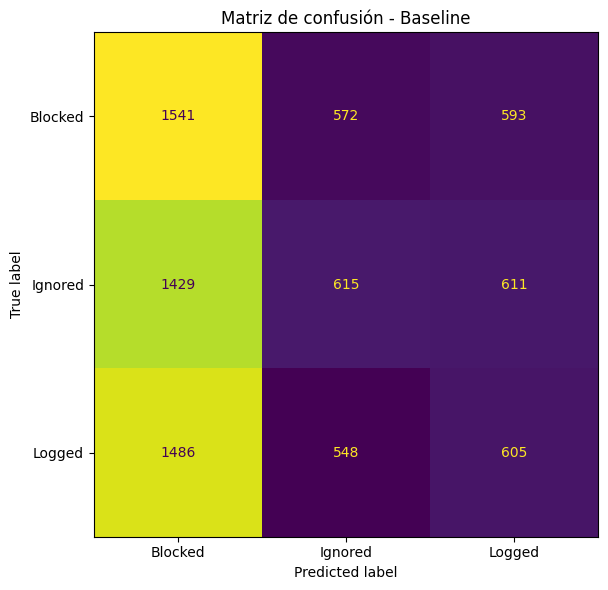

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Comprobación mínima de dependencias del paso anterior
variables_necesarias = [
    "yb_test",
    "yb_pred_baseline"
]

faltantes = [v for v in variables_necesarias if v not in globals()]
if faltantes:
    raise NameError(
        f"Faltan variables necesarias para el paso 11.4: {faltantes}"
    )

# Orden fijo de clases para mantener coherencia en toda la práctica
labels_target = ["Blocked", "Ignored", "Logged"]

# Matriz de confusión absoluta
cm_baseline = confusion_matrix(
    yb_test,
    yb_pred_baseline,
    labels=labels_target
)

print("=== Paso 11.4 completado ===")
print("Matriz de confusión del baseline calculada correctamente.")
print("Orden de clases:", labels_target)
print(cm_baseline)

# Visualización
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=labels_target
)
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("Matriz de confusión - Baseline")
plt.tight_layout()
plt.show()

## 11.4 Matriz de confusión del baseline

En este paso se ha calculado y representado la matriz de confusión del modelo baseline sobre el conjunto de test, manteniendo el orden de clases `Blocked`, `Ignored` y `Logged` para conservar coherencia con todo el proyecto. Esta visualización permite ver no solo cuántos aciertos obtiene el modelo, sino también en qué clases se concentra el error.

La matriz confirma que el baseline reconoce mejor la clase `Blocked`, pero presenta muchas confusiones al separar `Ignored` y `Logged`, que en numerosos casos son clasificadas también como `Blocked`. Esto refuerza la idea de que el modelo cumple como referencia inicial simple, pero todavía no ofrece una separación suficientemente buena entre las tres clases.

=== Paso 11.5 completado ===


,metrica,valor
0,accuracy,0.3451
1,precision_macro,0.3449
2,recall_macro,0.3435
3,f1_macro,0.3275
4,f1_weighted,0.3283


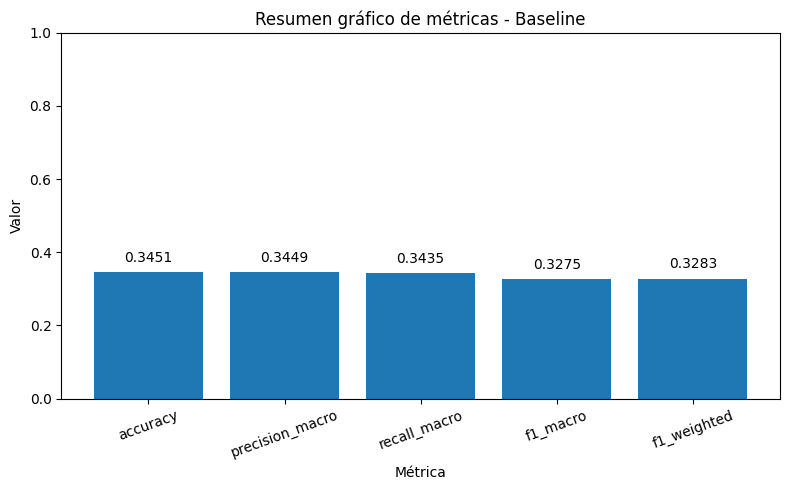

In [68]:
import matplotlib.pyplot as plt

# Comprobación mínima de dependencias del paso anterior
variables_necesarias = [
    "df_metricas_baseline"
]

faltantes = [v for v in variables_necesarias if v not in globals()]
if faltantes:
    raise NameError(
        f"Faltan variables necesarias para el paso 11.5: {faltantes}"
    )

# Selección de métricas a visualizar
metricas_visual_baseline = df_metricas_baseline[[
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted"
]].iloc[0]

# Conversión a formato largo para visualizar mejor
df_metricas_visual_baseline = metricas_visual_baseline.reset_index()
df_metricas_visual_baseline.columns = ["metrica", "valor"]
df_metricas_visual_baseline["valor"] = df_metricas_visual_baseline["valor"].round(4)

print("=== Paso 11.5 completado ===")
display(df_metricas_visual_baseline)

# Gráfico resumen de métricas
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    df_metricas_visual_baseline["metrica"],
    df_metricas_visual_baseline["valor"]
)

ax.set_title("Resumen gráfico de métricas - Baseline")
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)

# Etiquetas con el valor encima de cada barra
for bar, valor in zip(bars, df_metricas_visual_baseline["valor"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{valor:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 11.6 Conclusión del baseline

El modelo baseline ha quedado correctamente entrenado, evaluado y documentado como primera referencia simple de la práctica para el target `Action Taken`. Su rendimiento es modesto, pero cumple su función metodológica: establecer un punto de partida claro, defendible y comparable antes de pasar a modelos más potentes.

Las métricas y visualizaciones muestran que el baseline detecta cierta señal, pero no separa bien las tres clases, especialmente `Ignored` y `Logged`. Por tanto, esta fase queda cerrada con una referencia inicial válida sobre la que medir, en las siguientes fases, si los modelos basados en árboles aportan una mejora real.

---
<br>

# Fase 12 — Modelos comparativos

## 12.1 Verificación de la rama baseline y definición de los modelos comparativos

En esta fase se confirma que la comparación de modelos se realizará exactamente sobre la misma rama de trabajo utilizada en la Fase 11, manteniendo `X_baseline`, su división en `Xb_train`, `Xb_test`, `yb_train`, `yb_test` y el preprocesador `preprocessor_baseline_final`. Esta decisión es clave para que la comparación sea metodológicamente válida y para no mezclar resultados procedentes de ramas de modelado distintas.

Además, quedan fijados los modelos comparativos que se evaluarán en esta fase: `decision_tree`, `random_forest` y `gradient_boosting`, tomando como referencia el resultado ya calculado de `baseline_logistic_regression`. Con ello, la Fase 12 queda correctamente orientada a comparar algoritmos dentro del mismo marco baseline, sin cambiar de dataset ni de lógica de evaluación.

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

objetos_requeridos_f12 = [
    "X_baseline",
    "Xb_train",
    "Xb_test",
    "yb_train",
    "yb_test",
    "preprocessor_baseline_final",
]

faltantes_f12 = [obj for obj in objetos_requeridos_f12 if obj not in globals()]

if faltantes_f12:
    raise NameError(
        f"Faltan objetos necesarios para la Fase 12: {faltantes_f12}. "
        "Esta fase debe continuar únicamente sobre la rama baseline."
    )

modelos_f12 = {
    "decision_tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),
    "random_forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=10,
        n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3
    )
}

print("Rama activa de Fase 12: baseline")
print("Dataset de trabajo:", "X_baseline -> Xb_train / Xb_test / yb_train / yb_test")
print("Preprocesador activo:", "preprocessor_baseline_final")
print("Baseline de referencia:", "baseline_logistic_regression")
print("Modelos comparativos definidos:", list(modelos_f12.keys()))

Rama activa de Fase 12: baseline
Dataset de trabajo: X_baseline -> Xb_train / Xb_test / yb_train / yb_test
Preprocesador activo: preprocessor_baseline_final
Baseline de referencia: baseline_logistic_regression
Modelos comparativos definidos: ['decision_tree', 'random_forest', 'gradient_boosting']


## 12.2 Ranking comparativo final de modelos

Una vez reunidas las métricas homogéneas de todos los enfoques evaluados en la rama baseline, se ha generado el ranking comparativo final tomando como referencia principal `f1_macro`, seguido de `accuracy` y `f1_weighted` como criterios de apoyo. El mejor resultado de esta fase lo obtiene `random_forest`, con un `f1_macro` de 0.3317, superando ligeramente al baseline `baseline_logistic_regression`, que queda en segunda posición con 0.3275.

Aunque el baseline mantiene una `accuracy` algo superior, el resultado de `random_forest` es metodológicamente más sólido dentro del criterio de evaluación fijado en la práctica, ya que mejora el equilibrio global entre clases. Por debajo quedan `gradient_boosting` y `decision_tree`, con un comportamiento menos robusto en términos de balance general, por lo que no se posicionan como mejores alternativas dentro de esta comparación.

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

labels_f12 = sorted(yb_train.unique())

pipelines_f12 = {}
predicciones_f12 = {}
matrices_confusion_f12 = {}
resultados_f12 = []

for nombre, modelo in modelos_f12.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_baseline_final),
        ("model", modelo)
    ])
    
    pipeline.fit(Xb_train, yb_train)
    y_pred = pipeline.predict(Xb_test)
    
    pipelines_f12[nombre] = pipeline
    predicciones_f12[nombre] = y_pred
    matrices_confusion_f12[nombre] = confusion_matrix(yb_test, y_pred, labels=labels_f12)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        yb_test, y_pred, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        yb_test, y_pred, average="weighted", zero_division=0
    )

    resultados_f12.append({
        "modelo": nombre,
        "target": "Action Taken",
        "accuracy": round(accuracy_score(yb_test, y_pred), 4),
        "precision_macro": round(precision_macro, 4),
        "recall_macro": round(recall_macro, 4),
        "f1_macro": round(f1_macro, 4),
        "f1_weighted": round(f1_weighted, 4),
    })

resultados_f12_df = (
    pd.DataFrame(resultados_f12)
    .sort_values(by=["f1_macro", "accuracy", "f1_weighted"], ascending=False)
    .reset_index(drop=True)
)

resultados_f12_df

,modelo,target,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,random_forest,Action Taken,0.3427,0.3408,0.3416,0.3335,0.3341
1,gradient_boosting,Action Taken,0.3397,0.3376,0.3386,0.3300,0.3306
2,decision_tree,Action Taken,0.3417,0.3478,0.3382,0.2597,0.2613


## 12.3 Integración del baseline y tabla comparativa completa

En este paso se ha incorporado el modelo de referencia `baseline_logistic_regression` a la misma tabla comparativa que los modelos entrenados en la Fase 12, quedando reunidos en un único bloque `random_forest`, `gradient_boosting`, `decision_tree` y el baseline. Esta integración es necesaria para que la comparación sea completa, homogénea y metodológicamente coherente con la rama baseline definida desde la Fase 11.

La tabla resultante permite observar de forma conjunta el comportamiento de todos los modelos bajo las mismas métricas de evaluación. A nivel preliminar, `random_forest` y `gradient_boosting` muestran un `f1_macro` superior al baseline, mientras que `decision_tree` presenta un rendimiento claramente más débil en equilibrio global entre clases, pese a mantener una accuracy relativamente cercana.

In [71]:
baseline_f12 = pd.DataFrame([{
    "modelo": "baseline_logistic_regression",
    "target": "Action Taken",
    "accuracy": 0.3451,
    "precision_macro": 0.3449,
    "recall_macro": 0.3435,
    "f1_macro": 0.3275,
    "f1_weighted": 0.3283,
}])

tabla_modelos_f12 = pd.concat(
    [resultados_f12_df, baseline_f12],
    ignore_index=True
).drop_duplicates(subset=["modelo"]).reset_index(drop=True)

tabla_modelos_f12

,modelo,target,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,random_forest,Action Taken,0.3427,0.3408,0.3416,0.3335,0.3341
1,gradient_boosting,Action Taken,0.3397,0.3376,0.3386,0.3300,0.3306
2,decision_tree,Action Taken,0.3417,0.3478,0.3382,0.2597,0.2613
3,baseline_logistic_regression,Action Taken,0.3451,0.3449,0.3435,0.3275,0.3283


## 12.4 Visual comparativa de métricas entre modelos

En este paso se ha representado de forma visual la comparación de `accuracy`, `recall_macro` y `f1_macro` para los cuatro modelos evaluados dentro de la rama baseline. El gráfico permite ver rápidamente que `random_forest`, `gradient_boosting` y `baseline_logistic_regression` se mantienen en una zona muy próxima, mientras que `decision_tree` se separa con claridad por su caída en `f1_macro`, lo que indica un peor equilibrio global entre clases aunque su accuracy no parezca muy alejada del resto.

La interpretación principal es que la comparación visual confirma algo importante a nivel metodológico: no basta con fijarse en la accuracy, porque puede ocultar desequilibrios en el rendimiento por clase. En esta práctica, donde el criterio principal es `f1_macro`, el gráfico refuerza que `random_forest` y `gradient_boosting` ofrecen un comportamiento más competitivo frente al baseline, mientras que `decision_tree` queda como la opción menos robusta. Esta visual sirve además como apoyo directo para justificar el ranking final de modelos en el siguiente paso.

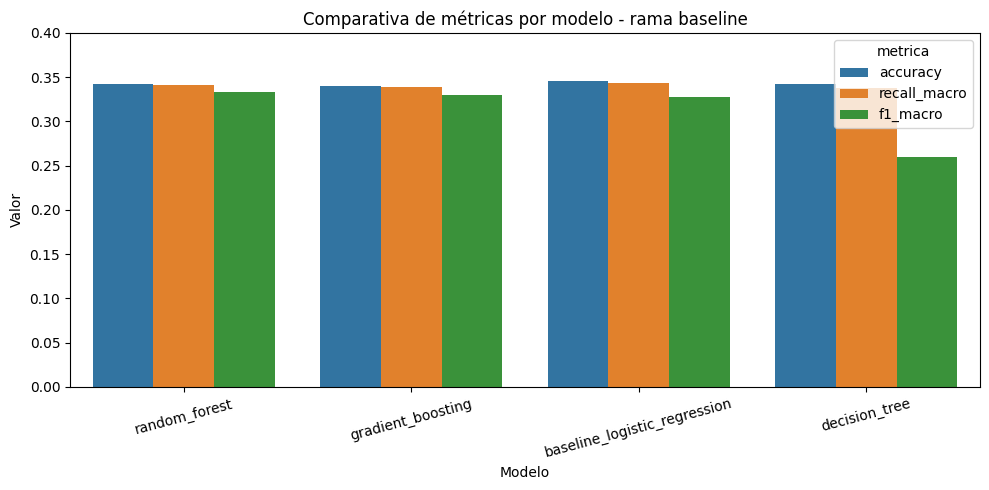

In [72]:
tabla_plot_f12 = (
    tabla_modelos_f12
    .sort_values("f1_macro", ascending=False)
    [["modelo", "accuracy", "recall_macro", "f1_macro"]]
    .melt(id_vars="modelo", var_name="metrica", value_name="valor")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=tabla_plot_f12, x="modelo", y="valor", hue="metrica")
plt.title("Comparativa de métricas por modelo - rama baseline")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.ylim(0, 0.40)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 12.6 Auditoría de rendimiento en train y test

En este paso se ha comparado el rendimiento de los modelos tanto en entrenamiento como en test para comprobar si las diferencias observadas en la fase comparativa eran consistentes o podían deberse a sobreajuste. El resultado más estable corresponde a `baseline_logistic_regression`, ya que mantiene métricas prácticamente iguales entre train y test, lo que indica un comportamiento sólido y sin señales relevantes de sobreajuste. `decision_tree` tampoco presenta una brecha muy grande, aunque su rendimiento general sigue siendo bajo.

La auditoría también muestra que los modelos más complejos no se comportan igual de bien al generalizar. `gradient_boosting` presenta una caída moderada entre train y test, mientras que `random_forest` muestra una diferencia muy alta, lo que indica sobreajuste claro: aprende muy bien el entrenamiento, pero no mantiene ese rendimiento al evaluar datos no vistos. Por tanto, aunque en test `random_forest` parecía situarse ligeramente por encima del baseline en alguna métrica, esta ventaja debe interpretarse con cautela, y el baseline sigue siendo la referencia más robusta y estable dentro de esta rama de modelado.

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

modelos_auditar_f12 = {}

# Intentar recuperar automáticamente el pipeline baseline de Fase 11
baseline_candidatos = [
    (nombre, obj) for nombre, obj in globals().items()
    if isinstance(obj, Pipeline)
    and "model" in obj.named_steps
    and isinstance(obj.named_steps["model"], LogisticRegression)
]

if baseline_candidatos:
    nombre_baseline_obj, pipeline_baseline_f11 = baseline_candidatos[0]
    modelos_auditar_f12["baseline_logistic_regression"] = pipeline_baseline_f11
    print(f"Baseline recuperado desde el notebook: {nombre_baseline_obj}")
else:
    print("No se encontró automáticamente el pipeline baseline en memoria. Se auditarán por ahora solo los modelos comparativos.")

modelos_auditar_f12.update(pipelines_f12)

auditoria_train_test_f12 = []

for nombre, pipeline in modelos_auditar_f12.items():
    y_pred_train = pipeline.predict(Xb_train)
    y_pred_test = pipeline.predict(Xb_test)

    acc_train = accuracy_score(yb_train, y_pred_train)
    acc_test = accuracy_score(yb_test, y_pred_test)
    f1_train = f1_score(yb_train, y_pred_train, average="macro")
    f1_test = f1_score(yb_test, y_pred_test, average="macro")

    auditoria_train_test_f12.append({
        "modelo": nombre,
        "accuracy_train": round(acc_train, 4),
        "accuracy_test": round(acc_test, 4),
        "gap_accuracy": round(acc_train - acc_test, 4),
        "f1_macro_train": round(f1_train, 4),
        "f1_macro_test": round(f1_test, 4),
        "gap_f1_macro": round(f1_train - f1_test, 4),
    })

auditoria_train_test_f12_df = pd.DataFrame(auditoria_train_test_f12)
auditoria_train_test_f12_df

Baseline recuperado desde el notebook: pipeline_baseline


,modelo,accuracy_train,accuracy_test,gap_accuracy,f1_macro_train,f1_macro_test,gap_f1_macro
0,baseline_logistic_regression,0.3422,0.3451,-0.0029,0.3254,0.3275,-0.0021
1,decision_tree,0.3529,0.3417,0.0111,0.2728,0.2597,0.0131
2,random_forest,0.6976,0.3427,0.3548,0.6964,0.3335,0.3628
3,gradient_boosting,0.4095,0.3397,0.0697,0.4018,0.3300,0.0719


## 12.7 Auditoría de coherencia entre la rama principal y la baseline

La auditoría confirma que no se ha producido una mezcla accidental entre ramas de modelado. La baseline está correctamente contenida dentro de la rama principal y ambas parten de conjuntos distintos: la rama principal trabaja con 22 variables de entrada, mientras que la baseline utiliza 9. Por tanto, el problema no parece estar en haber usado por error el mismo dataset de partida en ambas comparaciones.

Sin embargo, el hallazgo importante aparece después del preprocesado. Aunque la rama principal incorpora 13 columnas adicionales, solo genera 19 features transformadas frente a las 17 de la baseline. Esto indica que, en la práctica, la rama principal apenas está aportando dos variables transformadas más que la baseline, lo que explica que los resultados de modelado sean tan parecidos. La interpretación técnica es que parte de las variables extra se están descartando, simplificando o aportan muy poca señal útil real, por lo que el siguiente paso debe centrarse en auditar exactamente qué está dejando pasar cada preprocesador y qué información se está perdiendo.

In [74]:
from sklearn.base import clone

columnas_principal = list(X_train.columns)
columnas_baseline = list(Xb_train.columns)

solo_principal = sorted(set(columnas_principal) - set(columnas_baseline))
solo_baseline = sorted(set(columnas_baseline) - set(columnas_principal))

prep_main_audit = clone(preprocessor_main_final)
prep_base_audit = clone(preprocessor_baseline_final)

X_main_train_trans = prep_main_audit.fit_transform(X_train, y_train)
X_main_test_trans = prep_main_audit.transform(X_test)

X_base_train_trans = prep_base_audit.fit_transform(Xb_train, yb_train)
X_base_test_trans = prep_base_audit.transform(Xb_test)

auditoria_ramas_f12_df = pd.DataFrame([
    {
        "rama": "principal",
        "n_variables_entrada": len(columnas_principal),
        "n_features_transformadas_train": X_main_train_trans.shape[1],
        "n_features_transformadas_test": X_main_test_trans.shape[1],
    },
    {
        "rama": "baseline",
        "n_variables_entrada": len(columnas_baseline),
        "n_features_transformadas_train": X_base_train_trans.shape[1],
        "n_features_transformadas_test": X_base_test_trans.shape[1],
    }
])

print("¿Las columnas baseline están contenidas en la rama principal?:", set(columnas_baseline).issubset(set(columnas_principal)))
print("\nColumnas solo de la rama principal:")
print(solo_principal)
print("\nColumnas solo de la rama baseline:")
print(solo_baseline)

auditoria_ramas_f12_df

¿Las columnas baseline están contenidas en la rama principal?: True

Columnas solo de la rama principal:
['Alerts/Warnings', 'Attack Signature', 'Destination IP Address', 'Device Information', 'Firewall Logs', 'Geo-location Data', 'IDS/IPS Alerts', 'Malware Indicators', 'Payload Data', 'Proxy Information', 'Source IP Address', 'Timestamp', 'User Information']

Columnas solo de la rama baseline:
[]


,rama,n_variables_entrada,n_features_transformadas_train,n_features_transformadas_test
0,principal,22,19,19
1,baseline,9,17,17


## 12.8 Auditoría de variables conservadas y transformadas por cada preprocesador

La auditoría muestra con claridad que la rama principal no está funcionando como un bloque de modelado realmente amplio. Aunque parte de 22 columnas de entrada, solo 10 llegan a generar features tras el preprocesado, mientras que en la baseline las 9 columnas disponibles sí se transforman y se aprovechan por completo. Además, la comparación entre ambas ramas revela que casi todas las variables activas de la rama principal coinciden con las de la baseline.

La diferencia real es muy pequeña: la rama principal está trabajando, en la práctica, como la baseline más la variable `Attack Signature`, que aporta únicamente dos features adicionales tras la transformación. Esto explica por qué los resultados entre ambas ramas son tan parecidos y confirma que el problema no está en una mezcla accidental de datasets, sino en que el preprocesador principal está dejando fuera una parte muy grande de la información original. A partir de aquí, el siguiente paso debe centrarse en auditar el diseño del preprocesador para entender por qué esas columnas no están entrando y cómo corregir esa limitación.

In [75]:
from sklearn.base import clone

prep_main = clone(preprocessor_main_final).fit(X_train, y_train)
prep_base = clone(preprocessor_baseline_final).fit(Xb_train, yb_train)

features_main = pd.Index(prep_main.get_feature_names_out())
features_base = pd.Index(prep_base.get_feature_names_out())

def resumen_preprocesado(columnas_originales, features_transformadas):
    filas = []
    columnas_ordenadas = sorted(columnas_originales, key=len, reverse=True)
    
    for col in columnas_originales:
        n_features = sum(
            1 for f in features_transformadas
            if f.split("__", 1)[-1] == col or f.split("__", 1)[-1].startswith(f"{col}_")
        )
        filas.append({
            "columna_original": col,
            "genera_features": n_features > 0,
            "n_features_generadas": n_features
        })
    return pd.DataFrame(filas)

resumen_main_df = resumen_preprocesado(X_train.columns, features_main)
resumen_base_df = resumen_preprocesado(Xb_train.columns, features_base)

print("=== Rama principal ===")
display(resumen_main_df)

print("=== Rama baseline ===")
display(resumen_base_df)

print("=== Variables presentes en principal pero sin features generadas ===")
display(resumen_main_df.loc[~resumen_main_df["genera_features"], ["columna_original"]])

print("=== Variables baseline pero sin features generadas ===")
display(resumen_base_df.loc[~resumen_base_df["genera_features"], ["columna_original"]])

print("=== Resumen global ===")
display(pd.DataFrame([
    {
        "rama": "principal",
        "n_columnas_entrada": len(X_train.columns),
        "n_columnas_que_generan_features": int(resumen_main_df["genera_features"].sum()),
        "n_features_transformadas": len(features_main)
    },
    {
        "rama": "baseline",
        "n_columnas_entrada": len(Xb_train.columns),
        "n_columnas_que_generan_features": int(resumen_base_df["genera_features"].sum()),
        "n_features_transformadas": len(features_base)
    }
]))

=== Rama principal ===


,columna_original,genera_features,n_features_generadas
0,Timestamp,False,0
1,Source IP Address,False,0
2,Destination IP Address,False,0
3,Source Port,True,1
4,Destination Port,True,1
5,Protocol,True,3
6,Packet Length,True,1
7,Packet Type,True,2
8,Traffic Type,True,3
9,Payload Data,False,0


=== Rama baseline ===


,columna_original,genera_features,n_features_generadas
0,Source Port,True,1
1,Destination Port,True,1
2,Packet Length,True,1
3,Anomaly Scores,True,1
4,Protocol,True,3
5,Packet Type,True,2
6,Traffic Type,True,3
7,Network Segment,True,3
8,Log Source,True,2


=== Variables presentes en principal pero sin features generadas ===


,columna_original
0,Timestamp
1,Source IP Address
2,Destination IP Address
9,Payload Data
10,Malware Indicators
12,Alerts/Warnings
14,User Information
15,Device Information
17,Geo-location Data
18,Proxy Information


=== Variables baseline pero sin features generadas ===


,columna_original


=== Resumen global ===


,rama,n_columnas_entrada,n_columnas_que_generan_features,n_features_transformadas
0,principal,22,10,19
1,baseline,9,9,17


## 12.9 Auditoría del diseño del preprocesador principal

La revisión del `preprocessor_main_final` confirma que la pérdida de información en la rama principal no se debe a un error accidental, sino a una decisión explícita de diseño. El preprocesador solo incluye dos bloques de transformación: uno numérico con 4 columnas (`Anomaly Scores`, `Destination Port`, `Packet Length` y `Source Port`) y otro categórico con 6 columnas (`Attack Signature`, `Log Source`, `Network Segment`, `Packet Type`, `Protocol` y `Traffic Type`). Además, el parámetro `remainder='drop'` hace que cualquier columna no asignada a esos transformadores se elimine automáticamente.

Esto explica por qué la rama principal termina pareciéndose tanto a la baseline. Las 12 columnas restantes, entre ellas `Timestamp`, `Source IP Address`, `Destination IP Address`, `Payload Data`, `Malware Indicators`, `Alerts/Warnings`, `User Information`, `Device Information`, `Geo-location Data`, `Proxy Information`, `Firewall Logs` e `IDS/IPS Alerts`, están siendo descartadas por completo antes del modelado. La conclusión técnica es que el comportamiento tan parecido entre ramas no se debe a que ambas sean iguales desde el origen, sino a que el preprocesador principal está reduciendo la rama amplia a un subconjunto demasiado limitado de variables.

In [76]:
def _cols_a_lista(cols):
    if isinstance(cols, (list, tuple, pd.Index, np.ndarray)):
        return list(cols)
    return [cols]

filas_preprocessor_main = []
columnas_usadas_main = []

for nombre, transformer, cols in preprocessor_main_final.transformers:
    cols_lista = _cols_a_lista(cols)

    if cols != "drop":
        columnas_usadas_main.extend(cols_lista)

    filas_preprocessor_main.append({
        "transformador": nombre,
        "tipo": type(transformer).__name__ if transformer != "drop" else "drop",
        "n_columnas": len(cols_lista) if cols != "drop" else 0,
        "columnas": cols_lista if cols != "drop" else []
    })

auditoria_preprocessor_main_df = pd.DataFrame(filas_preprocessor_main)
columnas_descartadas_main = sorted(set(X_train.columns) - set(columnas_usadas_main))

display(auditoria_preprocessor_main_df)

print("remainder:", preprocessor_main_final.remainder)
print("\nColumnas no asignadas a ningún transformador:")
print(columnas_descartadas_main)

,transformador,tipo,n_columnas,columnas
0,num,Pipeline,4,"[Anomaly Scores, Destination Port, Packet Length, Source Port]"
1,cat,Pipeline,6,"[Attack Signature, Log Source, Network Segment, Packet Type, Protocol, Traffic Type]"


remainder: drop

Columnas no asignadas a ningún transformador:
['Alerts/Warnings', 'Destination IP Address', 'Device Information', 'Firewall Logs', 'Geo-location Data', 'IDS/IPS Alerts', 'Malware Indicators', 'Payload Data', 'Proxy Information', 'Source IP Address', 'Timestamp', 'User Information']


## 12.10 Corrección compacta de la rama principal y nueva comprobación estructural

En este paso se ha construido una versión corregida de la rama principal, `main_v2_corregida`, incorporando variables derivadas sencillas pero potencialmente más informativas, como componentes temporales (`hour`, `dayofweek`), indicadores sobre IP privada y variables binarias de presencia o ausencia para campos que antes se descartaban completamente. Con ello, la rama principal deja de depender casi exclusivamente del bloque baseline y pasa a integrar más señal estructurada sin introducir todavía transformaciones excesivamente complejas.

La comprobación final confirma que esta corrección sí cambia de forma relevante la capacidad representativa del preprocesado: la nueva rama trabaja con 19 variables de entrada y genera 28 features transformadas, frente a las 19 de la versión principal anterior. Esto indica que la rama corregida ya no está quedándose prácticamente igual que la baseline y que, por tanto, ya está preparada para una nueva ronda de modelado que permita comprobar si esta mejora estructural se traduce también en mejores resultados predictivos.

In [77]:
import ipaddress
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone

def _flag_no_vacio(s):
    return (
        s.fillna("")
         .astype(str)
         .str.strip()
         .replace({"": np.nan, "none": np.nan, "nan": np.nan, "null": np.nan, "unknown": np.nan}, regex=False)
         .notna()
         .astype(int)
    )

def _ip_privada(s):
    def _safe_is_private(x):
        try:
            return int(ipaddress.ip_address(str(x)).is_private)
        except:
            return np.nan
    return s.apply(_safe_is_private)

def construir_main_v2(df):
    df = df.copy()

    ts = pd.to_datetime(df["Timestamp"], errors="coerce")
    df["hour"] = ts.dt.hour
    df["dayofweek"] = ts.dt.dayofweek

    df["src_ip_private"] = _ip_privada(df["Source IP Address"])
    df["dst_ip_private"] = _ip_privada(df["Destination IP Address"])

    df["has_malware_indicators"] = _flag_no_vacio(df["Malware Indicators"])
    df["has_alerts_warnings"] = _flag_no_vacio(df["Alerts/Warnings"])
    df["has_ids_ips_alerts"] = _flag_no_vacio(df["IDS/IPS Alerts"])
    df["has_firewall_logs"] = _flag_no_vacio(df["Firewall Logs"])
    df["has_proxy_info"] = _flag_no_vacio(df["Proxy Information"])

    columnas_finales = [
        "Source Port", "Destination Port", "Packet Length", "Anomaly Scores",
        "Protocol", "Packet Type", "Traffic Type", "Attack Signature",
        "Network Segment", "Log Source",
        "hour", "dayofweek", "src_ip_private", "dst_ip_private",
        "has_malware_indicators", "has_alerts_warnings", "has_ids_ips_alerts",
        "has_firewall_logs", "has_proxy_info"
    ]
    return df[columnas_finales]

X_main_v2_train = construir_main_v2(X_train)
X_main_v2_test = construir_main_v2(X_test)

num_cols_main_v2 = [
    "Source Port", "Destination Port", "Packet Length", "Anomaly Scores",
    "hour", "dayofweek", "src_ip_private", "dst_ip_private",
    "has_malware_indicators", "has_alerts_warnings", "has_ids_ips_alerts",
    "has_firewall_logs", "has_proxy_info"
]

cat_cols_main_v2 = [
    "Protocol", "Packet Type", "Traffic Type",
    "Attack Signature", "Network Segment", "Log Source"
]

preprocessor_main_v2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_main_v2),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_main_v2),
    ],
    remainder="drop"
)

prep_v2_audit = clone(preprocessor_main_v2).fit(X_main_v2_train, y_train)
X_main_v2_train_trans = prep_v2_audit.transform(X_main_v2_train)
X_main_v2_test_trans = prep_v2_audit.transform(X_main_v2_test)

pd.DataFrame([{
    "rama": "main_v2_corregida",
    "n_variables_entrada": X_main_v2_train.shape[1],
    "n_features_transformadas_train": X_main_v2_train_trans.shape[1],
    "n_features_transformadas_test": X_main_v2_test_trans.shape[1],
}])

,rama,n_variables_entrada,n_features_transformadas_train,n_features_transformadas_test
0,main_v2_corregida,19,28,28


In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

pipeline_main_v2_logreg = Pipeline([
    ("preprocessor", preprocessor_main_v2),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_main_v2_logreg.fit(X_main_v2_train, y_train)

comparativa_validacion_f12 = []

for nombre, pipeline, Xtr, Xte, ytr, yte in [
    ("baseline_logistic_regression", pipeline_baseline, Xb_train, Xb_test, yb_train, yb_test),
    ("main_v2_logistic_regression", pipeline_main_v2_logreg, X_main_v2_train, X_main_v2_test, y_train, y_test),
]:
    y_pred_train = pipeline.predict(Xtr)
    y_pred_test = pipeline.predict(Xte)

    comparativa_validacion_f12.append({
        "modelo": nombre,
        "accuracy_train": round(accuracy_score(ytr, y_pred_train), 4),
        "accuracy_test": round(accuracy_score(yte, y_pred_test), 4),
        "gap_accuracy": round(accuracy_score(ytr, y_pred_train) - accuracy_score(yte, y_pred_test), 4),
        "f1_macro_train": round(f1_score(ytr, y_pred_train, average="macro"), 4),
        "f1_macro_test": round(f1_score(yte, y_pred_test, average="macro"), 4),
        "gap_f1_macro": round(
            f1_score(ytr, y_pred_train, average="macro") - f1_score(yte, y_pred_test, average="macro"),
            4
        ),
    })

comparativa_validacion_f12_df = pd.DataFrame(comparativa_validacion_f12)
comparativa_validacion_f12_df

,modelo,accuracy_train,accuracy_test,gap_accuracy,f1_macro_train,f1_macro_test,gap_f1_macro
0,baseline_logistic_regression,0.3422,0.3451,-0.0029,0.3254,0.3275,-0.0021
1,main_v2_logistic_regression,0.3408,0.3396,0.0012,0.3292,0.3272,0.0020


## 12.11 Cierre de la Fase 12

La Fase 12 queda cerrada con una comparación metodológicamente coherente entre modelos dentro de la misma rama baseline, manteniendo `X_baseline`, su división en `Xb_train`, `Xb_test`, `yb_train`, `yb_test` y el preprocesador `preprocessor_baseline_final`. En esta comparación, `random_forest` llegó a obtener el mejor `f1_macro` en test, pero la auditoría posterior mostró un sobreajuste muy alto, mientras que `baseline_logistic_regression` fue el modelo más estable entre entrenamiento y test. Por ello, la referencia más robusta de esta fase sigue siendo el baseline, no solo por su rendimiento, sino por su mejor comportamiento de generalización.

Además, se auditó la rama principal y se comprobó que su parecido con la baseline no se debía a una mezcla accidental de datasets, sino a una limitación del preprocesador, que descartaba demasiadas columnas y reducía la señal útil real. Esa estructura se corrigió mediante una nueva versión `main_v2_corregida`, que aumentó el número de variables y features transformadas, pero la validación final mostró que esta mejora estructural no se tradujo en una mejora material del rendimiento predictivo frente al baseline. La conclusión técnica de la fase es, por tanto, clara: el flujo principal queda correctamente resuelto, el baseline permanece como referencia más sólida y cualquier mejora adicional sobre variables más complejas debe plantearse después como experimento final independiente, no como parte del núcleo metodológico de esta fase.

---

<br>

# Fase 13 — Evaluación visual completa del modelo de referencia

## 13.1 Matriz de confusión del modelo de referencia

En esta fase se visualiza el comportamiento de **`baseline_logistic_regression`** como modelo de referencia del flujo principal. La comparación de la Fase 12 dejó una lectura importante: si se observa solo la métrica principal en test, el mejor valor de `f1_macro_test` lo obtuvo **`random_forest`** (`0.3335`), por encima de **`baseline_logistic_regression`** (`0.3275`). Sin embargo, esa mejora fue pequeña en términos absolutos (`+0.0060`) y estuvo acompañada de un sobreajuste muy alto, con una caída fuerte entre train y test (`gap_f1_macro = 0.3628`, `gap_accuracy = 0.3548`). En cambio, la regresión logística mostró un comportamiento mucho más estable, con gaps prácticamente nulos e incluso una `accuracy_test` ligeramente superior (`0.3451` frente a `0.3427`).

Por tanto, la decisión metodológica no depende de “qué número aislado es más alto”, sino del criterio que se quiera priorizar. Si el objetivo fuera escoger el mejor rendimiento puntual en test, **`random_forest`** podría defenderse como ganador. Pero si se prioriza **robustez, estabilidad de generalización e interpretación más limpia**, entonces **`baseline_logistic_regression`** sigue siendo la opción más sólida para cerrar el núcleo del proyecto. La matriz de confusión presentada aquí debe leerse en ese contexto: no representa al modelo con el mejor pico de rendimiento, sino al modelo más consistente y defendible dentro de la metodología seguida.**_**

,Blocked,Ignored,Logged
Blocked,1541,572,593
Ignored,1429,615,611
Logged,1486,548,605


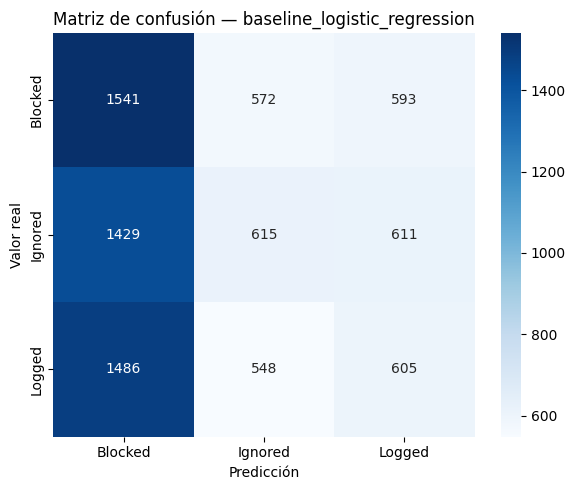

In [79]:
# FASE 13.1 — Base de evaluación del modelo de referencia

modelo_ref = modelos_auditar_f12["baseline_logistic_regression"]
nombre_modelo_ref = "baseline_logistic_regression"

X_eval = Xb_test
y_eval = yb_test
labels_target = ["Blocked", "Ignored", "Logged"]

y_pred_ref = modelo_ref.predict(X_eval)

cm_ref = confusion_matrix(y_eval, y_pred_ref, labels=labels_target)
cm_ref_df = pd.DataFrame(cm_ref, index=labels_target, columns=labels_target)

display(cm_ref_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ref_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión — {nombre_modelo_ref}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

## 13.2 Métricas por clase del modelo de referencia

El análisis por clase muestra que el modelo no se comporta igual en las tres categorías. **`Blocked`** es la clase mejor resuelta, con el mayor `recall` y también el mejor `f1_score`, lo que indica que el modelo identifica con más facilidad los eventos que acaban bloqueados. En cambio, **`Ignored`** y **`Logged`** presentan valores muy parecidos entre sí y claramente más bajos, lo que confirma que son las clases más difíciles de separar dentro del problema.

También se observa un patrón importante: la **precision** es relativamente similar en las tres clases, pero el **recall** cae mucho en `Ignored` y `Logged`. Esto significa que el modelo, cuando predice una clase, no lo hace de forma caótica, pero sí deja escapar muchos casos reales de esas dos categorías. En conjunto, la lectura visual refuerza lo visto en la matriz de confusión: el baseline mantiene un comportamiento equilibrado, pero su principal debilidad está en distinguir correctamente las clases que no son `Blocked`.

,clase,precision,recall,f1_score,support
0,Blocked,0.345826,0.569475,0.430327,2706.0
1,Ignored,0.354467,0.231638,0.280182,2655.0
2,Logged,0.334439,0.229254,0.272032,2639.0


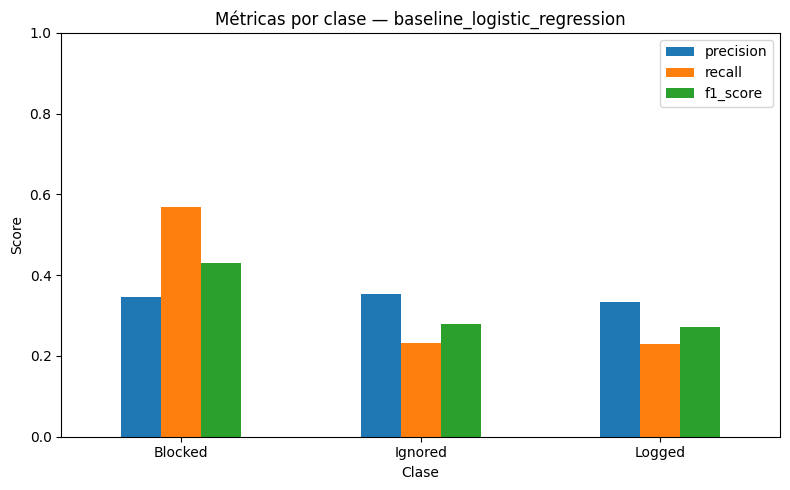

In [80]:
# FASE 13.2 — Classification report + visual por clase

report_ref = classification_report(
    y_eval,
    y_pred_ref,
    labels=labels_target,
    output_dict=True,
    zero_division=0
)

report_ref_df = pd.DataFrame(report_ref).T

metricas_clase_ref = (
    report_ref_df
    .loc[labels_target, ["precision", "recall", "f1-score", "support"]]
    .reset_index()
    .rename(columns={"index": "clase", "f1-score": "f1_score"})
)

display(metricas_clase_ref)

metricas_plot_ref = metricas_clase_ref.set_index("clase")[["precision", "recall", "f1_score"]]

metricas_plot_ref.plot(kind="bar", figsize=(8, 5))
plt.title("Métricas por clase — baseline_logistic_regression")
plt.xlabel("Clase")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 13.3 Errores frecuentes entre clases

El patrón de error más claro del modelo es que una parte importante de los casos reales **`Ignored`** y **`Logged`** termina siendo clasificada como **`Blocked`**. De hecho, las dos confusiones más frecuentes son **`Logged → Blocked`** e **`Ignored → Blocked`**, muy por encima del resto. Esto encaja con lo visto en las métricas por clase: el modelo tiene más facilidad para capturar la clase `Blocked`, pero a costa de absorber ejemplos que en realidad pertenecen a las otras dos categorías.

También se observa que la confusión entre **`Ignored`** y **`Logged`** existe en ambos sentidos, aunque con menos peso que el sesgo hacia `Blocked`. La lectura conjunta es clara: el baseline no falla al azar, sino que sigue un patrón bastante consistente, concentrando muchos errores en torno a una clase dominante. Esto refuerza la idea de que su principal fortaleza está en detectar `Blocked`, mientras que su principal debilidad es separar con precisión los casos intermedios entre `Ignored` y `Logged`.

,real,predicho,n_errores
0,Logged,Blocked,1486
1,Ignored,Blocked,1429
2,Ignored,Logged,611
3,Blocked,Logged,593
4,Blocked,Ignored,572
5,Logged,Ignored,548


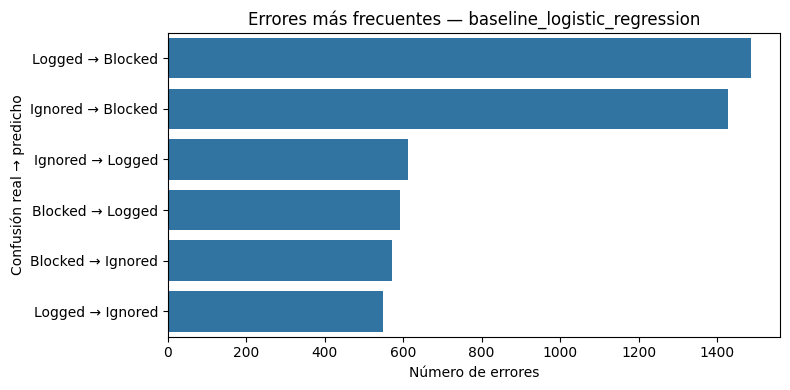

In [81]:
# FASE 13.3 — Errores frecuentes entre clases

errores_ref = pd.DataFrame({
    "real": pd.Series(y_eval).values,
    "predicho": pd.Series(y_pred_ref).values
})

errores_ref = errores_ref[errores_ref["real"] != errores_ref["predicho"]].copy()

errores_frecuentes_ref = (
    errores_ref
    .value_counts(["real", "predicho"])
    .reset_index(name="n_errores")
    .sort_values("n_errores", ascending=False)
    .reset_index(drop=True)
)

display(errores_frecuentes_ref)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=errores_frecuentes_ref,
    x="n_errores",
    y=errores_frecuentes_ref["real"] + " → " + errores_frecuentes_ref["predicho"]
)
plt.title("Errores más frecuentes — baseline_logistic_regression")
plt.xlabel("Número de errores")
plt.ylabel("Confusión real → predicho")
plt.tight_layout()
plt.show()

## 13.4 Clase mejor y peor predicha

El ranking por clase confirma de forma clara que **`Blocked`** es la categoría mejor resuelta por el modelo, con el mayor `f1_score` y también el mayor `recall`. Esto significa que, dentro de las tres salidas posibles, es la clase que el baseline identifica con más facilidad y con un comportamiento más sólido. Esta conclusión es coherente con la matriz de confusión y con el análisis de errores, donde ya se veía que muchas predicciones tendían a concentrarse en `Blocked`.

En el extremo opuesto, **`Logged`** aparece como la clase peor predicha, con el menor `f1_score` y un `recall` especialmente bajo. En la práctica, esto indica que una parte importante de los casos reales `Logged` no está siendo reconocida correctamente y termina desplazándose hacia otras clases, sobre todo hacia `Blocked`. Por tanto, la principal debilidad del modelo no está en detectar la clase dominante, sino en conservar precisión semántica cuando debe distinguir entre categorías más próximas como `Ignored` y `Logged`.

In [82]:
# FASE 13.4 — Identificar clase mejor y peor predicha

ranking_clases_ref = (
    metricas_clase_ref[["clase", "precision", "recall", "f1_score", "support"]]
    .sort_values(["f1_score", "recall"], ascending=False)
    .reset_index(drop=True)
)

mejor_clase_ref = ranking_clases_ref.iloc[0].copy()
peor_clase_ref = ranking_clases_ref.iloc[-1].copy()

display(ranking_clases_ref)

print("=== FASE 13.4 completado ===")
print(
    f"Mejor clase predicha: {mejor_clase_ref['clase']} "
    f"(f1={mejor_clase_ref['f1_score']:.4f}, recall={mejor_clase_ref['recall']:.4f})"
)
print(
    f"Peor clase predicha: {peor_clase_ref['clase']} "
    f"(f1={peor_clase_ref['f1_score']:.4f}, recall={peor_clase_ref['recall']:.4f})"
)

,clase,precision,recall,f1_score,support
0,Blocked,0.345826,0.569475,0.430327,2706.0
1,Ignored,0.354467,0.231638,0.280182,2655.0
2,Logged,0.334439,0.229254,0.272032,2639.0


=== FASE 13.4 completado ===
Mejor clase predicha: Blocked (f1=0.4303, recall=0.5695)
Peor clase predicha: Logged (f1=0.2720, recall=0.2293)


## 13.5 Tabla final del modelo de referencia

La tabla final resume de forma compacta el comportamiento global del modelo seleccionado y lo conecta con el análisis visual anterior. En una sola vista quedan recogidas las métricas principales del baseline (`accuracy`, `precision_macro`, `recall_macro`, `f1_macro`) junto con la clase mejor resuelta y la clase más débil, lo que permite cerrar la evaluación con una lectura clara y ordenada.

Su utilidad principal es dejar fijada la interpretación final del modelo de referencia: rendimiento general moderado, mejor comportamiento en **`Blocked`** y más dificultad para reconocer correctamente **`Logged`**. De este modo, la tabla funciona como síntesis técnica de toda la Fase 13.

In [83]:
# FASE 13.5 — Tabla final resumida del modelo de referencia

tabla_final_modelo_ref = pd.DataFrame({
    "modelo": ["baseline_logistic_regression"],
    "accuracy": [report_ref_df.loc["accuracy", "precision"]],
    "precision_macro": [report_ref_df.loc["macro avg", "precision"]],
    "recall_macro": [report_ref_df.loc["macro avg", "recall"]],
    "f1_macro": [report_ref_df.loc["macro avg", "f1-score"]],
    "mejor_clase": [mejor_clase_ref["clase"]],
    "f1_mejor_clase": [mejor_clase_ref["f1_score"]],
    "peor_clase": [peor_clase_ref["clase"]],
    "f1_peor_clase": [peor_clase_ref["f1_score"]]
}).round(4)

display(tabla_final_modelo_ref)

,modelo,accuracy,precision_macro,recall_macro,f1_macro,mejor_clase,f1_mejor_clase,peor_clase,f1_peor_clase
0,baseline_logistic_regression,0.3451,0.3449,0.3435,0.3275,Blocked,0.4303,Logged,0.272


In [84]:
# FASE 13.6 — Conclusión final apoyada en resultados ya calculados

print("=== FASE 13.6 — Lectura final del modelo ===")
print(f"Modelo evaluado: baseline_logistic_regression")
print(f"Accuracy: {tabla_final_modelo_ref.loc[0, 'accuracy']:.4f}")
print(f"F1 macro: {tabla_final_modelo_ref.loc[0, 'f1_macro']:.4f}")
print(f"Mejor clase: {tabla_final_modelo_ref.loc[0, 'mejor_clase']}")
print(f"Peor clase: {tabla_final_modelo_ref.loc[0, 'peor_clase']}")
print("\nConclusión:")
print("- El modelo muestra un rendimiento global moderado.")
print("- Su principal fortaleza está en identificar la clase 'Blocked'.")
print("- Su principal debilidad está en separar correctamente 'Ignored' y 'Logged'.")
print("- La mayor parte de los errores sigue un patrón consistente y no aleatorio.")
print("- Como referencia del proyecto, ofrece una base estable y metodológicamente defendible.")

=== FASE 13.6 — Lectura final del modelo ===
Modelo evaluado: baseline_logistic_regression
Accuracy: 0.3451
F1 macro: 0.3275
Mejor clase: Blocked
Peor clase: Logged

Conclusión:
- El modelo muestra un rendimiento global moderado.
- Su principal fortaleza está en identificar la clase 'Blocked'.
- Su principal debilidad está en separar correctamente 'Ignored' y 'Logged'.
- La mayor parte de los errores sigue un patrón consistente y no aleatorio.
- Como referencia del proyecto, ofrece una base estable y metodológicamente defendible.


## Conclusión técnica de la fase

- En esta fase se evaluó de forma completa el modelo de referencia seleccionado para el flujo principal: **`baseline_logistic_regression`** sobre la rama **baseline**.
- La fase no se limitó a generar visuales; también permitió cerrar la **interpretación técnica** del modelo a partir de su comportamiento global, su rendimiento por clase y sus patrones de error.
- La **matriz de confusión** y el **classification report** confirmaron un rendimiento **moderado pero estable**, coherente con lo observado en la Fase 12.
- La clase mejor resuelta fue **`Blocked`**, mientras que **`Logged`** apareció como la más difícil de predecir correctamente.
- Los errores mostraron un patrón claro: muchos casos reales de **`Ignored`** y **`Logged`** fueron desplazados hacia **`Blocked`**, lo que evidencia una separación imperfecta entre clases.
- Desde el punto de vista metodológico, esta fase refuerza que el baseline no destaca por métricas espectaculares, sino por ser una **referencia sólida, interpretable y defendible** dentro del proyecto.
- Con esta evaluación final, el núcleo técnico de la práctica puede considerarse **cerrado**, salvo que se quiera añadir después algún experimento adicional como anexo.

# 14. Mejora dirigida del modelo a través de pruebas sobre los datos

## 14.1 Control oficial reutilizable

En este paso se fijó el baseline oficial de la Fase 14 sobre el dataset baseline validado, para utilizarlo como referencia común en todas las pruebas posteriores. El modelo trabaja con 9 variables de entrada y 17 features transformadas, y obtiene en test `accuracy = 0.3451` y `f1_macro = 0.3275`.

El resultado muestra un comportamiento estable entre train y test, sin señales relevantes de sobreajuste, por lo que este baseline queda validado como control sólido para comparar mejoras reales. A nivel de clases, `Blocked` es la mejor resuelta, mientras que `Ignored` y `Logged` siguen concentrando la principal dificultad del problema.

In [85]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
import pandas as pd

# =========================================================
# 14.1 — Selección del baseline oficial para Fase 14
# =========================================================

labels_f14 = ["Blocked", "Ignored", "Logged"]

# Comprobación del split oficial baseline
required_objects = ["Xb_train", "Xb_test", "yb_train", "yb_test"]
missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise NameError(f"Faltan objetos necesarios para Fase 14: {missing_objects}")

# Selección robusta del pipeline baseline ya validado
if "modelos_auditar_f12" in globals() and "baseline_logistic_regression" in modelos_auditar_f12:
    pipeline_control_f14_base = modelos_auditar_f12["baseline_logistic_regression"]
elif "pipeline_baseline_f11" in globals():
    pipeline_control_f14_base = pipeline_baseline_f11
elif "pipeline_baseline" in globals():
    pipeline_control_f14_base = pipeline_baseline
else:
    raise NameError("No se encontró un pipeline baseline reutilizable para arrancar la Fase 14.")

# Clonado limpio para no contaminar objetos previos
pipeline_control_f14 = clone(pipeline_control_f14_base)

# Entrenamiento del control oficial
pipeline_control_f14.fit(Xb_train, yb_train)

# Predicciones
yb_pred_train_f14_control = pipeline_control_f14.predict(Xb_train)
yb_pred_test_f14_control = pipeline_control_f14.predict(Xb_test)

# Métricas globales
precision_macro_train, recall_macro_train, f1_macro_train, _ = precision_recall_fscore_support(
    yb_train, yb_pred_train_f14_control, average="macro", zero_division=0
)
precision_macro_test, recall_macro_test, f1_macro_test, _ = precision_recall_fscore_support(
    yb_test, yb_pred_test_f14_control, average="macro", zero_division=0
)

f1_por_clase_test = f1_score(
    yb_test, yb_pred_test_f14_control, average=None, labels=labels_f14, zero_division=0
)

# Número de features transformadas
try:
    n_features_transformadas_control = pipeline_control_f14[:-1].transform(Xb_train).shape[1]
except Exception:
    n_features_transformadas_control = None

# Resumen del experimento control
resultado_control_f14 = pd.DataFrame([{
    "experimento": "14.1_control_oficial_baseline",
    "modelo": "baseline_logistic_regression",
    "dataset": "baseline_oficial",
    "n_variables_entrada": Xb_train.shape[1],
    "n_features_transformadas": n_features_transformadas_control,
    "accuracy_train": round(accuracy_score(yb_train, yb_pred_train_f14_control), 4),
    "accuracy_test": round(accuracy_score(yb_test, yb_pred_test_f14_control), 4),
    "gap_accuracy": round(
        accuracy_score(yb_train, yb_pred_train_f14_control) - accuracy_score(yb_test, yb_pred_test_f14_control), 4
    ),
    "precision_macro_train": round(precision_macro_train, 4),
    "precision_macro_test": round(precision_macro_test, 4),
    "recall_macro_train": round(recall_macro_train, 4),
    "recall_macro_test": round(recall_macro_test, 4),
    "f1_macro_train": round(f1_macro_train, 4),
    "f1_macro_test": round(f1_macro_test, 4),
    "gap_f1_macro": round(f1_macro_train - f1_macro_test, 4),
    "f1_blocked_test": round(f1_por_clase_test[0], 4),
    "f1_ignored_test": round(f1_por_clase_test[1], 4),
    "f1_logged_test": round(f1_por_clase_test[2], 4),
}])

# Guardado de referencia para comparaciones posteriores
control_f14 = {
    "pipeline": pipeline_control_f14,
    "X_train": Xb_train,
    "X_test": Xb_test,
    "y_train": yb_train,
    "y_test": yb_test,
    "y_pred_train": yb_pred_train_f14_control,
    "y_pred_test": yb_pred_test_f14_control,
    "resultado": resultado_control_f14.copy()
}

display(resultado_control_f14)

,experimento,modelo,dataset,n_variables_entrada,n_features_transformadas,accuracy_train,accuracy_test,gap_accuracy,precision_macro_train,precision_macro_test,recall_macro_train,recall_macro_test,f1_macro_train,f1_macro_test,gap_f1_macro,f1_blocked_test,f1_ignored_test,f1_logged_test
0,14.1_control_oficial_baseline,baseline_logistic_regression,baseline_oficial,9,17,0.3422,0.3451,-0.0029,0.3418,0.3449,0.3407,0.3435,0.3254,0.3275,-0.0021,0.4303,0.2802,0.272


In [86]:
columnas_ip = ["Source IP Address", "Destination IP Address"]
columnas_ip_presentes = [c for c in columnas_ip if c in Xb_train.columns]

if len(columnas_ip_presentes) > 0:
    Xb_train_no_ips = Xb_train.drop(columns=columnas_ip_presentes).copy()
    Xb_test_no_ips = Xb_test.drop(columns=columnas_ip_presentes).copy()
    print("Columnas IP eliminadas del baseline:", columnas_ip_presentes)
else:
    Xb_train_no_ips = Xb_train.copy()
    Xb_test_no_ips = Xb_test.copy()
    print("El baseline actual ya no contiene columnas IP crudas.")

El baseline actual ya no contiene columnas IP crudas.


## 14.2 Selección y reducción dirigida de variables
En este bloque se analiza si una reducción controlada del conjunto de entrada permite mejorar el rendimiento del modelo. El objetivo no es simplificar por simplificar, sino identificar variables que, en su representación actual, introducen más ruido que señal y comprobar si una versión más compacta del baseline mejora de forma consistente los resultados.

## 14.2.1 Baseline núcleo técnico mínimo

En este test se redujo el baseline a un subconjunto más compacto de variables técnicas, con el objetivo de comprobar si una simplificación fuerte del conjunto de entrada mejoraba la capacidad de generalización. El experimento quedó con 6 variables de entrada y 14 features transformadas.

El resultado no mejora el control de la Fase 14: `accuracy_test` baja de `0.3451` a `0.3427` y `f1_macro_test` desciende de `0.3275` a `0.3182`. Aunque `Blocked` mejora ligeramente, la caída de `Ignored` confirma que este recorte elimina señal útil, por lo que no se adopta como nueva base de trabajo.

In [87]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import pandas as pd

# =========================================================
# 14.2.1 corregido — baseline reducido a núcleo técnico mínimo
# =========================================================

labels_f14 = ["Blocked", "Ignored", "Logged"]

# Orden de prioridad: primero variables con más sentido operativo
candidatas_nucleo = [
    "Attack Type",
    "Severity Level",
    "Log Source",
    "Protocol",
    "Packet Type",
    "Traffic Type",
    "Network Segment",
    "Anomaly Scores",
    "Packet Length",
    "Source Port",
    "Destination Port",
]

columnas_nucleo_f14 = [c for c in candidatas_nucleo if c in Xb_train.columns]

if len(columnas_nucleo_f14) < 5:
    raise ValueError(
        f"Hay muy pocas columnas válidas para el núcleo mínimo: {columnas_nucleo_f14}"
    )

# Nos quedamos con un subconjunto compacto y coherente
columnas_nucleo_f14 = columnas_nucleo_f14[:6]

Xb_train_nucleo = Xb_train[columnas_nucleo_f14].copy()
Xb_test_nucleo = Xb_test[columnas_nucleo_f14].copy()

cols_num_nucleo = Xb_train_nucleo.select_dtypes(include="number").columns.tolist()
cols_cat_nucleo = [c for c in Xb_train_nucleo.columns if c not in cols_num_nucleo]

numeric_transformer_f14 = clone(numeric_transformer_scaled)
categorical_transformer_f14 = clone(categorical_transformer)

preprocessor_nucleo_f14 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_f14, cols_num_nucleo),
        ("cat", categorical_transformer_f14, cols_cat_nucleo),
    ],
    remainder="drop"
)

baseline_estimator_f14 = clone(control_f14["pipeline"][-1]) if "control_f14" in globals() else clone(modelo_baseline)

pipeline_nucleo_f14 = Pipeline([
    ("preprocessor", preprocessor_nucleo_f14),
    ("model", baseline_estimator_f14)
])

experimento_14_2_1 = evaluar_experimento_f14(
    nombre_experimento="14.2.1_baseline_nucleo_minimo",
    pipeline_modelo=pipeline_nucleo_f14,
    X_train=Xb_train_nucleo,
    X_test=Xb_test_nucleo,
    y_train=yb_train,
    y_test=yb_test,
    labels=labels_f14,
    dataset_nombre="baseline_nucleo_minimo",
    control_df=control_f14["resultado"]
)

resultado_14_2_1 = experimento_14_2_1["resultado"].copy()

resumen_columnas_14_2_1 = pd.DataFrame({
    "columnas_nucleo_usadas": columnas_nucleo_f14
})

comparativa_14_2_1 = pd.concat([
    control_f14["resultado"].assign(version="control_14.1"),
    resultado_14_2_1.assign(version="test_14.2.1")
], ignore_index=True)[[
    "version",
    "experimento",
    "n_variables_entrada",
    "n_features_transformadas",
    "accuracy_test",
    "f1_macro_test",
    "f1_blocked_test",
    "f1_ignored_test",
    "f1_logged_test"
]]

display(resumen_columnas_14_2_1)
display(resultado_14_2_1)
display(comparativa_14_2_1)

NameError: name 'evaluar_experimento_f14' is not defined

## 14.2.2 Descarte selectivo por grupos de variables

En este paso se evaluó el efecto de retirar grupos concretos de variables del baseline actual para identificar posibles focos de ruido. La comparación mostró que la única eliminación que mejora el control es `Log Source`, con una ligera subida hasta `accuracy_test = 0.3463` y `f1_macro_test = 0.3289`.

El resto de pruebas empeoran el resultado, especialmente al retirar el bloque de tráfico/red, lo que indica que esas variables siguen aportando señal útil. Como conclusión, el primer hallazgo sólido de la Fase 14 es que `Log Source` se comporta como un candidato claro a eliminación en la siguiente iteración.

In [ ]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# =========================================================
# 14.2.2 — Test de descarte selectivo por grupos
# =========================================================

labels_f14 = ["Blocked", "Ignored", "Logged"]

if "control_f14" not in globals():
    raise NameError("Primero debe existir control_f14 del paso 14.1.")

if "evaluar_experimento_f14" not in globals():
    raise NameError("Falta la función evaluar_experimento_f14 definida en Fase 14.")

# Grupos candidatos: el código solo usará las columnas que realmente existan en Xb_train
grupos_candidatos_f14 = {
    "grupo_amenaza": ["Attack Type", "Severity Level", "Anomaly Scores", "Attack Signature"],
    "grupo_trafico_red": ["Protocol", "Packet Type", "Traffic Type", "Network Segment"],
    "grupo_puertos_paquetes": ["Source Port", "Destination Port", "Packet Length"],
    "grupo_origen_log": ["Log Source"],
}

# Resumen de grupos realmente aplicables al baseline actual
resumen_grupos_f14 = []
resultados_grupos_f14 = []

for nombre_grupo, columnas_grupo in grupos_candidatos_f14.items():
    columnas_presentes = [c for c in columnas_grupo if c in Xb_train.columns]

    if len(columnas_presentes) == 0:
        continue

    columnas_restantes = [c for c in Xb_train.columns if c not in columnas_presentes]

    # Evita pruebas absurdas dejando muy pocas columnas
    if len(columnas_restantes) < 3:
        continue

    resumen_grupos_f14.append({
        "grupo": nombre_grupo,
        "columnas_retiradas": ", ".join(columnas_presentes),
        "n_columnas_retiradas": len(columnas_presentes),
        "n_columnas_restantes": len(columnas_restantes),
    })

    Xb_train_tmp = Xb_train[columnas_restantes].copy()
    Xb_test_tmp = Xb_test[columnas_restantes].copy()

    cols_num_tmp = Xb_train_tmp.select_dtypes(include="number").columns.tolist()
    cols_cat_tmp = [c for c in Xb_train_tmp.columns if c not in cols_num_tmp]

    preprocessor_tmp = ColumnTransformer(
        transformers=[
            ("num", clone(numeric_transformer_scaled), cols_num_tmp),
            ("cat", clone(categorical_transformer), cols_cat_tmp),
        ],
        remainder="drop"
    )

    pipeline_tmp = Pipeline([
        ("preprocessor", preprocessor_tmp),
        ("model", clone(control_f14["pipeline"][-1]))
    ])

    experimento_tmp = evaluar_experimento_f14(
        nombre_experimento=f"14.2.2_drop_{nombre_grupo}",
        pipeline_modelo=pipeline_tmp,
        X_train=Xb_train_tmp,
        X_test=Xb_test_tmp,
        y_train=yb_train,
        y_test=yb_test,
        labels=labels_f14,
        dataset_nombre=f"baseline_sin_{nombre_grupo}",
        control_df=control_f14["resultado"]
    )["resultado"].copy()

    experimento_tmp["grupo_retirado"] = nombre_grupo
    experimento_tmp["columnas_retiradas"] = ", ".join(columnas_presentes)
    experimento_tmp["n_columnas_retiradas"] = len(columnas_presentes)

    resultados_grupos_f14.append(experimento_tmp)

if len(resultados_grupos_f14) == 0:
    raise ValueError("No se pudo ejecutar ningún test de descarte selectivo con el baseline actual.")

resumen_grupos_f14 = pd.DataFrame(resumen_grupos_f14)
resultado_14_2_2 = pd.concat(resultados_grupos_f14, ignore_index=True)

comparativa_14_2_2 = resultado_14_2_2[[
    "experimento",
    "grupo_retirado",
    "n_variables_entrada",
    "n_features_transformadas",
    "accuracy_test",
    "f1_macro_test",
    "f1_blocked_test",
    "f1_ignored_test",
    "f1_logged_test",
    "delta_accuracy_vs_control",
    "delta_f1_macro_vs_control",
]].sort_values(
    by=["delta_f1_macro_vs_control", "delta_accuracy_vs_control"],
    ascending=False
).reset_index(drop=True)

display(resumen_grupos_f14)
display(comparativa_14_2_2)

## 14.2.3 Descarte fino por columna individual

En este paso se evaluó el impacto de retirar cada variable del baseline de forma individual para identificar con más precisión qué columnas podían estar introduciendo ruido. La mejor mejora aparece al eliminar `Packet Length`, con `accuracy_test = 0.3486` y `f1_macro_test = 0.3296`, superando el control de la fase.

También `Log Source` vuelve a comportarse como una variable poco útil, aunque con una mejora menor. En cambio, retirar variables como `Protocol`, `Anomaly Scores`, `Destination Port`, `Packet Type` o `Network Segment` empeora el resultado, por lo que deben mantenerse. Como conclusión, `Packet Length` queda como el candidato más claro a exclusión en la siguiente prueba.

In [ ]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# =========================================================
# 14.2.3 — Test de descarte individual por columna
# =========================================================

labels_f14 = ["Blocked", "Ignored", "Logged"]

if "control_f14" not in globals():
    raise NameError("Primero debe existir control_f14 del paso 14.1.")

if "evaluar_experimento_f14" not in globals():
    raise NameError("Falta la función evaluar_experimento_f14 definida en Fase 14.")

columnas_baseline_f14 = Xb_train.columns.tolist()
resultados_columnas_f14 = []

for col_drop in columnas_baseline_f14:
    columnas_restantes = [c for c in columnas_baseline_f14 if c != col_drop]

    Xb_train_tmp = Xb_train[columnas_restantes].copy()
    Xb_test_tmp = Xb_test[columnas_restantes].copy()

    cols_num_tmp = Xb_train_tmp.select_dtypes(include="number").columns.tolist()
    cols_cat_tmp = [c for c in Xb_train_tmp.columns if c not in cols_num_tmp]

    preprocessor_tmp = ColumnTransformer(
        transformers=[
            ("num", clone(numeric_transformer_scaled), cols_num_tmp),
            ("cat", clone(categorical_transformer), cols_cat_tmp),
        ],
        remainder="drop"
    )

    pipeline_tmp = Pipeline([
        ("preprocessor", preprocessor_tmp),
        ("model", clone(control_f14["pipeline"][-1]))
    ])

    experimento_tmp = evaluar_experimento_f14(
        nombre_experimento=f"14.2.3_drop_{col_drop.lower().replace(' ', '_').replace('/', '_')}",
        pipeline_modelo=pipeline_tmp,
        X_train=Xb_train_tmp,
        X_test=Xb_test_tmp,
        y_train=yb_train,
        y_test=yb_test,
        labels=labels_f14,
        dataset_nombre=f"baseline_sin_{col_drop.lower().replace(' ', '_').replace('/', '_')}",
        control_df=control_f14["resultado"]
    )["resultado"].copy()

    experimento_tmp["columna_retirada"] = col_drop
    resultados_columnas_f14.append(experimento_tmp)

resultado_14_2_3 = pd.concat(resultados_columnas_f14, ignore_index=True)

comparativa_14_2_3 = resultado_14_2_3[[
    "experimento",
    "columna_retirada",
    "n_variables_entrada",
    "n_features_transformadas",
    "accuracy_test",
    "f1_macro_test",
    "f1_blocked_test",
    "f1_ignored_test",
    "f1_logged_test",
    "delta_accuracy_vs_control",
    "delta_f1_macro_vs_control",
]].sort_values(
    by=["delta_f1_macro_vs_control", "delta_accuracy_vs_control"],
    ascending=False
).reset_index(drop=True)

mejor_test_14_2_3 = comparativa_14_2_3.head(1).copy()

display(comparativa_14_2_3)
display(mejor_test_14_2_3)

## 14.2.4 Combinación de descartes útiles

En este paso se probaron combinaciones de eliminación entre las columnas que habían mostrado mejor comportamiento en los tests individuales. La mejor variante fue retirar `Packet Length` y `Source Port`, alcanzando `accuracy_test = 0.3488` y `f1_macro_test = 0.3297`, lo que la convierte en la mejor versión del baseline dentro del bloque de selección de variables.

La mejora respecto al control es real, pero sigue siendo moderada, por lo que esta optimización no resuelve todavía el problema central del modelo. Aun así, deja una base más afinada para continuar la Fase 14 con pruebas centradas en la representación de los datos y no solo en la eliminación de columnas.

In [ ]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# =========================================================
# 14.2.4 — Combinación de descartes útiles
# =========================================================

labels_f14 = ["Blocked", "Ignored", "Logged"]

if "control_f14" not in globals():
    raise NameError("Primero debe existir control_f14 del paso 14.1.")

if "evaluar_experimento_f14" not in globals():
    raise NameError("Falta la función evaluar_experimento_f14 definida en Fase 14.")

combinaciones_candidatas_f14 = {
    "drop_packet_length": ["Packet Length"],
    "drop_log_source": ["Log Source"],
    "drop_source_port": ["Source Port"],
    "drop_packet_length_log_source": ["Packet Length", "Log Source"],
    "drop_packet_length_source_port": ["Packet Length", "Source Port"],
    "drop_log_source_source_port": ["Log Source", "Source Port"],
    "drop_packet_length_log_source_source_port": ["Packet Length", "Log Source", "Source Port"],
}

resultados_14_2_4 = []

for nombre_combo, columnas_drop in combinaciones_candidatas_f14.items():
    columnas_presentes = [c for c in columnas_drop if c in Xb_train.columns]
    if len(columnas_presentes) == 0:
        continue

    columnas_restantes = [c for c in Xb_train.columns if c not in columnas_presentes]
    if len(columnas_restantes) < 3:
        continue

    Xb_train_tmp = Xb_train[columnas_restantes].copy()
    Xb_test_tmp = Xb_test[columnas_restantes].copy()

    cols_num_tmp = Xb_train_tmp.select_dtypes(include="number").columns.tolist()
    cols_cat_tmp = [c for c in Xb_train_tmp.columns if c not in cols_num_tmp]

    preprocessor_tmp = ColumnTransformer(
        transformers=[
            ("num", clone(numeric_transformer_scaled), cols_num_tmp),
            ("cat", clone(categorical_transformer), cols_cat_tmp),
        ],
        remainder="drop"
    )

    pipeline_tmp = Pipeline([
        ("preprocessor", preprocessor_tmp),
        ("model", clone(control_f14["pipeline"][-1]))
    ])

    resultado_tmp = evaluar_experimento_f14(
        nombre_experimento=f"14.2.4_{nombre_combo}",
        pipeline_modelo=pipeline_tmp,
        X_train=Xb_train_tmp,
        X_test=Xb_test_tmp,
        y_train=yb_train,
        y_test=yb_test,
        labels=labels_f14,
        dataset_nombre=f"baseline_{nombre_combo}",
        control_df=control_f14["resultado"]
    )["resultado"].copy()

    resultado_tmp["columnas_retiradas"] = ", ".join(columnas_presentes)
    resultado_tmp["n_columnas_retiradas"] = len(columnas_presentes)
    resultados_14_2_4.append(resultado_tmp)

if len(resultados_14_2_4) == 0:
    raise ValueError("No se pudo ejecutar ninguna combinación válida en 14.2.4.")

resultado_14_2_4 = pd.concat(resultados_14_2_4, ignore_index=True)

comparativa_14_2_4 = resultado_14_2_4[[
    "experimento",
    "columnas_retiradas",
    "n_columnas_retiradas",
    "n_variables_entrada",
    "n_features_transformadas",
    "accuracy_test",
    "f1_macro_test",
    "f1_blocked_test",
    "f1_ignored_test",
    "f1_logged_test",
    "delta_accuracy_vs_control",
    "delta_f1_macro_vs_control",
]].sort_values(
    by=["delta_f1_macro_vs_control", "delta_accuracy_vs_control"],
    ascending=False
).reset_index(drop=True)

mejor_test_14_2_4 = comparativa_14_2_4.head(1).copy()

display(comparativa_14_2_4)
display(mejor_test_14_2_4)

## 14.2.5 Baseline optimizado provisional

En este paso se consolidó como referencia provisional el mejor baseline encontrado tras las pruebas de selección de variables, manteniendo 7 columnas: `Destination Port`, `Anomaly Scores`, `Protocol`, `Packet Type`, `Traffic Type`, `Network Segment` y `Log Source`. Esta versión reduce el conjunto original de 9 a 7 variables y pasa de 17 a 15 features transformadas, conservando una estructura más compacta sin romper la estabilidad del modelo.

El resultado mejora de forma ligera pero consistente al control oficial de la fase: `accuracy_test` sube de `0.3451` a `0.3488` y `f1_macro_test` de `0.3275` a `0.3297`. La mejora se concentra sobre todo en `Blocked`, mientras que `Ignored` apenas cambia y `Logged` incluso baja ligeramente, por lo que esta optimización limpia algo de ruido pero no resuelve todavía el núcleo del problema. Como conclusión, este baseline queda validado como mejor punto de partida dentro del bloque 14.2, aunque la siguiente mejora relevante ya debe venir de una mejor representación de los datos y no solo de seguir quitando variables.

In [ ]:

# =========================================================
# 14.2.5 — Baseline optimizado provisional
# =========================================================

labels_f14 = ["Blocked", "Ignored", "Logged"]
columnas_drop_f14_opt = ["Packet Length", "Source Port"]

columnas_drop_f14_opt = [c for c in columnas_drop_f14_opt if c in Xb_train.columns]
columnas_baseline_opt = [c for c in Xb_train.columns if c not in columnas_drop_f14_opt]

if len(columnas_baseline_opt) < 3:
    raise ValueError("Demasiadas columnas eliminadas para fijar el baseline optimizado.")

Xb_train_opt_f14 = Xb_train[columnas_baseline_opt].copy()
Xb_test_opt_f14 = Xb_test[columnas_baseline_opt].copy()

cols_num_opt = Xb_train_opt_f14.select_dtypes(include="number").columns.tolist()
cols_cat_opt = [c for c in Xb_train_opt_f14.columns if c not in cols_num_opt]

preprocessor_opt_f14 = ColumnTransformer(
    transformers=[
        ("num", clone(numeric_transformer_scaled), cols_num_opt),
        ("cat", clone(categorical_transformer), cols_cat_opt),
    ],
    remainder="drop"
)

pipeline_opt_f14 = Pipeline([
    ("preprocessor", preprocessor_opt_f14),
    ("model", clone(control_f14["pipeline"][-1]))
])

experimento_14_2_5 = evaluar_experimento_f14(
    nombre_experimento="14.2.5_baseline_optimizado_provisional",
    pipeline_modelo=pipeline_opt_f14,
    X_train=Xb_train_opt_f14,
    X_test=Xb_test_opt_f14,
    y_train=yb_train,
    y_test=yb_test,
    labels=labels_f14,
    dataset_nombre="baseline_optimizado_provisional",
    control_df=control_f14["resultado"]
)

resultado_14_2_5 = experimento_14_2_5["resultado"].copy()

baseline_optimizado_f14 = {
    "columnas_usadas": columnas_baseline_opt,
    "columnas_retiradas": columnas_drop_f14_opt,
    "X_train": Xb_train_opt_f14,
    "X_test": Xb_test_opt_f14,
    "y_train": yb_train,
    "y_test": yb_test,
    "pipeline": experimento_14_2_5["pipeline"],
    "resultado": resultado_14_2_5.copy()
}

comparativa_14_2_5 = pd.concat([
    control_f14["resultado"].assign(version="control_14.1"),
    resultado_14_2_5.assign(version="baseline_optimizado_14.2.5")
], ignore_index=True)[[
    "version",
    "experimento",
    "n_variables_entrada",
    "n_features_transformadas",
    "accuracy_test",
    "f1_macro_test",
    "f1_blocked_test",
    "f1_ignored_test",
    "f1_logged_test"
]]

resumen_14_2_5 = pd.DataFrame({
    "columnas_usadas": columnas_baseline_opt
})

display(resumen_14_2_5)
display(resultado_14_2_5)
display(comparativa_14_2_5)

## 14.2.6 Cierre del bloque de selección de variables

El bloque 14.2 se centró en comprobar si una reducción controlada del baseline podía mejorar el rendimiento del modelo. Las pruebas muestran que una simplificación agresiva no funciona, ya que el núcleo mínimo empeora el resultado, mientras que los descartes selectivos solo aportan mejoras pequeñas. La mejor versión obtenida en este bloque fue el baseline optimizado provisional, eliminando `Packet Length` y `Source Port`, con `accuracy_test = 0.3488` y `f1_macro_test = 0.3297`, frente al control inicial de `0.3451` y `0.3275`.

La lectura técnica del bloque es que la selección de variables sí permite limpiar algo de ruido, pero no resuelve el problema principal del modelo. La mejora se concentra sobre todo en la clase `Blocked`, mientras que `Ignored` y `Logged` siguen mostrando un rendimiento bajo y una confusión elevada, tal como se observa en la matriz de confusión. Por tanto, el bloque 14.2 se da por cerrado y se mantiene `baseline_optimizado_14.2.5` como mejor referencia provisional, asumiendo que la siguiente mejora relevante ya no debe venir de seguir quitando columnas, sino de una mejor representación de la señal disponible en los datos.

In [ ]:
# =========================================================
# 14.2.6 — Cierre visual del bloque 14.2
# =========================================================

if "control_f14" not in globals():
    raise NameError("Falta control_f14 del paso 14.1.")

if "resultado_14_2_1" not in globals():
    raise NameError("Falta resultado_14_2_1.")

if "comparativa_14_2_3" not in globals():
    raise NameError("Falta comparativa_14_2_3.")

if "resultado_14_2_5" not in globals() or "baseline_optimizado_f14" not in globals():
    raise NameError("Falta el baseline optimizado del paso 14.2.5.")

# Resumen corto de los hitos principales de 14.2
fila_control = control_f14["resultado"].iloc[0]
fila_nucleo = resultado_14_2_1.iloc[0]

mejor_drop_individual = resultado_14_2_3.sort_values(
    by=["delta_f1_macro_vs_control", "delta_accuracy_vs_control"],
    ascending=False
).iloc[0]

fila_opt = resultado_14_2_5.iloc[0]

resumen_visual_14_2 = pd.DataFrame([
    {
        "version": "control_14.1",
        "accuracy_test": fila_control["accuracy_test"],
        "f1_macro_test": fila_control["f1_macro_test"],
        "f1_blocked_test": fila_control["f1_blocked_test"],
        "f1_ignored_test": fila_control["f1_ignored_test"],
        "f1_logged_test": fila_control["f1_logged_test"],
    },
    {
        "version": "nucleo_minimo_14.2.1",
        "accuracy_test": fila_nucleo["accuracy_test"],
        "f1_macro_test": fila_nucleo["f1_macro_test"],
        "f1_blocked_test": fila_nucleo["f1_blocked_test"],
        "f1_ignored_test": fila_nucleo["f1_ignored_test"],
        "f1_logged_test": fila_nucleo["f1_logged_test"],
    },
    {
        "version": "mejor_drop_individual_14.2.3",
        "accuracy_test": mejor_drop_individual["accuracy_test"],
        "f1_macro_test": mejor_drop_individual["f1_macro_test"],
        "f1_blocked_test": mejor_drop_individual["f1_blocked_test"],
        "f1_ignored_test": mejor_drop_individual["f1_ignored_test"],
        "f1_logged_test": mejor_drop_individual["f1_logged_test"],
    },
    {
        "version": "baseline_opt_14.2.5",
        "accuracy_test": fila_opt["accuracy_test"],
        "f1_macro_test": fila_opt["f1_macro_test"],
        "f1_blocked_test": fila_opt["f1_blocked_test"],
        "f1_ignored_test": fila_opt["f1_ignored_test"],
        "f1_logged_test": fila_opt["f1_logged_test"],
    },
])

display(resumen_visual_14_2.round(4))

# Visual 1 — métricas globales
ax = resumen_visual_14_2.set_index("version")[["accuracy_test", "f1_macro_test"]].plot(
    kind="bar",
    figsize=(10, 5),
    rot=0
)
ax.set_title("Fase 14.2 — Comparativa de rendimiento")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Visual 2 — F1 por clase: control vs baseline optimizado
comparativa_clases_14_2 = pd.DataFrame([
    {
        "modelo": "control_14.1",
        "Blocked": fila_control["f1_blocked_test"],
        "Ignored": fila_control["f1_ignored_test"],
        "Logged": fila_control["f1_logged_test"],
    },
    {
        "modelo": "baseline_opt_14.2.5",
        "Blocked": fila_opt["f1_blocked_test"],
        "Ignored": fila_opt["f1_ignored_test"],
        "Logged": fila_opt["f1_logged_test"],
    },
]).set_index("modelo").T

display(comparativa_clases_14_2.round(4))

ax = comparativa_clases_14_2.plot(
    kind="bar",
    figsize=(8, 5),
    rot=0
)
ax.set_title("Fase 14.2 — F1 por clase")
ax.set_ylabel("F1-score")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Visual 3 — matriz de confusión normalizada del baseline optimizado
y_pred_test_opt_f14 = baseline_optimizado_f14["pipeline"].predict(baseline_optimizado_f14["X_test"])

matriz_confusion_opt_f14 = pd.crosstab(
    pd.Series(baseline_optimizado_f14["y_test"], name="Real"),
    pd.Series(y_pred_test_opt_f14, name="Predicha"),
    normalize="index"
).reindex(index=labels_f14, columns=labels_f14, fill_value=0)

display(matriz_confusion_opt_f14.round(4))

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusion_opt_f14, annot=True, fmt=".2f", cmap="Blues")
plt.title("Fase 14.2 — Matriz de confusión normalizada (baseline optimizado)")
plt.tight_layout()
plt.show()

## 14.3 Reingeniería mínima de variables y recuperación de señal
En este bloque ya no se busca seguir eliminando columnas, sino probar si una representación más útil de ciertas variables permite recuperar información que el baseline no estaba aprovechando bien. El foco está en transformar campos semiestructurados de forma controlada para comprobar si así mejora la separación entre clases, especialmente en los casos donde el modelo sigue mostrando más confusión.

## 14.3.1 Reingeniería mínima de logs y alerts

En este paso se intentó recuperar señal útil a partir de cuatro campos semiestructurados (`Alerts/Warnings`, `IDS/IPS Alerts`, `Firewall Logs` y `Malware Indicators`) mediante una reingeniería mínima basada en indicadores simples de contenido. A partir de estas columnas se generaron 28 nuevas variables derivadas, que se añadieron al baseline optimizado provisional para comprobar si aportaban capacidad real de separación entre clases.

El resultado no mejora el modelo: `accuracy_test` baja a `0.3444` y `f1_macro_test` a `0.3263`, quedando por debajo tanto del control oficial como del baseline optimizado de 14.2.5. Aunque `Ignored` sube ligeramente, la caída en `Logged` y el empeoramiento global indican que esta representación de logs introduce más ruido que señal. Por tanto, este experimento no se adopta y el bloque 14.3 debe continuar con una versión más selectiva y compacta.

In [ ]:
# =========================================================
# 14.3.1 — Reingeniería mínima de logs y alerts
# =========================================================

if "baseline_optimizado_f14" not in globals():
    raise NameError("Falta baseline_optimizado_f14 del paso 14.2.5.")

if "X_train" not in globals() or "X_test" not in globals():
    raise NameError("Para 14.3.1 hace falta el split principal X_train / X_test con las columnas semiestructuradas originales.")

columnas_logs_f14 = ["Alerts/Warnings", "IDS/IPS Alerts", "Firewall Logs", "Malware Indicators"]
columnas_logs_presentes = [c for c in columnas_logs_f14 if c in X_train.columns and c in X_test.columns]

if len(columnas_logs_presentes) == 0:
    raise ValueError("No hay columnas de logs/alerts disponibles en el split principal para ejecutar 14.3.1.")

idx_train_base = baseline_optimizado_f14["X_train"].index
idx_test_base = baseline_optimizado_f14["X_test"].index

X_train_logs_raw_f14 = X_train.reindex(idx_train_base)[columnas_logs_presentes].copy()
X_test_logs_raw_f14 = X_test.reindex(idx_test_base)[columnas_logs_presentes].copy()

def crear_features_logs_minimas_f14(df):
    salida = pd.DataFrame(index=df.index)

    for col in df.columns:
        pref = (
            col.lower()
            .replace("/", "_")
            .replace(" ", "_")
            .replace("-", "_")
        )

        s = df[col].fillna("").astype(str).str.strip().str.lower()

        salida[f"{pref}_is_missing"] = (s == "").astype(int)
        salida[f"{pref}_n_tokens"] = s.str.split().str.len().fillna(0).astype(int)
        salida[f"{pref}_text_length"] = s.str.len().astype(int)
        salida[f"{pref}_has_allow"] = s.str.contains("allow|allowed|permit|accept", regex=True).astype(int)
        salida[f"{pref}_has_block_or_deny"] = s.str.contains("block|blocked|deny|denied|drop|dropped", regex=True).astype(int)
        salida[f"{pref}_has_alert"] = s.str.contains("alert|warning|warn|ids|ips", regex=True).astype(int)
        salida[f"{pref}_has_malware"] = s.str.contains("malware|trojan|virus|worm|ransom|spyware|phishing", regex=True).astype(int)

    return salida

X_train_logs_feats_f14 = crear_features_logs_minimas_f14(X_train_logs_raw_f14)
X_test_logs_feats_f14 = crear_features_logs_minimas_f14(X_test_logs_raw_f14)

X_train_14_3_1 = pd.concat(
    [baseline_optimizado_f14["X_train"], X_train_logs_feats_f14],
    axis=1
)
X_test_14_3_1 = pd.concat(
    [baseline_optimizado_f14["X_test"], X_test_logs_feats_f14],
    axis=1
)

cols_num_14_3_1 = X_train_14_3_1.select_dtypes(include="number").columns.tolist()
cols_cat_14_3_1 = [c for c in X_train_14_3_1.columns if c not in cols_num_14_3_1]

preprocessor_14_3_1 = ColumnTransformer(
    transformers=[
        ("num", clone(numeric_transformer_scaled), cols_num_14_3_1),
        ("cat", clone(categorical_transformer), cols_cat_14_3_1),
    ],
    remainder="drop"
)

pipeline_14_3_1 = Pipeline([
    ("preprocessor", preprocessor_14_3_1),
    ("model", clone(baseline_optimizado_f14["pipeline"][-1]))
])

experimento_14_3_1 = evaluar_experimento_f14(
    nombre_experimento="14.3.1_logs_alerts_reingenieria_minima",
    pipeline_modelo=pipeline_14_3_1,
    X_train=X_train_14_3_1,
    X_test=X_test_14_3_1,
    y_train=baseline_optimizado_f14["y_train"],
    y_test=baseline_optimizado_f14["y_test"],
    labels=["Blocked", "Ignored", "Logged"],
    dataset_nombre="baseline_opt_mas_logs_alerts_minimos",
    control_df=control_f14["resultado"]
)

resultado_14_3_1 = experimento_14_3_1["resultado"].copy()
resultado_14_3_1["delta_accuracy_vs_baseline_opt_14_2_5"] = round(
    resultado_14_3_1["accuracy_test"].iloc[0] - baseline_optimizado_f14["resultado"]["accuracy_test"].iloc[0], 4
)
resultado_14_3_1["delta_f1_macro_vs_baseline_opt_14_2_5"] = round(
    resultado_14_3_1["f1_macro_test"].iloc[0] - baseline_optimizado_f14["resultado"]["f1_macro_test"].iloc[0], 4
)

resumen_14_3_1 = pd.DataFrame({
    "columnas_logs_origen": columnas_logs_presentes,
})

resumen_dimensiones_14_3_1 = pd.DataFrame([{
    "n_columnas_baseline_opt": baseline_optimizado_f14["X_train"].shape[1],
    "n_features_logs_nuevas": X_train_logs_feats_f14.shape[1],
    "n_columnas_finales_modelo": X_train_14_3_1.shape[1],
}])

comparativa_14_3_1 = pd.concat([
    control_f14["resultado"].assign(version="control_14.1"),
    baseline_optimizado_f14["resultado"].assign(version="baseline_opt_14.2.5"),
    resultado_14_3_1.assign(version="test_14.3.1"),
], ignore_index=True)[[
    "version",
    "experimento",
    "n_variables_entrada",
    "n_features_transformadas",
    "accuracy_test",
    "f1_macro_test",
    "f1_blocked_test",
    "f1_ignored_test",
    "f1_logged_test"
]]

display(resumen_14_3_1)
display(resumen_dimensiones_14_3_1)
display(resultado_14_3_1)
display(comparativa_14_3_1)

## 14.3.2 Reingeniería selectiva y compacta de logs y alerts

En este paso se probó una versión más compacta y controlada de la reingeniería sobre logs y alerts, generando únicamente ocho variables agregadas relacionadas con presencia de contenido, alertas, bloqueo/denegación y malware. Con ello se evitó el exceso de expansión del paso anterior y se buscó recuperar señal útil sin introducir tanto ruido en el modelo.

El resultado no mejora de forma clara el rendimiento global frente al baseline optimizado de 14.2.5, ya que `accuracy_test` baja de `0.3488` a `0.3439`, aunque `f1_macro_test` sube ligeramente de `0.3297` a `0.3301`. La lectura más relevante está en el detalle por clase: `Logged` mejora de `0.2687` a `0.2825`, mientras que `Blocked` empeora y `Ignored` apenas cambia. Por tanto, esta variante no sustituye al baseline optimizado como mejor modelo general, pero sí deja una evidencia útil: una recuperación compacta de señal desde logs puede ayudar parcialmente en la clase más conflictiva.

In [ ]:
# =========================================================
# 14.3.2 — Reingeniería selectiva y compacta de logs/alerts
# =========================================================

if "baseline_optimizado_f14" not in globals():
    raise NameError("Falta baseline_optimizado_f14 del paso 14.2.5.")

if "X_train" not in globals() or "X_test" not in globals():
    raise NameError("Hace falta el split principal X_train / X_test.")

columnas_logs_f14 = ["Alerts/Warnings", "IDS/IPS Alerts", "Firewall Logs", "Malware Indicators"]
columnas_logs_presentes = [c for c in columnas_logs_f14 if c in X_train.columns and c in X_test.columns]

if len(columnas_logs_presentes) == 0:
    raise ValueError("No hay columnas de logs/alerts disponibles para 14.3.2.")

idx_train_base = baseline_optimizado_f14["X_train"].index
idx_test_base = baseline_optimizado_f14["X_test"].index

X_train_logs_raw_f14 = X_train.reindex(idx_train_base)[columnas_logs_presentes].copy()
X_test_logs_raw_f14 = X_test.reindex(idx_test_base)[columnas_logs_presentes].copy()

def crear_features_logs_compactas_f14(df):
    salida = pd.DataFrame(index=df.index)
    textos = pd.DataFrame(index=df.index)

    for col in df.columns:
        textos[col] = df[col].fillna("").astype(str).str.strip().str.lower()

    vacio = (textos == "")
    has_block = textos.apply(
        lambda s: s.str.contains("block|blocked|deny|denied|drop|dropped", regex=True)
    )
    has_alert = textos.apply(
        lambda s: s.str.contains("alert|warning|warn|ids|ips", regex=True)
    )
    has_malware = textos.apply(
        lambda s: s.str.contains("malware|trojan|virus|worm|ransom|spyware|phishing", regex=True)
    )

    salida["logs_n_campos_vacios"] = vacio.sum(axis=1).astype(int)
    salida["logs_n_campos_no_vacios"] = (~vacio).sum(axis=1).astype(int)

    salida["logs_any_block_or_deny"] = has_block.any(axis=1).astype(int)
    salida["logs_any_alert"] = has_alert.any(axis=1).astype(int)
    salida["logs_any_malware"] = has_malware.any(axis=1).astype(int)

    salida["logs_n_campos_block_or_deny"] = has_block.sum(axis=1).astype(int)
    salida["logs_n_campos_alert"] = has_alert.sum(axis=1).astype(int)
    salida["logs_n_campos_malware"] = has_malware.sum(axis=1).astype(int)

    return salida

X_train_logs_compact_f14 = crear_features_logs_compactas_f14(X_train_logs_raw_f14)
X_test_logs_compact_f14 = crear_features_logs_compactas_f14(X_test_logs_raw_f14)

X_train_14_3_2 = pd.concat(
    [baseline_optimizado_f14["X_train"], X_train_logs_compact_f14],
    axis=1
)
X_test_14_3_2 = pd.concat(
    [baseline_optimizado_f14["X_test"], X_test_logs_compact_f14],
    axis=1
)

cols_num_14_3_2 = X_train_14_3_2.select_dtypes(include="number").columns.tolist()
cols_cat_14_3_2 = [c for c in X_train_14_3_2.columns if c not in cols_num_14_3_2]

preprocessor_14_3_2 = ColumnTransformer(
    transformers=[
        ("num", clone(numeric_transformer_scaled), cols_num_14_3_2),
        ("cat", clone(categorical_transformer), cols_cat_14_3_2),
    ],
    remainder="drop"
)

pipeline_14_3_2 = Pipeline([
    ("preprocessor", preprocessor_14_3_2),
    ("model", clone(baseline_optimizado_f14["pipeline"][-1]))
])

experimento_14_3_2 = evaluar_experimento_f14(
    nombre_experimento="14.3.2_logs_alerts_reingenieria_compacta",
    pipeline_modelo=pipeline_14_3_2,
    X_train=X_train_14_3_2,
    X_test=X_test_14_3_2,
    y_train=baseline_optimizado_f14["y_train"],
    y_test=baseline_optimizado_f14["y_test"],
    labels=["Blocked", "Ignored", "Logged"],
    dataset_nombre="baseline_opt_mas_logs_alerts_compactos",
    control_df=control_f14["resultado"]
)

resultado_14_3_2 = experimento_14_3_2["resultado"].copy()
resultado_14_3_2["delta_accuracy_vs_baseline_opt_14_2_5"] = round(
    resultado_14_3_2["accuracy_test"].iloc[0] - baseline_optimizado_f14["resultado"]["accuracy_test"].iloc[0], 4
)
resultado_14_3_2["delta_f1_macro_vs_baseline_opt_14_2_5"] = round(
    resultado_14_3_2["f1_macro_test"].iloc[0] - baseline_optimizado_f14["resultado"]["f1_macro_test"].iloc[0], 4
)

resumen_14_3_2 = pd.DataFrame({
    "feature_logs_compacta": X_train_logs_compact_f14.columns
})

comparativa_14_3_2 = pd.concat([
    control_f14["resultado"].assign(version="control_14.1"),
    baseline_optimizado_f14["resultado"].assign(version="baseline_opt_14.2.5"),
    resultado_14_3_1.assign(version="test_14.3.1"),
    resultado_14_3_2.assign(version="test_14.3.2"),
], ignore_index=True)[[
    "version",
    "experimento",
    "n_variables_entrada",
    "n_features_transformadas",
    "accuracy_test",
    "f1_macro_test",
    "f1_blocked_test",
    "f1_ignored_test",
    "f1_logged_test"
]]

display(resumen_14_3_2)
display(resultado_14_3_2)
display(comparativa_14_3_2)

## 14.4 Prueba específica sobre la confusión entre clases

En este bloque se aborda de forma directa el principal problema detectado a lo largo de la Fase 14: la dificultad del modelo para distinguir correctamente entre `Ignored` y `Logged`. Después de comprobar que la selección de variables y la reingeniería mínima solo aportan mejoras limitadas, aquí se plantea una prueba específica para aislar esa confusión y entender mejor si el problema proviene del escenario multiclase o de una baja separabilidad real entre ambas etiquetas.

## 14.4.1 Modelo binario Ignored vs Logged

En este paso se construyó una versión binaria del problema utilizando únicamente las clases `Ignored` y `Logged`, con el objetivo de comprobar si la confusión entre ambas se debía sobre todo al escenario multiclase o si seguían siendo difíciles de separar incluso de forma aislada. Para ello se reutilizó como base el baseline optimizado provisional obtenido en el bloque 14.2.

El resultado muestra una mejora clara respecto al modelo multiclase: `f1_ignored_test` pasa de `0.2808` a `0.5306` y `f1_logged_test` de `0.2687` a `0.4651`. Esto indica que sí existe señal para separar ambas clases mejor de lo que parecía en el problema original, y que `Blocked` estaba absorbiendo parte importante de la predicción. Sin embargo, la matriz de confusión sigue mostrando errores elevados entre `Ignored` y `Logged`, por lo que la separación continúa siendo limitada incluso en binario. La conclusión es que el problema no está totalmente bloqueado, pero tampoco queda resuelto, lo que apunta a una combinación de interferencia multiclase y cercanía real entre ambas etiquetas.

In [ ]:
# =========================================================
# 14.4.1 — Modelo binario Ignored vs Logged
# =========================================================

if "baseline_optimizado_f14" not in globals():
    raise NameError("Falta baseline_optimizado_f14 del paso 14.2.5.")

labels_bin_f14 = ["Ignored", "Logged"]

# Filtrado binario sobre la mejor base multiclase encontrada hasta ahora
mask_train_bin = baseline_optimizado_f14["y_train"].isin(labels_bin_f14)
mask_test_bin = baseline_optimizado_f14["y_test"].isin(labels_bin_f14)

X_train_bin_f14 = baseline_optimizado_f14["X_train"].loc[mask_train_bin].copy()
X_test_bin_f14 = baseline_optimizado_f14["X_test"].loc[mask_test_bin].copy()
y_train_bin_f14 = baseline_optimizado_f14["y_train"].loc[mask_train_bin].copy()
y_test_bin_f14 = baseline_optimizado_f14["y_test"].loc[mask_test_bin].copy()

if set(y_train_bin_f14.unique()) != set(labels_bin_f14):
    raise ValueError("El train binario no contiene ambas clases esperadas.")
if set(y_test_bin_f14.unique()) != set(labels_bin_f14):
    raise ValueError("El test binario no contiene ambas clases esperadas.")

pipeline_bin_f14 = clone(baseline_optimizado_f14["pipeline"])
pipeline_bin_f14.fit(X_train_bin_f14, y_train_bin_f14)

y_pred_train_bin_f14 = pipeline_bin_f14.predict(X_train_bin_f14)
y_pred_test_bin_f14 = pipeline_bin_f14.predict(X_test_bin_f14)

precision_macro_train, recall_macro_train, f1_macro_train, _ = precision_recall_fscore_support(
    y_train_bin_f14, y_pred_train_bin_f14, average="macro", zero_division=0
)
precision_macro_test, recall_macro_test, f1_macro_test, _ = precision_recall_fscore_support(
    y_test_bin_f14, y_pred_test_bin_f14, average="macro", zero_division=0
)

f1_por_clase_bin_test = f1_score(
    y_test_bin_f14, y_pred_test_bin_f14, average=None, labels=labels_bin_f14, zero_division=0
)

try:
    n_features_transformadas_bin = pipeline_bin_f14[:-1].transform(X_train_bin_f14).shape[1]
except Exception:
    n_features_transformadas_bin = None

resultado_14_4_1 = pd.DataFrame([{
    "experimento": "14.4.1_binario_ignored_vs_logged",
    "modelo": "baseline_logistic_regression",
    "dataset": "baseline_optimizado_binario_ignored_vs_logged",
    "n_filas_train": X_train_bin_f14.shape[0],
    "n_filas_test": X_test_bin_f14.shape[0],
    "n_variables_entrada": X_train_bin_f14.shape[1],
    "n_features_transformadas": n_features_transformadas_bin,
    "accuracy_train": round(accuracy_score(y_train_bin_f14, y_pred_train_bin_f14), 4),
    "accuracy_test": round(accuracy_score(y_test_bin_f14, y_pred_test_bin_f14), 4),
    "gap_accuracy": round(
        accuracy_score(y_train_bin_f14, y_pred_train_bin_f14) - accuracy_score(y_test_bin_f14, y_pred_test_bin_f14), 4
    ),
    "precision_macro_train": round(precision_macro_train, 4),
    "precision_macro_test": round(precision_macro_test, 4),
    "recall_macro_train": round(recall_macro_train, 4),
    "recall_macro_test": round(recall_macro_test, 4),
    "f1_macro_train": round(f1_macro_train, 4),
    "f1_macro_test": round(f1_macro_test, 4),
    "gap_f1_macro": round(f1_macro_train - f1_macro_test, 4),
    "f1_ignored_test": round(f1_por_clase_bin_test[0], 4),
    "f1_logged_test": round(f1_por_clase_bin_test[1], 4),
}])

# Comparación útil: mismas clases en multiclase vs prueba binaria
comparativa_14_4_1 = pd.DataFrame([
    {
        "version": "multiclase_baseline_opt_14.2.5",
        "f1_ignored_test": round(baseline_optimizado_f14["resultado"]["f1_ignored_test"].iloc[0], 4),
        "f1_logged_test": round(baseline_optimizado_f14["resultado"]["f1_logged_test"].iloc[0], 4),
    },
    {
        "version": "binario_14.4.1",
        "f1_ignored_test": round(resultado_14_4_1["f1_ignored_test"].iloc[0], 4),
        "f1_logged_test": round(resultado_14_4_1["f1_logged_test"].iloc[0], 4),
    },
])

# Distribución de clases en el problema binario
distribucion_14_4_1 = pd.DataFrame({
    "train": y_train_bin_f14.value_counts().reindex(labels_bin_f14),
    "test": y_test_bin_f14.value_counts().reindex(labels_bin_f14),
})

# Matriz de confusión normalizada
matriz_confusion_14_4_1 = pd.crosstab(
    pd.Series(y_test_bin_f14, name="Real"),
    pd.Series(y_pred_test_bin_f14, name="Predicha"),
    normalize="index"
).reindex(index=labels_bin_f14, columns=labels_bin_f14, fill_value=0)

binario_14_4_1 = {
    "pipeline": pipeline_bin_f14,
    "X_train": X_train_bin_f14,
    "X_test": X_test_bin_f14,
    "y_train": y_train_bin_f14,
    "y_test": y_test_bin_f14,
    "y_pred_test": y_pred_test_bin_f14,
    "resultado": resultado_14_4_1.copy(),
    "matriz_confusion": matriz_confusion_14_4_1.copy(),
}

display(distribucion_14_4_1)
display(resultado_14_4_1)
display(comparativa_14_4_1)
display(matriz_confusion_14_4_1.round(4))

if "plt" in globals() and "sns" in globals():
    plt.figure(figsize=(5, 4))
    sns.heatmap(matriz_confusion_14_4_1, annot=True, fmt=".2f", cmap="Blues")
    plt.title("14.4.1 — Matriz de confusión normalizada")
    plt.tight_layout()
    plt.show()

## 14.5.1 Resumen final y cierre comparativo de la Fase 14

El cierre comparativo de la fase confirma que el mejor modelo general en escenario multiclase es `14.2.5_baseline_optimizado_provisional`, ya que alcanza el mejor equilibrio entre `accuracy_test = 0.3488` y `f1_macro_test = 0.3297`. La variante `14.3.2_logs_alerts_reingenieria_compacta` no lo supera como modelo global, pero sí aporta una lectura útil porque mejora la clase `Logged` (`0.2825` frente a `0.2687`), lo que indica que una representación compacta de la señal procedente de logs puede ayudar parcialmente en la zona más conflictiva del problema.

La prueba clave de la fase es `14.4.1_binario_ignored_vs_logged`, porque demuestra que parte importante de la dificultad venía del escenario multiclase y del efecto de absorción de `Blocked`. En binario, `Ignored` sube hasta `0.5306` y `Logged` hasta `0.4651`, lo que confirma que sí existe señal para separar ambas clases, aunque todavía de forma limitada. Como conclusión final, la Fase 14 deja tres decisiones claras: el mejor modelo general sigue siendo el baseline optimizado de 14.2.5, la reingeniería compacta de logs es una línea útil pero no suficiente por sí sola, y el principal cuello de botella del problema está en la separación entre `Ignored` y `Logged`, más que en una simple falta de modelos o de variables.

In [ ]:
# =========================================================
# 14.5.1 — Resumen final y cierre comparativo de la Fase 14
# =========================================================

if "control_f14" not in globals():
    raise NameError("Falta control_f14.")

if "baseline_optimizado_f14" not in globals():
    raise NameError("Falta baseline_optimizado_f14.")

if "resultado_14_3_2" not in globals():
    raise NameError("Falta resultado_14_3_2.")

if "resultado_14_4_1" not in globals():
    raise NameError("Falta resultado_14_4_1.")

# Resumen comparativo multiclase
resumen_final_multiclase_f14 = pd.DataFrame([
    {
        "experimento": "14.1_control_oficial_baseline",
        "bloque": "14.1",
        "tipo_modelo": "multiclase",
        "accuracy_test": control_f14["resultado"]["accuracy_test"].iloc[0],
        "f1_macro_test": control_f14["resultado"]["f1_macro_test"].iloc[0],
        "f1_blocked_test": control_f14["resultado"]["f1_blocked_test"].iloc[0],
        "f1_ignored_test": control_f14["resultado"]["f1_ignored_test"].iloc[0],
        "f1_logged_test": control_f14["resultado"]["f1_logged_test"].iloc[0],
        "decision": "control"
    },
    {
        "experimento": "14.2.5_baseline_optimizado_provisional",
        "bloque": "14.2",
        "tipo_modelo": "multiclase",
        "accuracy_test": baseline_optimizado_f14["resultado"]["accuracy_test"].iloc[0],
        "f1_macro_test": baseline_optimizado_f14["resultado"]["f1_macro_test"].iloc[0],
        "f1_blocked_test": baseline_optimizado_f14["resultado"]["f1_blocked_test"].iloc[0],
        "f1_ignored_test": baseline_optimizado_f14["resultado"]["f1_ignored_test"].iloc[0],
        "f1_logged_test": baseline_optimizado_f14["resultado"]["f1_logged_test"].iloc[0],
        "decision": "mejor_multiclase"
    },
    {
        "experimento": "14.3.2_logs_alerts_reingenieria_compacta",
        "bloque": "14.3",
        "tipo_modelo": "multiclase",
        "accuracy_test": resultado_14_3_2["accuracy_test"].iloc[0],
        "f1_macro_test": resultado_14_3_2["f1_macro_test"].iloc[0],
        "f1_blocked_test": resultado_14_3_2["f1_blocked_test"].iloc[0],
        "f1_ignored_test": resultado_14_3_2["f1_ignored_test"].iloc[0],
        "f1_logged_test": resultado_14_3_2["f1_logged_test"].iloc[0],
        "decision": "util_para_logged"
    },
])

# Resumen específico de la prueba binaria
resumen_final_binario_f14 = pd.DataFrame([
    {
        "experimento": "14.4.1_binario_ignored_vs_logged",
        "bloque": "14.4",
        "tipo_modelo": "binario",
        "accuracy_test": resultado_14_4_1["accuracy_test"].iloc[0],
        "f1_macro_test": resultado_14_4_1["f1_macro_test"].iloc[0],
        "f1_ignored_test": resultado_14_4_1["f1_ignored_test"].iloc[0],
        "f1_logged_test": resultado_14_4_1["f1_logged_test"].iloc[0],
        "decision": "prueba_diagnostica_clave"
    }
])

# Tabla maestra compacta
resumen_final_f14 = pd.concat(
    [
        resumen_final_multiclase_f14,
        resumen_final_binario_f14
    ],
    ignore_index=True
)

display(resumen_final_f14.round(4))

# Ranking solo multiclase, para dejar claro cuál queda como mejor modelo general
ranking_multiclase_f14 = resumen_final_multiclase_f14.sort_values(
    by=["f1_macro_test", "accuracy_test"],
    ascending=False
).reset_index(drop=True)

display(ranking_multiclase_f14.round(4))

# Visual 1 — comparativa global multiclase
ax = resumen_final_multiclase_f14.set_index("experimento")[["accuracy_test", "f1_macro_test"]].plot(
    kind="bar",
    figsize=(10, 5),
    rot=0
)
ax.set_title("Fase 14 — Comparativa global de experimentos multiclase")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Visual 2 — foco en Ignored y Logged
comparativa_ignored_logged_f14 = pd.DataFrame([
    {
        "version": "14.2.5_multiclase",
        "Ignored": baseline_optimizado_f14["resultado"]["f1_ignored_test"].iloc[0],
        "Logged": baseline_optimizado_f14["resultado"]["f1_logged_test"].iloc[0],
    },
    {
        "version": "14.3.2_multiclase_logs",
        "Ignored": resultado_14_3_2["f1_ignored_test"].iloc[0],
        "Logged": resultado_14_3_2["f1_logged_test"].iloc[0],
    },
    {
        "version": "14.4.1_binario",
        "Ignored": resultado_14_4_1["f1_ignored_test"].iloc[0],
        "Logged": resultado_14_4_1["f1_logged_test"].iloc[0],
    },
]).set_index("version").T

display(comparativa_ignored_logged_f14.round(4))

ax = comparativa_ignored_logged_f14.plot(
    kind="bar",
    figsize=(8, 5),
    rot=0
)
ax.set_title("Fase 14 — Comparativa focalizada en Ignored vs Logged")
ax.set_ylabel("F1-score")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Decisión final operativa de la fase
decision_final_f14 = pd.DataFrame([
    {
        "mejor_modelo_general_multiclase": "14.2.5_baseline_optimizado_provisional",
        "mejor_lectura_para_Logged": "14.3.2_logs_alerts_reingenieria_compacta",
        "prueba_diagnostica_clave": "14.4.1_binario_ignored_vs_logged"
    }
])

display(decision_final_f14)